In [1]:
!pip install -q -U "xarray>=2024.10" "zarr>=3" fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.8.3 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.


In [2]:
from __future__ import annotations
import importlib
import xarray.backends.plugins as plugins
import warnings
from pathlib import Path
import zarr

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.figure import Figure
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm
import json

importlib.reload(plugins)

print(zarr.__version__)

warnings.filterwarnings("ignore")

3.2.1


In [3]:
SEED = 42
np.random.seed(SEED)

BBOX_CALI = {
    "lon_min": -76.65,
    "lon_max": -76.30,
    "lat_min": 3.30,
    "lat_max": 3.65,
}
BBOX_PDF = {
    "lon_min": -76.60,
    "lon_max": -76.40,
    "lat_min": 3.30,
    "lat_max": 3.55,
}

FECHA_INICIO = "2021-01-01"
FECHA_FIN = "2025-12-31"

CONTAMINANTES = ["NO2", "SO2", "O3"]

CLASES = [
    "contaminacion_alta_NO2",
    "contaminacion_alta_SO2",
    "ozono_anomalo",
    "vegetacion_densa",
    "suelo_urbano",
]

PERCENTILES = [25, 50, 75, 90, 95, 99]

KAGGLE_INPUT = Path("/kaggle/input/datasets")
PANEL_BASE = KAGGLE_INPUT / "juanjoseorozcolopez/geovision-fuentes"
TILES_SIT2 = KAGGLE_INPUT / "edwardsx/geovision-tiles-sit2"
OUT_DIR = Path("/kaggle/working/figuras_eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUTAS_ZARR = {
    "S5P_NO2": "copernicus_s5p_offl_l3_no2/panel.zarr",
    "S5P_SO2": "copernicus_s5p_offl_l3_so2/panel.zarr",
    "S5P_O3":  "copernicus_s5p_offl_l3_o3/panel.zarr",
    "S2":      "copernicus_s2_sr_harmonized/panel.zarr",
    "ERA5":    "ecmwf_era5_hourly/panel.zarr",
    "MODIS":   "modis_061_mcd19a2_granules/panel.zarr",
}

PALETA_CLASES = {
    "contaminacion_alta_NO2": "#d62728",
    "contaminacion_alta_SO2": "#ff7f0e",
    "ozono_anomalo":          "#9467bd",
    "vegetacion_densa":       "#2ca02c",
    "suelo_urbano":           "#7f7f7f",
}

PALETA_CONTAMINANTES = {
    "NO2": "#d62728",
    "SO2": "#ff7f0e",
    "O3":  "#9467bd",
}

SCL_VALIDOS = (4, 5, 6, 7)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

print(f"BBox Cali        : {BBOX_CALI}")
print(f"Rango temporal   : {FECHA_INICIO} → {FECHA_FIN}")
print(f"Contaminantes    : {CONTAMINANTES}")
print(f"Clases muestreo  : {CLASES}")
print(f"Percentiles eval : {PERCENTILES}")
print(f"Panel base       : {PANEL_BASE}")
print(f"Tiles Sit 2      : {TILES_SIT2}")
print(f"Output figuras   : {OUT_DIR}")

BBox Cali        : {'lon_min': -76.65, 'lon_max': -76.3, 'lat_min': 3.3, 'lat_max': 3.65}
Rango temporal   : 2021-01-01 → 2025-12-31
Contaminantes    : ['NO2', 'SO2', 'O3']
Clases muestreo  : ['contaminacion_alta_NO2', 'contaminacion_alta_SO2', 'ozono_anomalo', 'vegetacion_densa', 'suelo_urbano']
Percentiles eval : [25, 50, 75, 90, 95, 99]
Panel base       : /kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes
Tiles Sit 2      : /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
Output figuras   : /kaggle/working/figuras_eda


In [4]:
def cargar_zarr(nombre_fuente: str) -> xr.Dataset:
    ruta = PANEL_BASE / RUTAS_ZARR[nombre_fuente]
    return xr.open_zarr(str(ruta), consolidated=False)


def parsear_tiempo_s5p(tiempos_raw: np.ndarray) -> pd.DatetimeIndex:
    inicios = [str(t).split("_")[0] for t in tiempos_raw]
    return pd.to_datetime(inicios, format="%Y%m%dT%H%M%S")


def parsear_tiempo_modis(tiempos_raw: np.ndarray) -> pd.DatetimeIndex:
    fechas = []
    for t in tiempos_raw:
        s = str(t)[1:]
        año = int(s[:4])
        dia_juliano = int(s[4:])
        fechas.append(pd.Timestamp(f"{año}-01-01") + pd.Timedelta(days=dia_juliano - 1))
    return pd.DatetimeIndex(fechas)


def parsear_tiempo(tiempos_raw: np.ndarray) -> pd.DatetimeIndex:
    muestra = str(tiempos_raw[0])
    if "_" in muestra and "T" in muestra:
        return parsear_tiempo_s5p(tiempos_raw)
    if len(muestra) == 8 and muestra[0].isalpha() and muestra[1:].isdigit():
        return parsear_tiempo_modis(tiempos_raw)
    try:
        return pd.to_datetime(tiempos_raw)
    except (ValueError, TypeError):
        return pd.to_datetime([str(t).split("T")[0] for t in tiempos_raw])


def inspeccionar_dataset(ds: xr.Dataset, nombre: str) -> None:
    print(f"=== {nombre} ===")
    print(f"  Dimensiones : {dict(ds.sizes)}")
    print(f"  Variables   : {list(ds.data_vars)}")

    if "band" in ds.coords:
        bandas = list(ds.band.values)
        print(f"  Bandas ({len(bandas)}): {bandas}")

    if "time" in ds.coords:
        print(f"  Tiempo      : {len(ds.time)} timestamps · dtype={ds.time.dtype}")
        muestra = ds.time.values[:2]
        print(f"  Muestra     : {muestra}")

    if "y" in ds.coords and "x" in ds.coords:
        res = abs(float(ds.y[1] - ds.y[0]))
        print(f"  Espacial    : y={len(ds.y)} px · x={len(ds.x)} px · res≈{res:.5f}° (~{res*111:.2f} km)")


def save_fig(fig: Figure, nombre: str) -> Path:
    path = OUT_DIR / f"{nombre}.png"
    fig.savefig(str(path), bbox_inches="tight")
    print(f"  [fig] {path}")
    return path

In [5]:
print(f"Inputs disponibles en {KAGGLE_INPUT}:")
for p in sorted(KAGGLE_INPUT.iterdir()):
    print(f"  {p.name}/")

print(f"\nPanel base ({PANEL_BASE.name}):")
if PANEL_BASE.exists():
    for p in sorted(PANEL_BASE.iterdir())[:15]:
        marker = "/" if p.is_dir() else ""
        print(f"  {p.name}{marker}")
else:
    print(f"  ⚠ No existe: {PANEL_BASE}")

print(f"\nTiles Sit 2 ({TILES_SIT2.name}):")
if TILES_SIT2.exists():
    for p in sorted(TILES_SIT2.iterdir()):
        size_mb = p.stat().st_size / 1024**2
        print(f"  {p.name}  ({size_mb:.2f} MB)")
else:
    print(f"  ⚠ No existe: {TILES_SIT2}")

print(f"\nVerificación de rutas Zarr esperadas en panel base:")
for nombre, sub in RUTAS_ZARR.items():
    full = PANEL_BASE / sub
    ok = "✓" if full.exists() else "✗"
    print(f"  {ok} {nombre:10s} → {sub}")

print(f"\nOutput dir listo: {OUT_DIR}")

Inputs disponibles en /kaggle/input/datasets:
  edwardsx/
  juanjoseorozcolopez/

Panel base (geovision-fuentes):
  copernicus_s2_sr_harmonized/
  copernicus_s5p_offl_l3_no2/
  copernicus_s5p_offl_l3_o3/
  copernicus_s5p_offl_l3_so2/
  dagma/
  dataset-metadata.json
  ecmwf_era5_hourly/
  modis_061_mcd19a2_granules/

Tiles Sit 2 (geovision-tiles-sit2):
  scl_por_escena.csv  (0.08 MB)
  tiles_meta.parquet  (0.30 MB)
  tiles_train.npz  (229.03 MB)

Verificación de rutas Zarr esperadas en panel base:
  ✓ S5P_NO2    → copernicus_s5p_offl_l3_no2/panel.zarr
  ✓ S5P_SO2    → copernicus_s5p_offl_l3_so2/panel.zarr
  ✓ S5P_O3     → copernicus_s5p_offl_l3_o3/panel.zarr
  ✓ S2         → copernicus_s2_sr_harmonized/panel.zarr
  ✓ ERA5       → ecmwf_era5_hourly/panel.zarr
  ✓ MODIS      → modis_061_mcd19a2_granules/panel.zarr

Output dir listo: /kaggle/working/figuras_eda


In [6]:
s2 = cargar_zarr("S2")
inspeccionar_dataset(s2, "Sentinel-2 L2A")

nombre_var_s2 = list(s2.data_vars)[0]
print(f"\nVariable principal : {nombre_var_s2}")
print(f"dtype              : {s2[nombre_var_s2].dtype}")
print(f"Bandas disponibles : {list(s2.band.values)}")
print(f"Muestra de tiempo  : {s2.time.values[:3]}")

=== Sentinel-2 L2A ===
  Dimensiones : {'time': 1552, 'band': 13, 'y': 3897, 'x': 3897}
  Variables   : ['data']
  Bandas (13): [np.str_('B1'), np.str_('B2'), np.str_('B3'), np.str_('B4'), np.str_('B5'), np.str_('B6'), np.str_('B7'), np.str_('B8'), np.str_('B8A'), np.str_('B9'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]
  Tiempo      : 1552 timestamps · dtype=<U38
  Muestra     : ['20210103T152641_20210103T153117_T18NUJ'
 '20210103T152641_20210103T153117_T18NUK']
  Espacial    : y=3897 px · x=3897 px · res≈0.00009° (~0.01 km)

Variable principal : data
dtype              : float32
Bandas disponibles : [np.str_('B1'), np.str_('B2'), np.str_('B3'), np.str_('B4'), np.str_('B5'), np.str_('B6'), np.str_('B7'), np.str_('B8'), np.str_('B8A'), np.str_('B9'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]
Muestra de tiempo  : ['20210103T152641_20210103T153117_T18NUJ'
 '20210103T152641_20210103T153117_T18NUK'
 '20210106T153621_20210106T154053_T18NUJ']


  [fig] /kaggle/working/figuras_eda/s2_distribucion_temporal.png


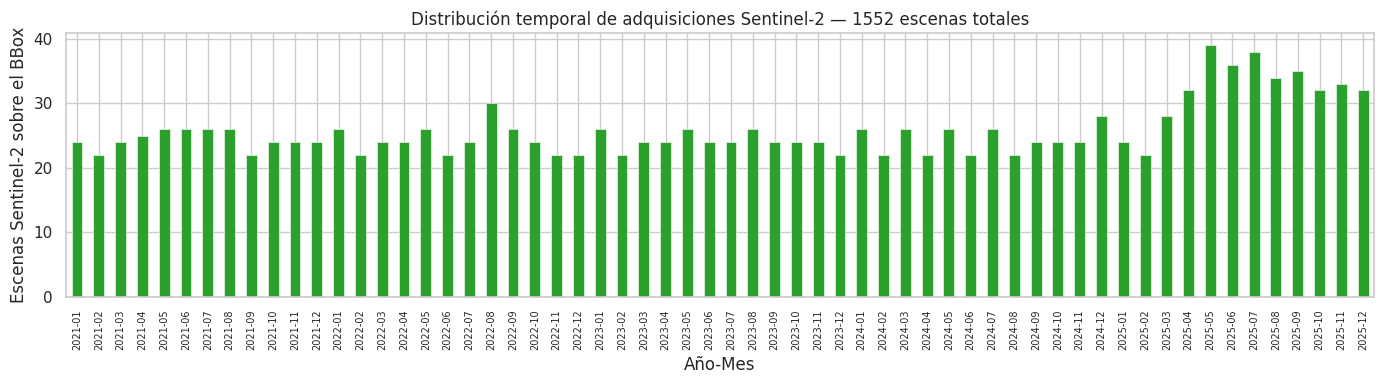


Escenas totales : 1552
Rango           : 2021-01-03 → 2025-12-31
Promedio/mes    : 25.9
Tiles MGRS presentes:
  T18NUJ: 779 escenas
  T18NUK: 773 escenas


In [7]:
times_s2 = parsear_tiempo(s2.time.values)

df_s2 = pd.DataFrame({"time": times_s2})
df_s2["año_mes"] = df_s2["time"].dt.to_period("M").astype(str)
conteo_mensual = df_s2.groupby("año_mes").size().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
conteo_mensual.plot(kind="bar", ax=ax, color="#2ca02c", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Año-Mes")
ax.set_ylabel("Escenas Sentinel-2 sobre el BBox")
ax.set_title(f"Distribución temporal de adquisiciones Sentinel-2 — {len(times_s2)} escenas totales")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
save_fig(fig, "s2_distribucion_temporal")
plt.show()

tile_mgrs = [str(t).split("_")[-1] for t in s2.time.values]
df_s2["tile_mgrs"] = tile_mgrs
conteo_por_tile = df_s2.groupby("tile_mgrs").size().sort_values(ascending=False)

print(f"\nEscenas totales : {len(times_s2)}")
print(f"Rango           : {times_s2.min().date()} → {times_s2.max().date()}")
print(f"Promedio/mes    : {conteo_mensual.mean():.1f}")
print(f"Tiles MGRS presentes:")
for tile, n in conteo_por_tile.items():
    print(f"  {tile}: {n} escenas")

Cobertura SCL en 150 escenas (subsample 1/10):   0%|          | 0/150 [00:00<?, ?it/s]

  [fig] /kaggle/working/figuras_eda/s2_rgb_top12.png


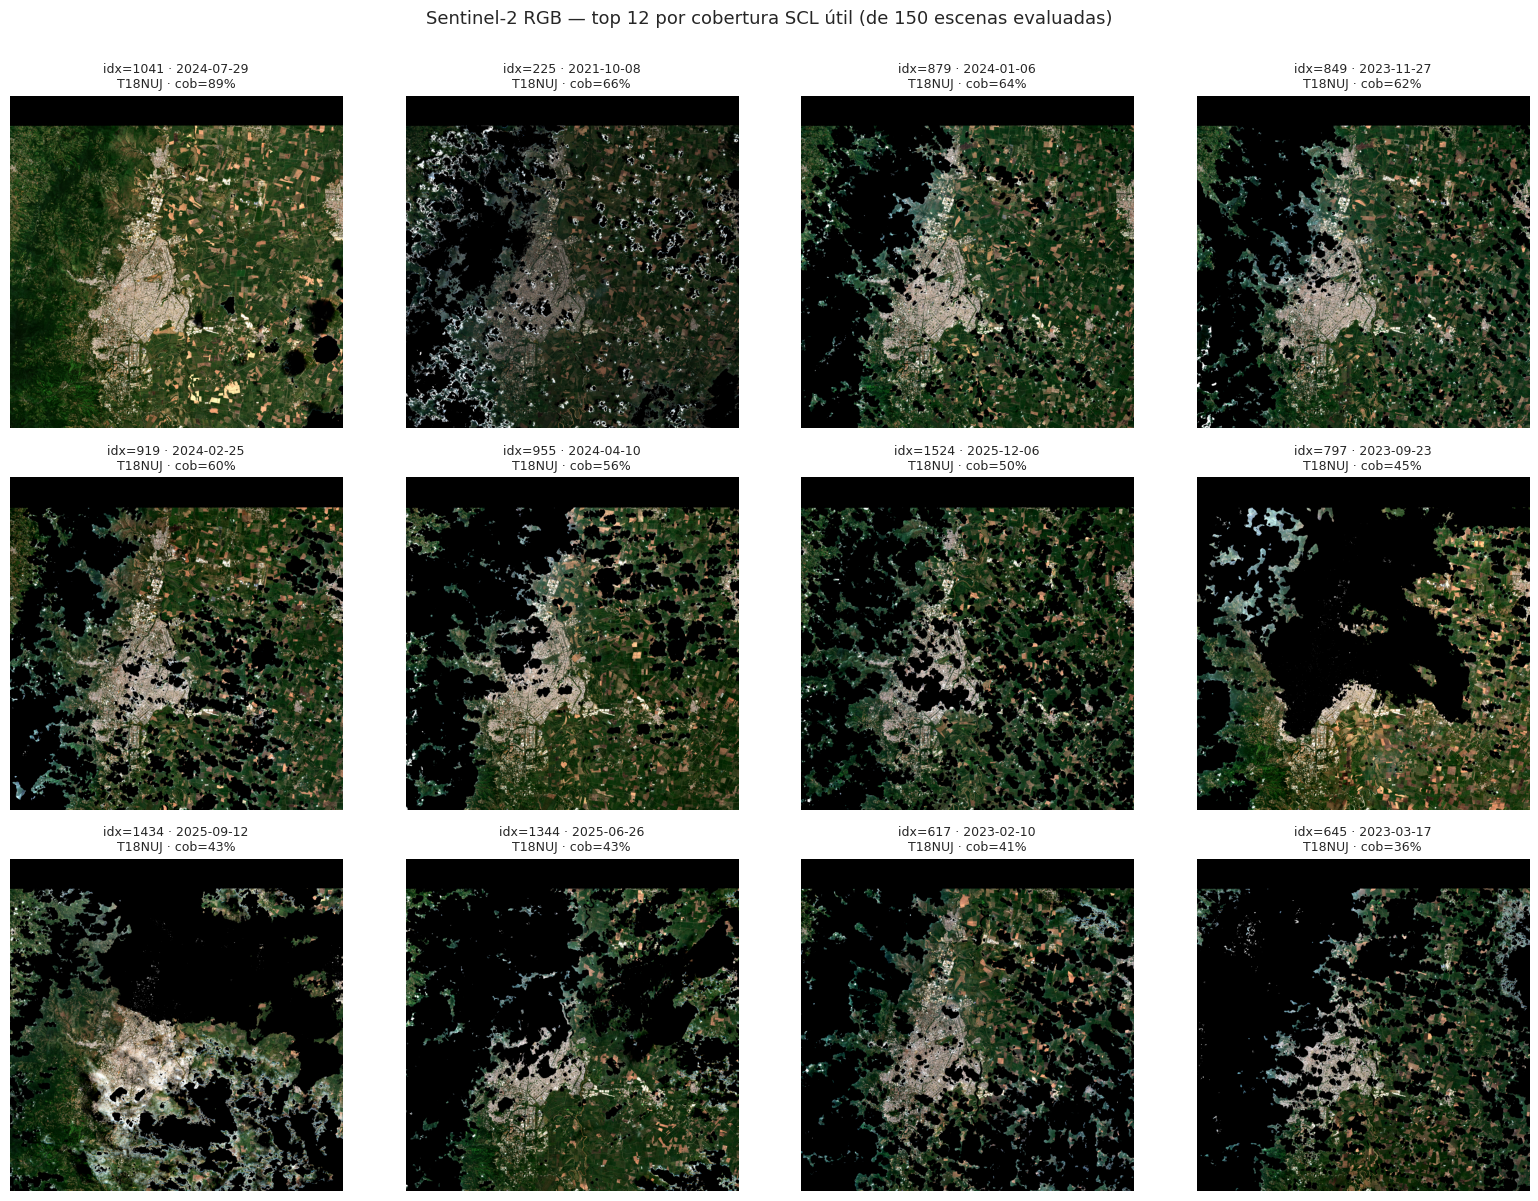

In [8]:
N_EVAL_COBERTURA = 150
K_MEJORES = 12
STEP_SCL = 10

rng_rgb = np.random.default_rng(SEED)
indices_eval = rng_rgb.choice(s2.sizes["time"], size=N_EVAL_COBERTURA, replace=False)

coberturas: list[tuple[int, float]] = []
for idx in tqdm(indices_eval, desc=f"Cobertura SCL en {N_EVAL_COBERTURA} escenas (subsample 1/{STEP_SCL})"):
    idx_int = int(idx)
    scl_sub = s2.isel(time=idx_int).sel(band="SCL")[nombre_var_s2].values[::STEP_SCL, ::STEP_SCL]
    cob = float(np.isin(scl_sub, SCL_VALIDOS).mean())
    coberturas.append((idx_int, cob))

coberturas.sort(key=lambda x: -x[1])
top_k = coberturas[:K_MEJORES]

filas, cols = 3, 4
fig, axes = plt.subplots(filas, cols, figsize=(16, 12))
for ax, (idx, cob) in zip(axes.flat, top_k):
    escena = s2.isel(time=idx)
    b4 = escena.sel(band="B4")[nombre_var_s2].values.astype(np.float32)
    b3 = escena.sel(band="B3")[nombre_var_s2].values.astype(np.float32)
    b2 = escena.sel(band="B2")[nombre_var_s2].values.astype(np.float32)
    scl = escena.sel(band="SCL")[nombre_var_s2].values

    mask = np.isin(scl, SCL_VALIDOS) & (b4 > 0) & (b3 > 0) & (b2 > 0)

    rgb = np.stack([b4, b3, b2], axis=-1)
    if mask.any():
        flat = rgb[mask]
        p2, p98 = np.percentile(flat, [2, 98])
        rgb_norm = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
        rgb_norm[~mask] = 0
    else:
        rgb_norm = np.zeros_like(rgb)

    ax.imshow(rgb_norm)
    fecha = times_s2[idx].strftime("%Y-%m-%d")
    tile = str(s2.time.values[idx]).split("_")[-1]
    ax.set_title(f"idx={idx} · {fecha}\n{tile} · cob={cob:.0%}", fontsize=9)
    ax.axis("off")

plt.suptitle(
    f"Sentinel-2 RGB — top {K_MEJORES} por cobertura SCL útil (de {N_EVAL_COBERTURA} escenas evaluadas)",
    fontsize=13,
    y=1.00,
)
plt.tight_layout()
save_fig(fig, f"s2_rgb_top{K_MEJORES}")
plt.show()

NDVI por escena (con filtro SCL):   0%|          | 0/30 [00:00<?, ?it/s]

  [fig] /kaggle/working/figuras_eda/s2_ndvi_distribucion.png


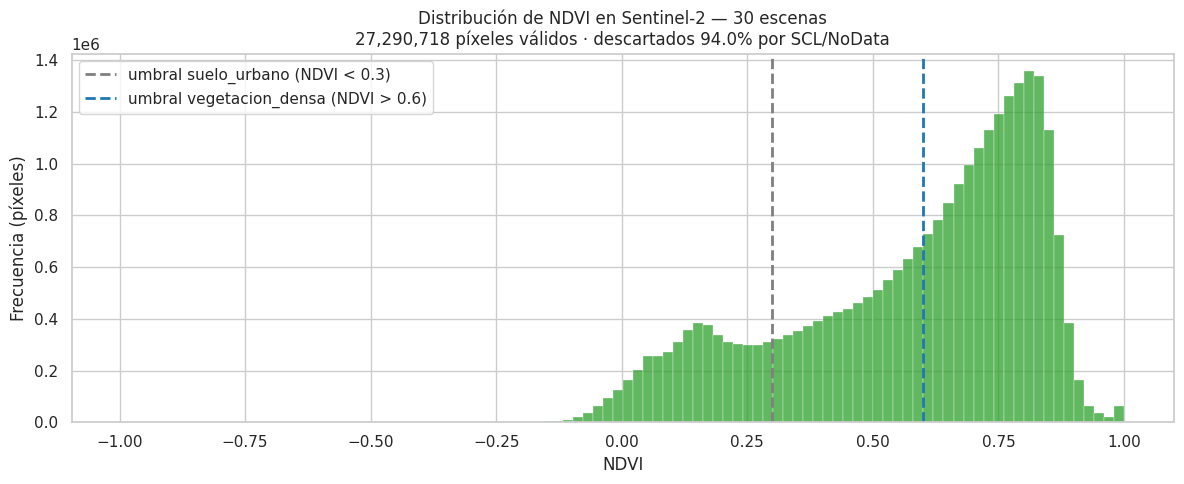


Píxeles totales (30 escenas)     : 455,598,270
Píxeles descartados (SCL/NoData) : 428,307,552 (94.0%)
Píxeles válidos para NDVI        : 27,290,718

% NDVI < 0.3 (suelo_urbano)      : 17.60%
% NDVI > 0.6 (vegetacion_densa)  : 56.90%
% NDVI ∈ [0.3, 0.6]              : 25.50%


In [9]:
n_muestra = 30
rng_ndvi = np.random.default_rng(SEED)
indices_ndvi = rng_ndvi.choice(s2.sizes["time"], size=n_muestra, replace=False)

ndvi_chunks: list[np.ndarray] = []
pixeles_descartados = 0
pixeles_totales = 0
for idx in tqdm(indices_ndvi, desc="NDVI por escena (con filtro SCL)"):
    escena_i = s2.isel(time=int(idx))
    b4_i = escena_i.sel(band="B4")[nombre_var_s2].values.astype(np.float32)
    b8_i = escena_i.sel(band="B8")[nombre_var_s2].values.astype(np.float32)
    scl_i = escena_i.sel(band="SCL")[nombre_var_s2].values

    mask = np.isin(scl_i, SCL_VALIDOS) & (b4_i > 0) & (b8_i > 0)
    pixeles_totales += b4_i.size
    pixeles_descartados += int((~mask).sum())

    ndvi_i = (b8_i - b4_i) / (b8_i + b4_i + 1e-6)
    ndvi_chunks.append(ndvi_i[mask])

ndvi_all = np.concatenate(ndvi_chunks)
ndvi_validos = ndvi_all[(ndvi_all > -1) & (ndvi_all < 1)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(ndvi_validos, bins=100, color="#2ca02c", alpha=0.75, edgecolor="white", linewidth=0.3)
ax.axvline(0.3, color="#7f7f7f", linestyle="--", linewidth=2,
           label="umbral suelo_urbano (NDVI < 0.3)")
ax.axvline(0.6, color="#1f77b4", linestyle="--", linewidth=2,
           label="umbral vegetacion_densa (NDVI > 0.6)")
ax.set_xlabel("NDVI")
ax.set_ylabel("Frecuencia (píxeles)")
ax.set_title(
    f"Distribución de NDVI en Sentinel-2 — {n_muestra} escenas\n"
    f"{len(ndvi_validos):,} píxeles válidos · descartados {pixeles_descartados/pixeles_totales:.1%} por SCL/NoData"
)
ax.legend()
plt.tight_layout()
save_fig(fig, "s2_ndvi_distribucion")
plt.show()

pct_urbano = float((ndvi_validos < 0.3).mean() * 100)
pct_vegetacion = float((ndvi_validos > 0.6).mean() * 100)
pct_intermedio = 100 - pct_urbano - pct_vegetacion
print(f"\nPíxeles totales (30 escenas)     : {pixeles_totales:,}")
print(f"Píxeles descartados (SCL/NoData) : {pixeles_descartados:,} ({pixeles_descartados/pixeles_totales:.1%})")
print(f"Píxeles válidos para NDVI        : {len(ndvi_validos):,}")
print(f"\n% NDVI < 0.3 (suelo_urbano)      : {pct_urbano:.2f}%")
print(f"% NDVI > 0.6 (vegetacion_densa)  : {pct_vegetacion:.2f}%")
print(f"% NDVI ∈ [0.3, 0.6]              : {pct_intermedio:.2f}%")

In [10]:
scl_cache = pd.read_csv(TILES_SIT2 / "scl_por_escena.csv")
print(f"Filas en cache: {len(scl_cache)}")
print(f"Columnas      : {list(scl_cache.columns)}")
print(scl_cache.head())
print(f"\nDistribución del % SCL útil por escena:")
print(scl_cache["scl_pct"].describe())

Filas en cache: 1552
Columnas      : ['time_idx', 'time_s2', 'scl_pct']
   time_idx                                 time_s2   scl_pct
0         0  20210103T152641_20210103T153117_T18NUJ  0.000000
1         1  20210103T152641_20210103T153117_T18NUK  0.000000
2         2  20210106T153621_20210106T154053_T18NUJ  0.102335
3         3  20210106T153621_20210106T154053_T18NUK  0.065783
4         4  20210108T152639_20210108T153127_T18NUJ  0.007976

Distribución del % SCL útil por escena:
count    1552.000000
mean        0.091124
std         0.154325
min         0.000000
25%         0.000040
50%         0.017942
75%         0.118164
max         0.890044
Name: scl_pct, dtype: float64


In [11]:
UMBRAL_SCL_MUESTREO = 0.30

scl_cache["time_s2_str"] = scl_cache["time_s2"].astype(str)
scl_cache["fecha"] = pd.to_datetime(
    scl_cache["time_s2_str"].str.split("_").str[0],
    format="%Y%m%dT%H%M%S"
)
scl_cache["tile_mgrs"] = scl_cache["time_s2_str"].str.split("_").str[-1]
scl_cache["año"] = scl_cache["fecha"].dt.year
scl_cache["año_mes"] = scl_cache["fecha"].dt.to_period("M").astype(str)
scl_cache["pasa_filtro"] = scl_cache["scl_pct"] >= UMBRAL_SCL_MUESTREO

n_total = len(scl_cache)
n_pasan = int(scl_cache["pasa_filtro"].sum())

print(f"Escenas totales en cache       : {n_total}")
print(f"Escenas con SCL ≥ {UMBRAL_SCL_MUESTREO:.0%}  : {n_pasan} ({n_pasan/n_total:.1%})")
print(f"\nUmbrales alternativos:")
for u in (0.10, 0.20, 0.30, 0.50, 0.70):
    n = int((scl_cache["scl_pct"] >= u).sum())
    print(f"  SCL ≥ {u:.0%}: {n:>4} escenas  ({n/n_total:.1%})")

Escenas totales en cache       : 1552
Escenas con SCL ≥ 30%  : 136 (8.8%)

Umbrales alternativos:
  SCL ≥ 10%:  438 escenas  (28.2%)
  SCL ≥ 20%:  221 escenas  (14.2%)
  SCL ≥ 30%:  136 escenas  (8.8%)
  SCL ≥ 50%:   66 escenas  (4.3%)
  SCL ≥ 70%:   17 escenas  (1.1%)


  [fig] /kaggle/working/figuras_eda/s2_scl_distribucion_mensual.png


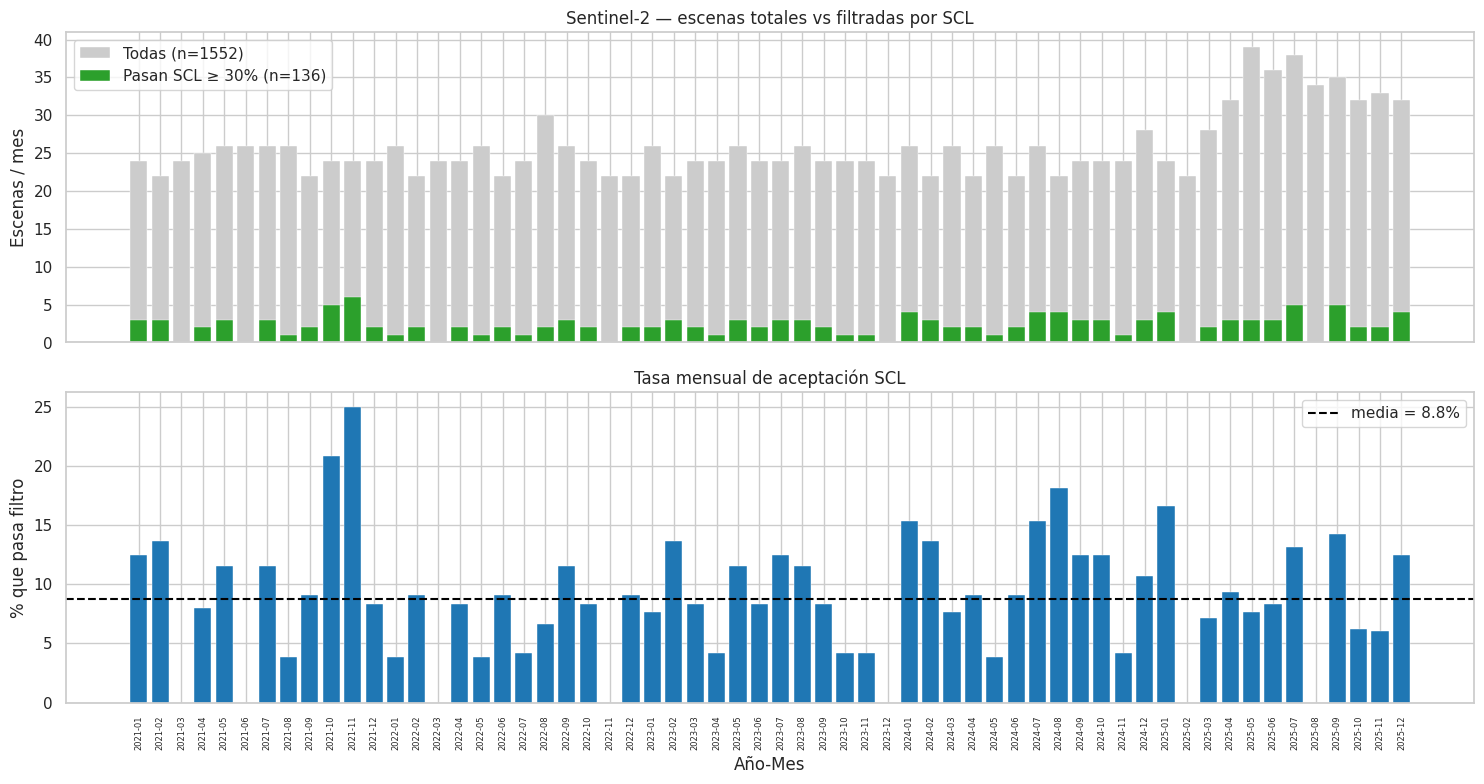

In [12]:
filtradas = scl_cache[scl_cache["pasa_filtro"]]
todas_por_mes = scl_cache.groupby("año_mes").size().sort_index()
filtradas_por_mes = filtradas.groupby("año_mes").size().reindex(todas_por_mes.index, fill_value=0)
tasa_aceptacion = (filtradas_por_mes / todas_por_mes * 100).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].bar(todas_por_mes.index, todas_por_mes.values, color="#cccccc",
            edgecolor="white", linewidth=0.3, label=f"Todas (n={n_total})")
axes[0].bar(filtradas_por_mes.index, filtradas_por_mes.values, color="#2ca02c",
            edgecolor="white", linewidth=0.3, label=f"Pasan SCL ≥ {UMBRAL_SCL_MUESTREO:.0%} (n={n_pasan})")
axes[0].set_ylabel("Escenas / mes")
axes[0].set_title("Sentinel-2 — escenas totales vs filtradas por SCL")
axes[0].legend()

axes[1].bar(tasa_aceptacion.index, tasa_aceptacion.values,
            color="#1f77b4", edgecolor="white", linewidth=0.3)
axes[1].axhline(tasa_aceptacion.mean(), color="black", linestyle="--", linewidth=1.5,
                label=f"media = {tasa_aceptacion.mean():.1f}%")
axes[1].set_ylabel("% que pasa filtro")
axes[1].set_xlabel("Año-Mes")
axes[1].set_title("Tasa mensual de aceptación SCL")
axes[1].tick_params(axis="x", rotation=90, labelsize=6)
axes[1].legend()

plt.tight_layout()
save_fig(fig, "s2_scl_distribucion_mensual")
plt.show()

  [fig] /kaggle/working/figuras_eda/s2_scl_distribucion_estacional.png


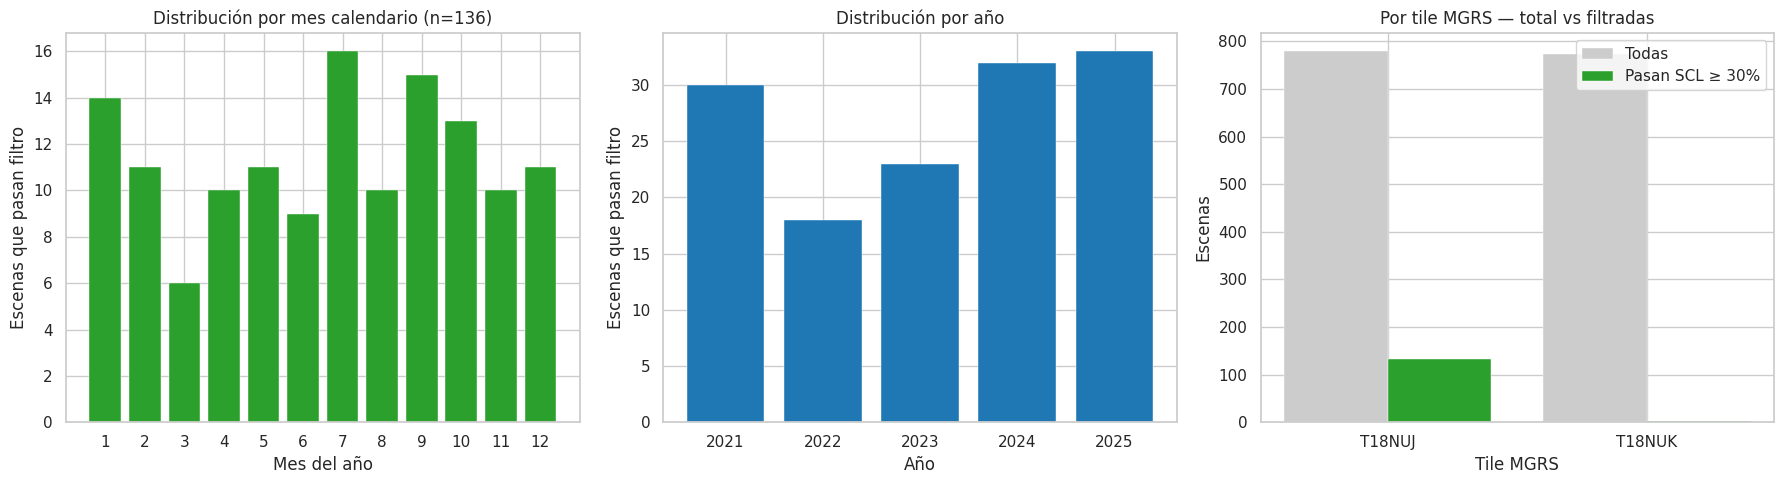


=== Por mes calendario (las 140 escenas filtradas) ===
  Mes  1:   14 escenas
  Mes  2:   11 escenas
  Mes  3:    6 escenas
  Mes  4:   10 escenas
  Mes  5:   11 escenas
  Mes  6:    9 escenas
  Mes  7:   16 escenas
  Mes  8:   10 escenas
  Mes  9:   15 escenas
  Mes 10:   13 escenas
  Mes 11:   10 escenas
  Mes 12:   11 escenas

=== Por año ===
  2021:   30 escenas
  2022:   18 escenas
  2023:   23 escenas
  2024:   32 escenas
  2025:   33 escenas

=== Por tile MGRS ===
  T18NUJ: 133 / 779 = 17.1%
  T18NUK:   3 / 773 = 0.4%


In [13]:
filtradas_por_mes_calendar = filtradas["fecha"].dt.month.value_counts().sort_index()
filtradas_por_año = filtradas["año"].value_counts().sort_index()
filtradas_por_tile = filtradas["tile_mgrs"].value_counts()
todas_por_tile = scl_cache["tile_mgrs"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(filtradas_por_mes_calendar.index, filtradas_por_mes_calendar.values,
            color="#2ca02c", edgecolor="white", linewidth=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("Mes del año")
axes[0].set_ylabel("Escenas que pasan filtro")
axes[0].set_title(f"Distribución por mes calendario (n={n_pasan})")

axes[1].bar(filtradas_por_año.index.astype(str), filtradas_por_año.values,
            color="#1f77b4", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Escenas que pasan filtro")
axes[1].set_title("Distribución por año")

x = np.arange(len(todas_por_tile))
ancho = 0.4
axes[2].bar(x - ancho/2, todas_por_tile.values, ancho, color="#cccccc",
            edgecolor="white", linewidth=0.3, label="Todas")
axes[2].bar(x + ancho/2,
            [filtradas_por_tile.get(t, 0) for t in todas_por_tile.index],
            ancho, color="#2ca02c", edgecolor="white", linewidth=0.3,
            label=f"Pasan SCL ≥ {UMBRAL_SCL_MUESTREO:.0%}")
axes[2].set_xticks(x)
axes[2].set_xticklabels(todas_por_tile.index)
axes[2].set_xlabel("Tile MGRS")
axes[2].set_ylabel("Escenas")
axes[2].set_title("Por tile MGRS — total vs filtradas")
axes[2].legend()

plt.tight_layout()
save_fig(fig, "s2_scl_distribucion_estacional")
plt.show()

print("\n=== Por mes calendario (las 140 escenas filtradas) ===")
for m, n in filtradas_por_mes_calendar.items():
    print(f"  Mes {m:>2}: {n:>4} escenas")

print("\n=== Por año ===")
for y, n in filtradas_por_año.items():
    print(f"  {y}: {n:>4} escenas")

print(f"\n=== Por tile MGRS ===")
for t in todas_por_tile.index:
    n_total_tile = int(todas_por_tile[t])
    n_pasa_tile = int(filtradas_por_tile.get(t, 0))
    print(f"  {t}: {n_pasa_tile:>3} / {n_total_tile} = {n_pasa_tile/n_total_tile:.1%}")

In [14]:
dagma_dir = PANEL_BASE / "dagma"
print(f"Contenido de {dagma_dir.name}/:")
for p in sorted(dagma_dir.iterdir()):
    print(f"  {p.name} ({p.stat().st_size / 1024:.1f} KB)")

csv_estaciones = next((p for p in dagma_dir.iterdir() if p.suffix == ".csv"), None)
if csv_estaciones is None:
    raise FileNotFoundError(f"No se encontró CSV de estaciones en {dagma_dir}")
print(f"\nUsando: {csv_estaciones.name}")

dagma_est = pd.read_csv(csv_estaciones)
print(f"Columnas: {dagma_est.columns.tolist()}")
print(dagma_est.head())

Contenido de dagma/:
  dagma_cvc_horario_raw.parquet (854.8 KB)
  estaciones_metadata.csv (0.9 KB)
  manifest_ground_truth.json (0.6 KB)

Usando: estaciones_metadata.csv
Columnas: ['estacion_id', 'nombre_est', 'nombre_fgda', 'municipio', 'departamento', 'latitud', 'longitud', 'altitud']
   estacion_id      nombre_est nombre_fgda         municipio     departamento  \
0         8285      BASE AÉREA       DAGMA  Santiago de Cali  Valle del Cauca   
1        30109    CAÑAVERALEJO       DAGMA  Santiago de Cali  Valle del Cauca   
2        30110       COMPARTIR       DAGMA  Santiago de Cali  Valle del Cauca   
3        30004      ERA OBRERO       DAGMA  Santiago de Cali  Valle del Cauca   
4         8777  ESTACIÓN YUMBO         CVC             Yumbo  Valle del Cauca   

    latitud   longitud  altitud  
0  3.457128 -76.502303      956  
1  3.416366 -76.549613      975  
2  3.428260 -76.466584      952  
3  3.457317 -76.506539      968  
4  3.579075 -76.489558      950  


In [15]:
LAT_LIMITE_J_K = 3.6

posibles_lat = ["latitud", "lat", "latitude", "y"]
posibles_lon = ["longitud", "lon", "lng", "longitude", "x"]
col_lat = next((c for c in posibles_lat if c in dagma_est.columns), None)
col_lon = next((c for c in posibles_lon if c in dagma_est.columns), None)
if col_lat is None or col_lon is None:
    raise ValueError(f"No se identificó columna lat/lon en {dagma_est.columns.tolist()}")

dagma_est["tile_mgrs_aprox"] = np.where(
    dagma_est[col_lat] >= LAT_LIMITE_J_K, "T18NUK", "T18NUJ"
)
dagma_est["en_bbox_proyecto"] = (
    (dagma_est[col_lat] >= BBOX_CALI["lat_min"]) &
    (dagma_est[col_lat] <= BBOX_CALI["lat_max"]) &
    (dagma_est[col_lon] >= BBOX_CALI["lon_min"]) &
    (dagma_est[col_lon] <= BBOX_CALI["lon_max"])
)
dagma_est["en_bbox_pdf"] = (
    (dagma_est[col_lat] >= BBOX_PDF["lat_min"]) &
    (dagma_est[col_lat] <= BBOX_PDF["lat_max"]) &
    (dagma_est[col_lon] >= BBOX_PDF["lon_min"]) &
    (dagma_est[col_lon] <= BBOX_PDF["lon_max"])
)

cols_resumen = [c for c in dagma_est.columns if c not in (col_lat, col_lon, "tile_mgrs_aprox", "en_bbox_proyecto", "en_bbox_pdf")]
print("\n=== Estaciones DAGMA — tile MGRS y cobertura por BBox ===")
print(dagma_est[[col_lat, col_lon, "tile_mgrs_aprox", "en_bbox_proyecto", "en_bbox_pdf"] + cols_resumen].to_string(index=False))

en_j = int((dagma_est["tile_mgrs_aprox"] == "T18NUJ").sum())
en_k = int((dagma_est["tile_mgrs_aprox"] == "T18NUK").sum())
n_proyecto = int(dagma_est["en_bbox_proyecto"].sum())
n_pdf = int(dagma_est["en_bbox_pdf"].sum())

print(f"\nEstaciones en T18NUJ           : {en_j}/{len(dagma_est)}")
print(f"Estaciones en T18NUK           : {en_k}/{len(dagma_est)}")
print(f"Dentro BBox proyecto (ampliado): {n_proyecto}/{len(dagma_est)}")
print(f"Dentro BBox PDF (estricto)     : {n_pdf}/{len(dagma_est)}")

estaciones_fuera_pdf = dagma_est[~dagma_est["en_bbox_pdf"]]
if len(estaciones_fuera_pdf):
    print(f"\nEstaciones fuera del BBox PDF:")
    print(estaciones_fuera_pdf[[col_lat, col_lon] + cols_resumen].to_string(index=False))


=== Estaciones DAGMA — tile MGRS y cobertura por BBox ===
 latitud   longitud tile_mgrs_aprox  en_bbox_proyecto  en_bbox_pdf  estacion_id            nombre_est nombre_fgda        municipio    departamento  altitud
3.457128 -76.502303          T18NUJ              True         True         8285            BASE AÉREA       DAGMA Santiago de Cali Valle del Cauca      956
3.416366 -76.549613          T18NUJ              True         True        30109          CAÑAVERALEJO       DAGMA Santiago de Cali Valle del Cauca      975
3.428260 -76.466584          T18NUJ              True         True        30110             COMPARTIR       DAGMA Santiago de Cali Valle del Cauca      952
3.457317 -76.506539          T18NUJ              True         True        30004            ERA OBRERO       DAGMA Santiago de Cali Valle del Cauca      968
3.579075 -76.489558          T18NUJ              True        False         8777        ESTACIÓN YUMBO         CVC            Yumbo Valle del Cauca      950
3.455

  [fig] /kaggle/working/figuras_eda/dagma_estaciones_vs_tile_mgrs.png


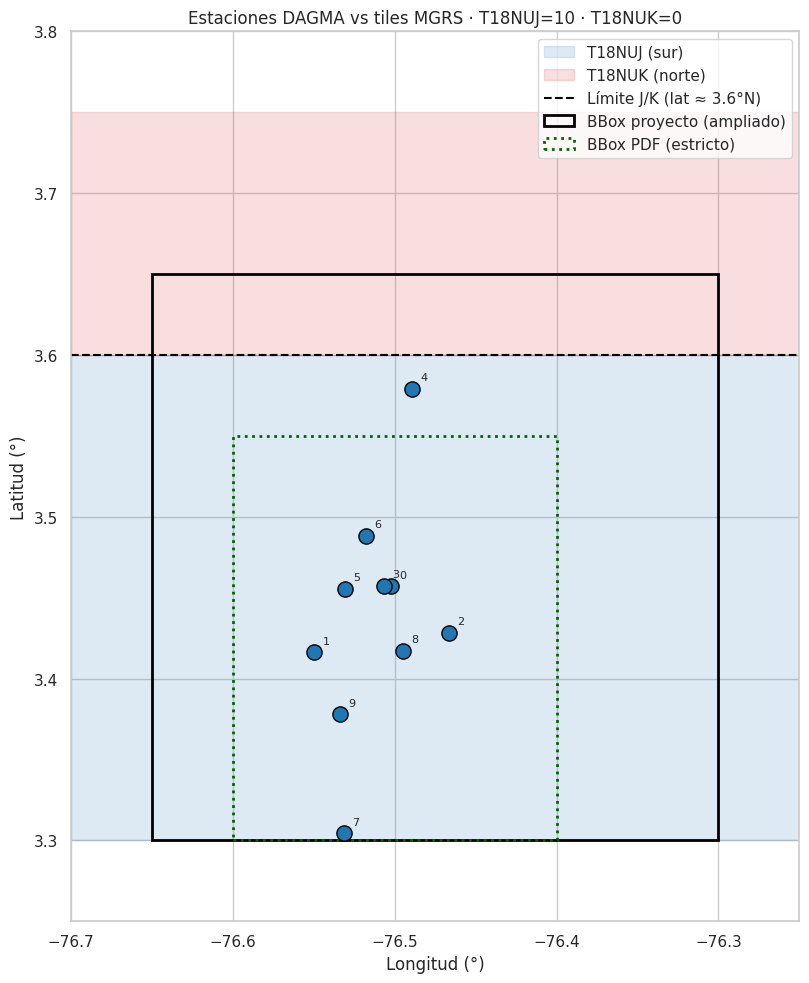

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.axhspan(BBOX_CALI["lat_min"], LAT_LIMITE_J_K,
           xmin=0, xmax=1, alpha=0.15, color="#1f77b4", label="T18NUJ (sur)")
ax.axhspan(LAT_LIMITE_J_K, BBOX_CALI["lat_max"] + 0.1,
           xmin=0, xmax=1, alpha=0.15, color="#d62728", label="T18NUK (norte)")

ax.axhline(LAT_LIMITE_J_K, color="black", linestyle="--", linewidth=1.5,
           label=f"Límite J/K (lat ≈ {LAT_LIMITE_J_K}°N)")

ax.add_patch(Rectangle(
    (BBOX_CALI["lon_min"], BBOX_CALI["lat_min"]),
    BBOX_CALI["lon_max"] - BBOX_CALI["lon_min"],
    BBOX_CALI["lat_max"] - BBOX_CALI["lat_min"],
    fill=False, edgecolor="black", linewidth=2, label="BBox proyecto (ampliado)"
))
ax.add_patch(Rectangle(
    (BBOX_PDF["lon_min"], BBOX_PDF["lat_min"]),
    BBOX_PDF["lon_max"] - BBOX_PDF["lon_min"],
    BBOX_PDF["lat_max"] - BBOX_PDF["lat_min"],
    fill=False, edgecolor="darkgreen", linewidth=2, linestyle=":", label="BBox PDF (estricto)"
))

for _, row in dagma_est.iterrows():
    color = "#d62728" if row["tile_mgrs_aprox"] == "T18NUK" else "#1f77b4"
    ax.scatter(row[col_lon], row[col_lat], s=120, color=color,
               edgecolor="black", linewidth=1, zorder=5)
    nombre = row.get("nombre_est", row.get("nombre_fgda", str(row.name)))
    ax.annotate(str(nombre), (row[col_lon], row[col_lat]),
                xytext=(6, 6), textcoords="offset points", fontsize=8)

ax.set_xlim(BBOX_CALI["lon_min"] - 0.05, BBOX_CALI["lon_max"] + 0.05)
ax.set_ylim(BBOX_CALI["lat_min"] - 0.05, BBOX_CALI["lat_max"] + 0.15)
ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(f"Estaciones DAGMA vs tiles MGRS · T18NUJ={en_j} · T18NUK={en_k}")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.tight_layout()
save_fig(fig, "dagma_estaciones_vs_tile_mgrs")
plt.show()

In [17]:
s5p_no2 = cargar_zarr("S5P_NO2")
s5p_so2 = cargar_zarr("S5P_SO2")
s5p_o3  = cargar_zarr("S5P_O3")

S5P_BANDAS = {
    "NO2": "tropospheric_NO2_column_number_density",
    "SO2": "SO2_column_number_density",
    "O3":  "O3_column_number_density",
}

S5P_DATASETS = [
    (s5p_no2, "NO2", "NO₂", S5P_BANDAS["NO2"]),
    (s5p_so2, "SO2", "SO₂", S5P_BANDAS["SO2"]),
    (s5p_o3,  "O3",  "O₃",  S5P_BANDAS["O3"]),
]

for ds, key, label, banda in S5P_DATASETS:
    inspeccionar_dataset(ds, f"Sentinel-5P {label}")
    print(f"  Banda usada: {banda}")
    print()

=== Sentinel-5P NO₂ ===
  Dimensiones : {'time': 25592, 'band': 3, 'y': 36, 'x': 36}
  Variables   : ['data']
  Bandas (3): [np.str_('tropospheric_NO2_column_number_density'), np.str_('NO2_column_number_density'), np.str_('cloud_fraction')]
  Tiempo      : 25592 timestamps · dtype=<U31
  Muestra     : ['20201231T234906_20210102T163556' '20210101T013036_20210102T182734']
  Espacial    : y=36 px · x=36 px · res≈0.01000° (~1.11 km)
  Banda usada: tropospheric_NO2_column_number_density

=== Sentinel-5P SO₂ ===
  Dimensiones : {'time': 25829, 'band': 2, 'y': 36, 'x': 36}
  Variables   : ['data']
  Bandas (2): [np.str_('SO2_column_number_density'), np.str_('cloud_fraction')]
  Tiempo      : 25829 timestamps · dtype=<U31
  Muestra     : ['20201231T234906_20210103T005305' '20210101T013036_20210103T035447']
  Espacial    : y=36 px · x=36 px · res≈0.01000° (~1.11 km)
  Banda usada: SO2_column_number_density

=== Sentinel-5P O₃ ===
  Dimensiones : {'time': 25716, 'band': 2, 'y': 36, 'x': 36}
  Va

  [fig] /kaggle/working/figuras_eda/s5p_distribucion_temporal.png


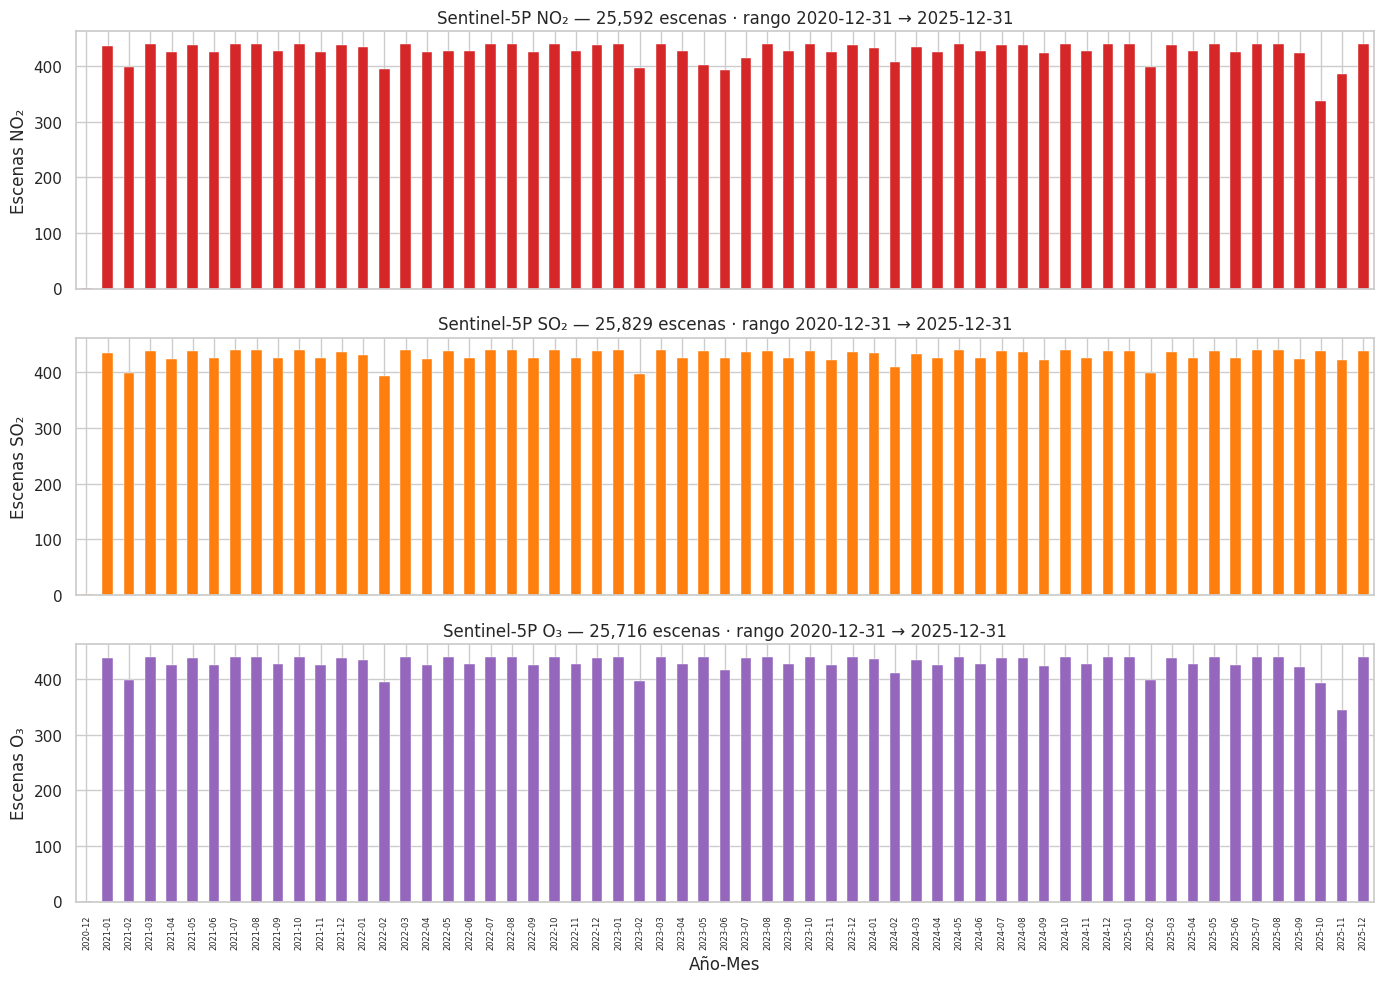


=== Resumen S5P por contaminante ===
NO₂  : 25,592 escenas · 2020-12-31 → 2025-12-31
SO₂  : 25,829 escenas · 2020-12-31 → 2025-12-31
O₃   : 25,716 escenas · 2020-12-31 → 2025-12-31


In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (ds, key, label, banda) in zip(axes, S5P_DATASETS):
    times = parsear_tiempo(ds.time.values)
    df = pd.DataFrame({"time": times})
    df["año_mes"] = df["time"].dt.to_period("M").astype(str)
    conteo = df.groupby("año_mes").size().sort_index()

    color = PALETA_CONTAMINANTES[key]
    conteo.plot(kind="bar", ax=ax, color=color, edgecolor="white", linewidth=0.3)
    ax.set_ylabel(f"Escenas {label}")
    ax.set_title(f"Sentinel-5P {label} — {len(times):,} escenas · rango {times.min().date()} → {times.max().date()}")
    ax.tick_params(axis="x", rotation=90, labelsize=6)

axes[-1].set_xlabel("Año-Mes")
plt.tight_layout()
save_fig(fig, "s5p_distribucion_temporal")
plt.show()

print("\n=== Resumen S5P por contaminante ===")
for ds, key, label, _ in S5P_DATASETS:
    times = parsear_tiempo(ds.time.values)
    print(f"{label:5s}: {len(times):>6,} escenas · {times.min().date()} → {times.max().date()}")

Cargando NO₂:   0%|          | 0/80 [00:00<?, ?it/s]

Cargando SO₂:   0%|          | 0/80 [00:00<?, ?it/s]

Cargando O₃:   0%|          | 0/80 [00:00<?, ?it/s]

  [fig] /kaggle/working/figuras_eda/s5p_distribuciones_percentiles.png


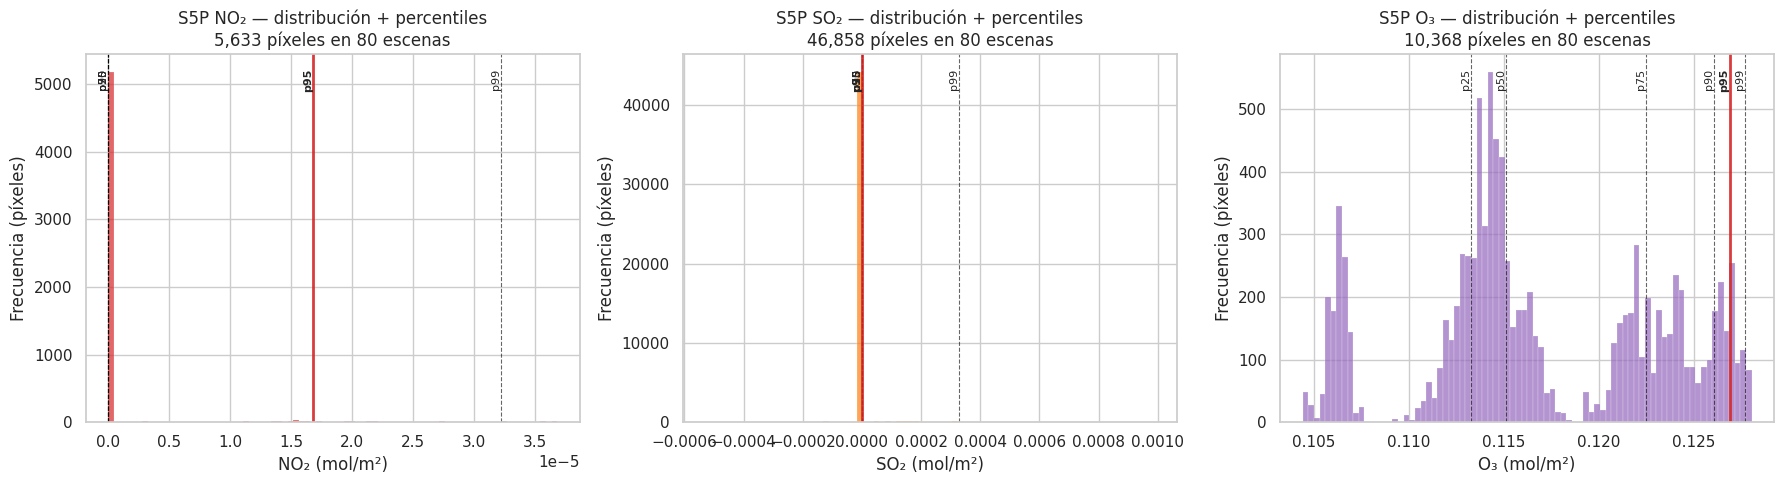


=== Percentiles observados (mol/m²) ===

NO2:
  p25: 0.000e+00
  p50: 0.000e+00
  p75: 0.000e+00
  p90: 0.000e+00 ← umbral usado
  p95: 1.680e-05
  p99: 3.224e-05

SO2:
  p25: 0.000e+00
  p50: 0.000e+00
  p75: 0.000e+00
  p90: 0.000e+00 ← umbral usado
  p95: 0.000e+00
  p99: 3.266e-04

O3:
  p25: 1.133e-01
  p50: 1.151e-01
  p75: 1.225e-01
  p90: 1.261e-01
  p95: 1.269e-01 ← umbral usado
  p99: 1.277e-01


In [19]:
N_MUESTRA_S5P = 80
percentiles_observados: dict[str, dict[int, float]] = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (ds, key, label, banda) in zip(axes, S5P_DATASETS):
    var = list(ds.data_vars)[0]
    rng_s5p = np.random.default_rng(SEED)
    indices = rng_s5p.choice(ds.sizes["time"], size=min(N_MUESTRA_S5P, ds.sizes["time"]), replace=False)

    chunks = []
    for idx in tqdm(indices, desc=f"Cargando {label}"):
        v = ds.isel(time=int(idx)).sel(band=banda)[var].values.astype(np.float32)
        v = v[np.isfinite(v)]
        chunks.append(v)
    valores = np.concatenate(chunks)

    percs = np.percentile(valores, PERCENTILES)
    percentiles_observados[key] = dict(zip(PERCENTILES, [float(p) for p in percs]))

    color = PALETA_CONTAMINANTES[key]
    ax.hist(valores, bins=80, color=color, alpha=0.7, edgecolor="white", linewidth=0.2)

    y_max = ax.get_ylim()[1]
    for p, v in zip(PERCENTILES, percs):
        es_p95 = (p == 95)
        ax.axvline(float(v),
                   color="black" if not es_p95 else "#d62728",
                   linestyle="-" if es_p95 else "--",
                   linewidth=2.0 if es_p95 else 0.8,
                   alpha=0.9 if es_p95 else 0.6)
        ax.text(float(v), y_max * 0.96, f"p{p}", rotation=90, va="top", ha="right",
                fontsize=8, fontweight="bold" if es_p95 else "normal")

    ax.set_xlabel(f"{label} (mol/m²)")
    ax.set_ylabel("Frecuencia (píxeles)")
    ax.set_title(f"S5P {label} — distribución + percentiles\n{len(valores):,} píxeles en {len(indices)} escenas")

plt.tight_layout()
save_fig(fig, "s5p_distribuciones_percentiles")
plt.show()

print("\n=== Percentiles observados (mol/m²) ===")
for key, percs in percentiles_observados.items():
    print(f"\n{key}:")
    for p, v in percs.items():
        marca = " ← umbral usado" if (key == "O3" and p == 95) or (key in {"NO2", "SO2"} and p == 90) else ""
        print(f"  p{p:2d}: {v:.3e}{marca}")

Promedio espacial NO₂:   0%|          | 0/200 [00:00<?, ?it/s]

Promedio espacial SO₂:   0%|          | 0/200 [00:00<?, ?it/s]

Promedio espacial O₃:   0%|          | 0/200 [00:00<?, ?it/s]

  [fig] /kaggle/working/figuras_eda/s5p_mapas_promedio.png


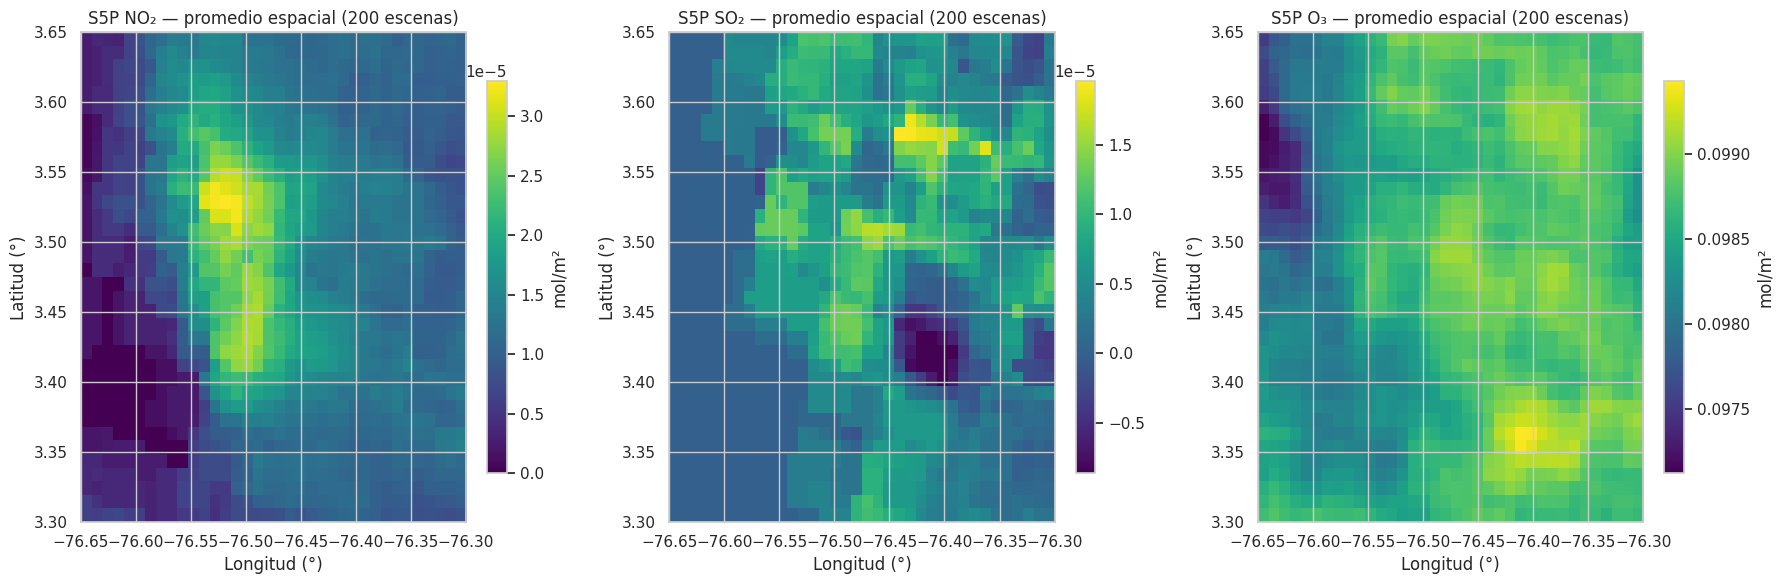

In [21]:
N_PROMEDIO_S5P = 200
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (ds, key, label, banda) in zip(axes, S5P_DATASETS):
    var = list(ds.data_vars)[0]
    rng_map = np.random.default_rng(SEED)
    indices = rng_map.choice(ds.sizes["time"], size=min(N_PROMEDIO_S5P, ds.sizes["time"]), replace=False)

    apilado = []
    for idx in tqdm(indices, desc=f"Promedio espacial {label}"):
        v = ds.isel(time=int(idx)).sel(band=banda)[var].values.astype(np.float32)
        apilado.append(v)
    stack = np.stack(apilado)
    promedio = np.nanmean(stack, axis=0)

    extent = [BBOX_CALI["lon_min"], BBOX_CALI["lon_max"],
              BBOX_CALI["lat_min"], BBOX_CALI["lat_max"]]
    im = ax.imshow(promedio, cmap="viridis", aspect="auto", extent=extent, origin="lower")
    ax.set_xlabel("Longitud (°)")
    ax.set_ylabel("Latitud (°)")
    ax.set_title(f"S5P {label} — promedio espacial ({len(indices)} escenas)")
    plt.colorbar(im, ax=ax, fraction=0.046, label="mol/m²")

plt.tight_layout()
save_fig(fig, "s5p_mapas_promedio")
plt.show()

Cobertura NO₂:   0%|          | 0/200 [00:00<?, ?it/s]

Cobertura SO₂:   0%|          | 0/200 [00:00<?, ?it/s]

Cobertura O₃:   0%|          | 0/200 [00:00<?, ?it/s]

  [fig] /kaggle/working/figuras_eda/s5p_cobertura_efectiva.png


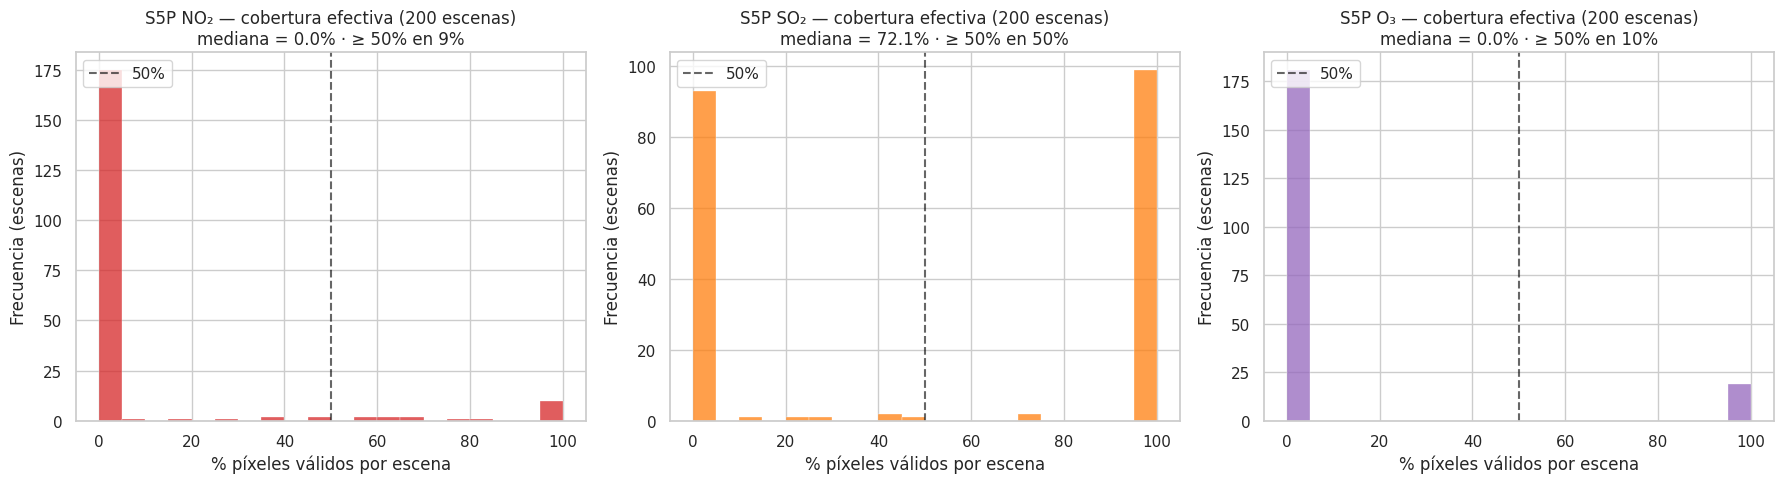

In [22]:
N_COBERTURA_S5P = 200
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (ds, key, label, banda) in zip(axes, S5P_DATASETS):
    var = list(ds.data_vars)[0]
    rng_cob = np.random.default_rng(SEED)
    indices = rng_cob.choice(ds.sizes["time"], size=min(N_COBERTURA_S5P, ds.sizes["time"]), replace=False)

    pct_validos = []
    for idx in tqdm(indices, desc=f"Cobertura {label}"):
        v = ds.isel(time=int(idx)).sel(band=banda)[var].values
        pct_validos.append(float(np.isfinite(v).mean() * 100))

    color = PALETA_CONTAMINANTES[key]
    ax.hist(pct_validos, bins=20, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(50, color="black", linestyle="--", linewidth=1.5, alpha=0.6, label="50%")
    ax.set_xlabel(f"% píxeles válidos por escena")
    ax.set_ylabel("Frecuencia (escenas)")
    ax.set_title(
        f"S5P {label} — cobertura efectiva ({len(indices)} escenas)\n"
        f"mediana = {np.median(pct_validos):.1f}% · ≥ 50% en {(np.array(pct_validos) >= 50).mean():.0%}"
    )
    ax.legend(loc="upper left")

plt.tight_layout()
save_fig(fig, "s5p_cobertura_efectiva")
plt.show()

In [23]:
era5 = cargar_zarr("ERA5")
inspeccionar_dataset(era5, "ERA5 Hourly")

if "band" in era5.coords:
    nombre_var_era5 = list(era5.data_vars)[0]
    USA_BANDAS_ERA5 = True
    print(f"\nEstructura coord-band con {len(era5.band)} bandas:")
    for b in era5.band.values:
        print(f"  {b}")
else:
    nombre_var_era5 = None
    USA_BANDAS_ERA5 = False
    print(f"\nEstructura por variables: {list(era5.data_vars)}")

print(f"\nMuestra time: {era5.time.values[:3]}")

VARS_ERA5 = [
    ("temperature_2m",          "T₂ₘ",   "K",   "#d62728"),
    ("dewpoint_temperature_2m", "Td₂ₘ",  "K",   "#9467bd"),
    ("u_component_of_wind_10m", "u₁₀",   "m/s", "#1f77b4"),
    ("v_component_of_wind_10m", "v₁₀",   "m/s", "#17becf"),
    ("boundary_layer_height",   "BLH",   "m",   "#2ca02c"),
    ("relative_humidity_850hPa","RH₈₅₀", "%",   "#bcbd22"),
    ("surface_pressure",        "p_surf","Pa",  "#8c564b"),
    ("total_precipitation",     "precip","m",   "#7f7f7f"),
]

=== ERA5 Hourly ===
  Dimensiones : {'time': 43824, 'band': 8, 'y': 2, 'x': 2}
  Variables   : ['data']
  Bandas (8): [np.str_('temperature_2m'), np.str_('dewpoint_temperature_2m'), np.str_('u_component_of_wind_10m'), np.str_('v_component_of_wind_10m'), np.str_('boundary_layer_height'), np.str_('relative_humidity_850hPa'), np.str_('surface_pressure'), np.str_('total_precipitation')]
  Tiempo      : 43824 timestamps · dtype=<U11
  Muestra     : ['20210101T00' '20210101T01']
  Espacial    : y=2 px · x=2 px · res≈0.25000° (~27.75 km)

Estructura coord-band con 8 bandas:
  temperature_2m
  dewpoint_temperature_2m
  u_component_of_wind_10m
  v_component_of_wind_10m
  boundary_layer_height
  relative_humidity_850hPa
  surface_pressure
  total_precipitation

Muestra time: ['20210101T00' '20210101T01' '20210101T02']


  [fig] /kaggle/working/figuras_eda/era5_distribucion_temporal.png


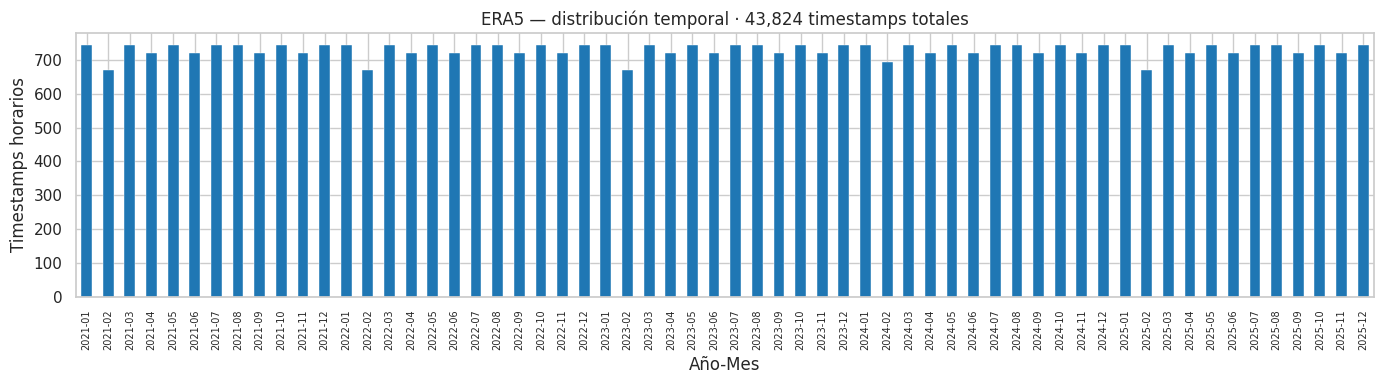


Timestamps totales : 43,824
Rango              : 2021-01-01 00:00:00 → 2025-12-31 23:00:00
Promedio/mes       : 730
Cobertura horaria nominal (24×30×60): 720 h/mes


In [24]:
times_era5 = parsear_tiempo(era5.time.values)
df_t_era5 = pd.DataFrame({"time": times_era5})
df_t_era5["año_mes"] = df_t_era5["time"].dt.to_period("M").astype(str)
conteo_era5 = df_t_era5.groupby("año_mes").size().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
conteo_era5.plot(kind="bar", ax=ax, color="#1f77b4", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Año-Mes")
ax.set_ylabel("Timestamps horarios")
ax.set_title(f"ERA5 — distribución temporal · {len(times_era5):,} timestamps totales")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
save_fig(fig, "era5_distribucion_temporal")
plt.show()

print(f"\nTimestamps totales : {len(times_era5):,}")
print(f"Rango              : {times_era5.min()} → {times_era5.max()}")
print(f"Promedio/mes       : {conteo_era5.mean():.0f}")
print(f"Cobertura horaria nominal (24×30×60): {24*30:.0f} h/mes")

Cargando 2000 timestamps en memoria...
  [fig] /kaggle/working/figuras_eda/era5_distribuciones_variables.png


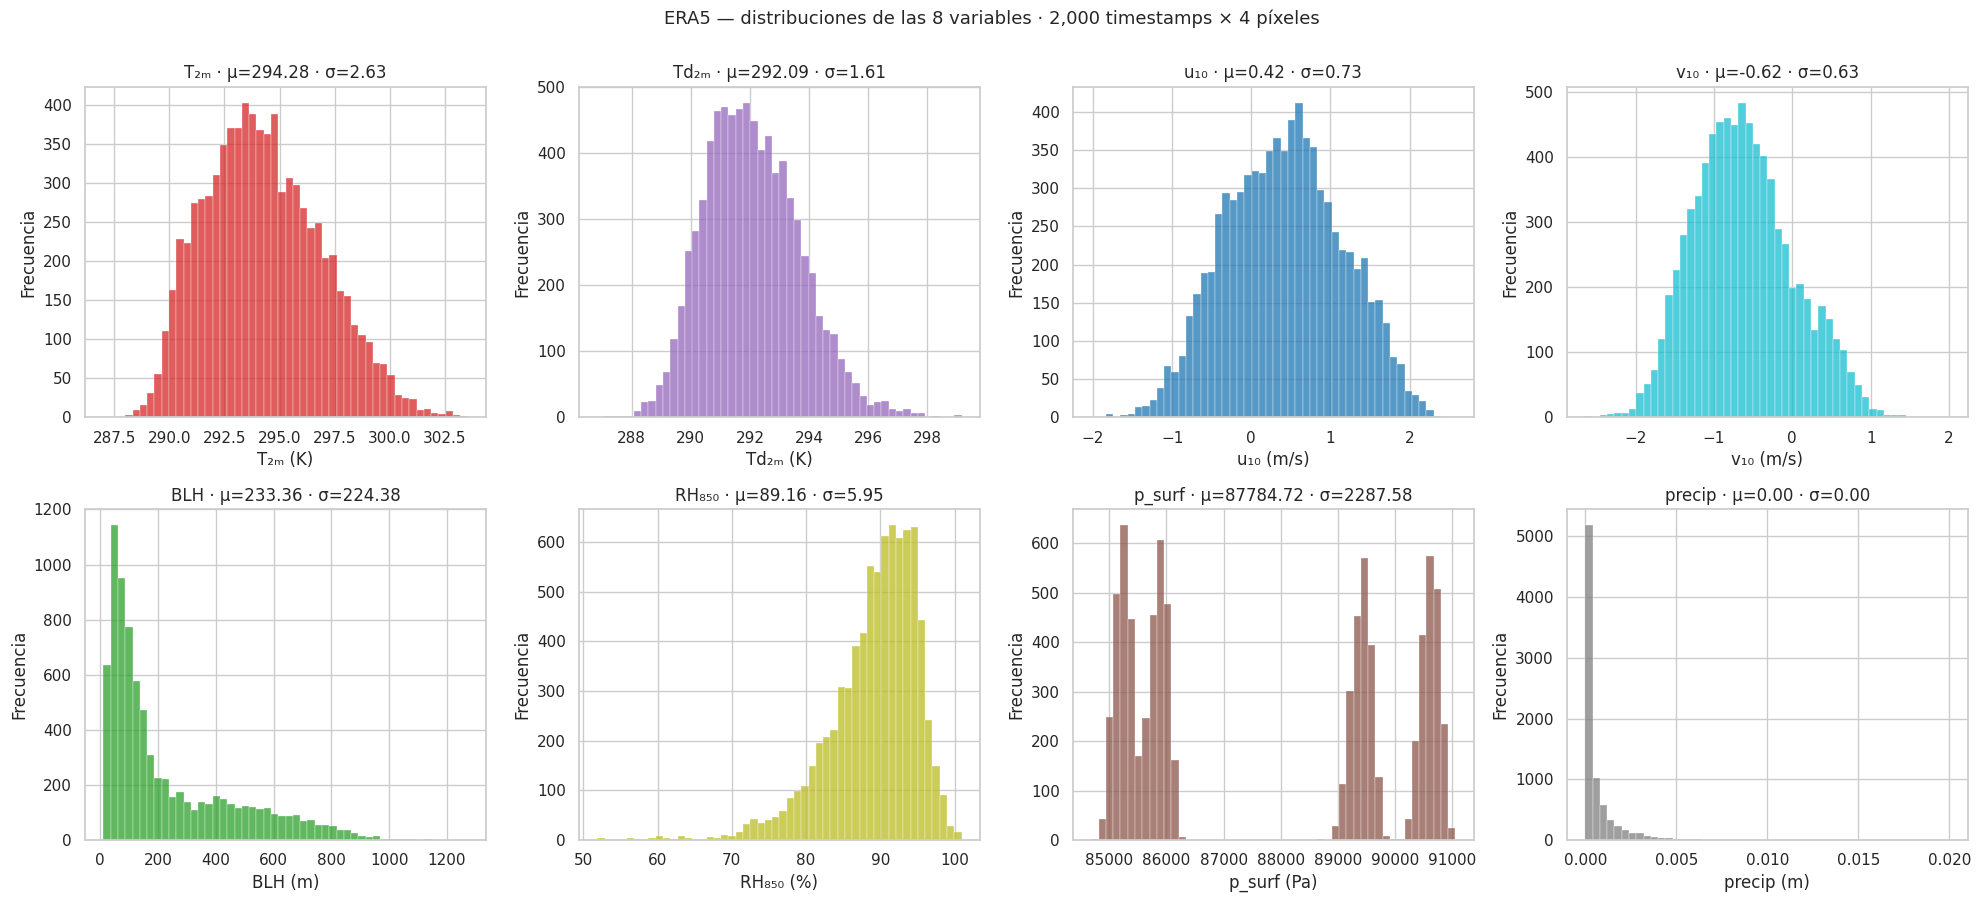

In [25]:
N_MUESTRA_ERA5 = 2000
rng_era5 = np.random.default_rng(SEED)
indices_era5 = rng_era5.choice(era5.sizes["time"], size=min(N_MUESTRA_ERA5, era5.sizes["time"]), replace=False)
indices_era5.sort()

print(f"Cargando {len(indices_era5)} timestamps en memoria...")
sub_era5 = era5.isel(time=indices_era5).load()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
valores_era5: dict[str, np.ndarray] = {}

for ax, (banda, label, unidad, color) in zip(axes.flat, VARS_ERA5):
    if USA_BANDAS_ERA5:
        arr = sub_era5.sel(band=banda)[nombre_var_era5].values
    else:
        arr = sub_era5[banda].values

    v_flat = arr.flatten().astype(np.float32)
    v_flat = v_flat[np.isfinite(v_flat)]
    valores_era5[banda] = v_flat

    ax.hist(v_flat, bins=50, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(f"{label} ({unidad})")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"{label} · μ={v_flat.mean():.2f} · σ={v_flat.std():.2f}")

plt.suptitle(
    f"ERA5 — distribuciones de las 8 variables · {len(indices_era5):,} timestamps × 4 píxeles",
    y=1.00, fontsize=13
)
plt.tight_layout()
save_fig(fig, "era5_distribuciones_variables")
plt.show()

  [fig] /kaggle/working/figuras_eda/era5_correlacion_variables.png


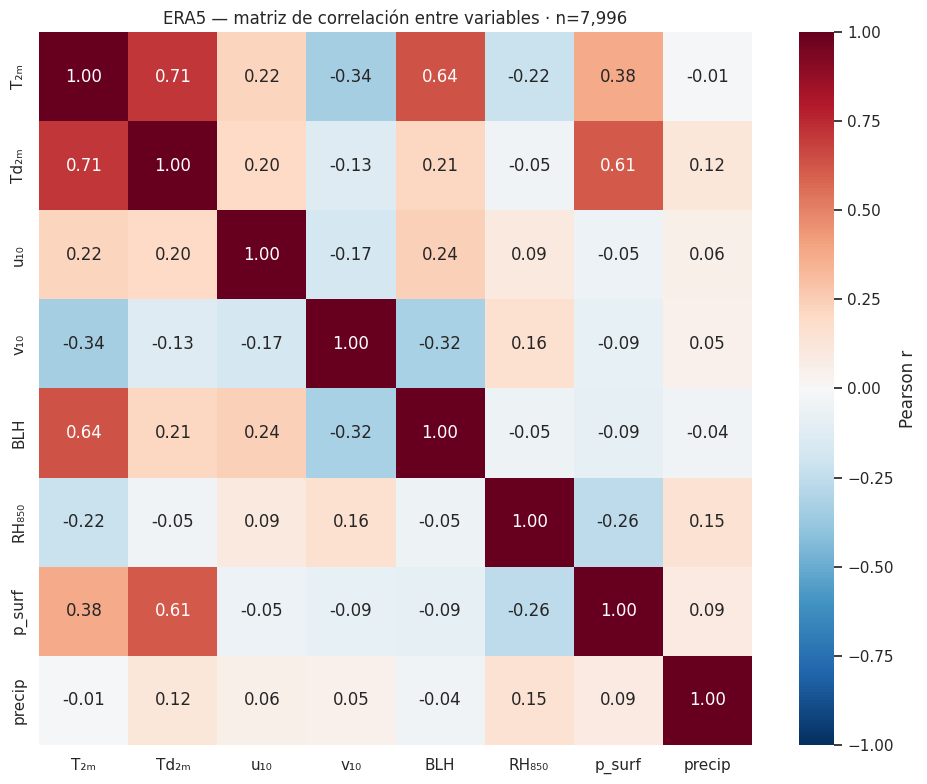


Pares con |r| > 0.5:
  T₂ₘ    ↔ Td₂ₘ  : r = +0.714
  T₂ₘ    ↔ BLH   : r = +0.637
  Td₂ₘ   ↔ p_surf: r = +0.613


In [26]:
n_min = min(len(v) for v in valores_era5.values())
df_corr = pd.DataFrame({
    label: valores_era5[banda][:n_min]
    for banda, label, _, _ in VARS_ERA5
})
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title(f"ERA5 — matriz de correlación entre variables · n={n_min:,}")
plt.tight_layout()
save_fig(fig, "era5_correlacion_variables")
plt.show()

print(f"\nPares con |r| > 0.5:")
pares: list[tuple[str, str, float]] = []
for i, a in enumerate(corr.columns):
    for j in range(i + 1, len(corr.columns)):
        b = corr.columns[j]
        r = float(corr.iloc[i, j])
        if abs(r) > 0.5:
            pares.append((a, b, r))
pares.sort(key=lambda t: -abs(t[2]))
for a, b, r in pares:
    print(f"  {a:6s} ↔ {b:6s}: r = {r:+.3f}")

  [fig] /kaggle/working/figuras_eda/era5_ciclo_diurno.png


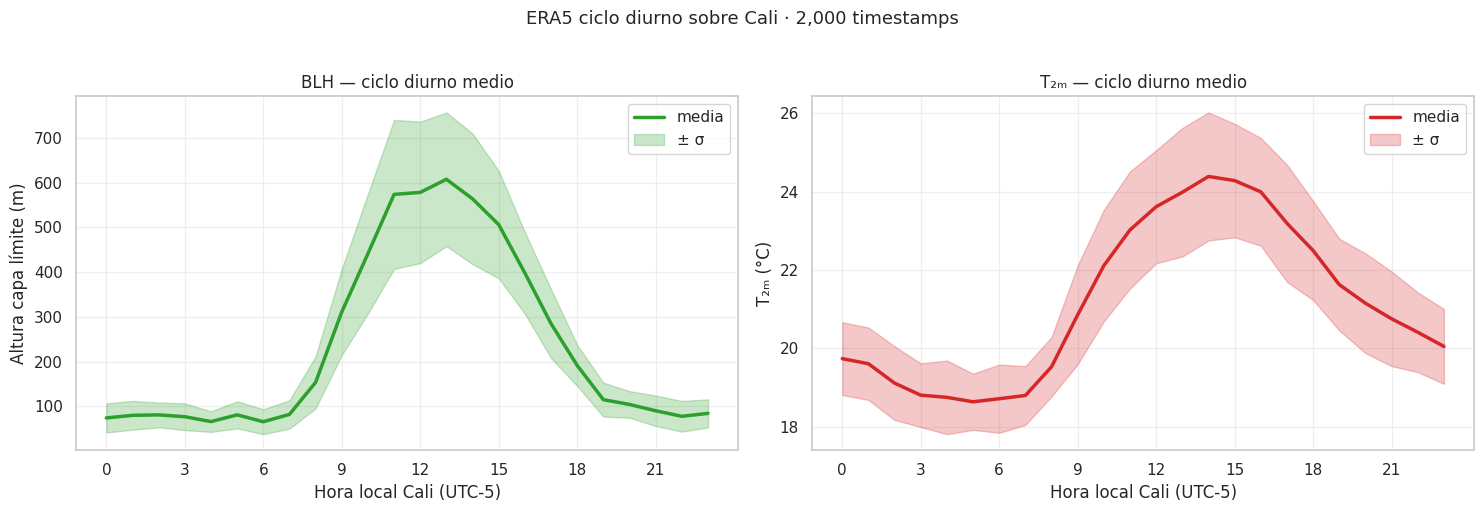


=== Ciclo diurno BLH ===
  Pico   : 13h (Cali) ·   607 m
  Valle  :  6h (Cali) ·    66 m
  Amplitud: 542 m

=== Ciclo diurno T₂ₘ ===
  Pico   : 14h (Cali) ·  24.4 °C
  Valle  :  5h (Cali) ·  18.6 °C
  Amplitud: 5.8 °C


In [27]:
horas_utc = parsear_tiempo(sub_era5.time.values).hour

if USA_BANDAS_ERA5:
    blh_pix = sub_era5.sel(band="boundary_layer_height")[nombre_var_era5].values
    t2m_pix = sub_era5.sel(band="temperature_2m")[nombre_var_era5].values
else:
    blh_pix = sub_era5["boundary_layer_height"].values
    t2m_pix = sub_era5["temperature_2m"].values

axis_spatial = tuple(range(1, blh_pix.ndim))
blh_serie = np.nanmean(blh_pix, axis=axis_spatial)
t2m_serie = np.nanmean(t2m_pix, axis=axis_spatial) - 273.15

df_diurno = pd.DataFrame({
    "hora_utc": horas_utc,
    "BLH": blh_serie,
    "T2m": t2m_serie,
})
df_diurno["hora_cali"] = (df_diurno["hora_utc"] - 5) % 24

ciclo = df_diurno.groupby("hora_cali").agg({"BLH": ["mean", "std"], "T2m": ["mean", "std"]}).sort_index()
horas = ciclo.index.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(horas, ciclo[("BLH", "mean")], color="#2ca02c", lw=2.5, label="media")
ax.fill_between(horas,
                ciclo[("BLH", "mean")] - ciclo[("BLH", "std")],
                ciclo[("BLH", "mean")] + ciclo[("BLH", "std")],
                alpha=0.25, color="#2ca02c", label="± σ")
ax.set_xlabel("Hora local Cali (UTC-5)")
ax.set_ylabel("Altura capa límite (m)")
ax.set_title("BLH — ciclo diurno medio")
ax.set_xticks(range(0, 24, 3))
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(horas, ciclo[("T2m", "mean")], color="#d62728", lw=2.5, label="media")
ax.fill_between(horas,
                ciclo[("T2m", "mean")] - ciclo[("T2m", "std")],
                ciclo[("T2m", "mean")] + ciclo[("T2m", "std")],
                alpha=0.25, color="#d62728", label="± σ")
ax.set_xlabel("Hora local Cali (UTC-5)")
ax.set_ylabel("T₂ₘ (°C)")
ax.set_title("T₂ₘ — ciclo diurno medio")
ax.set_xticks(range(0, 24, 3))
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle(
    f"ERA5 ciclo diurno sobre Cali · {len(df_diurno):,} timestamps",
    y=1.02, fontsize=13
)
plt.tight_layout()
save_fig(fig, "era5_ciclo_diurno")
plt.show()

print(f"\n=== Ciclo diurno BLH ===")
print(f"  Pico   : {int(ciclo[('BLH', 'mean')].idxmax()):>2}h (Cali) · {ciclo[('BLH', 'mean')].max():>5.0f} m")
print(f"  Valle  : {int(ciclo[('BLH', 'mean')].idxmin()):>2}h (Cali) · {ciclo[('BLH', 'mean')].min():>5.0f} m")
print(f"  Amplitud: {ciclo[('BLH', 'mean')].max() - ciclo[('BLH', 'mean')].min():.0f} m")

print(f"\n=== Ciclo diurno T₂ₘ ===")
print(f"  Pico   : {int(ciclo[('T2m', 'mean')].idxmax()):>2}h (Cali) · {ciclo[('T2m', 'mean')].max():>5.1f} °C")
print(f"  Valle  : {int(ciclo[('T2m', 'mean')].idxmin()):>2}h (Cali) · {ciclo[('T2m', 'mean')].min():>5.1f} °C")
print(f"  Amplitud: {ciclo[('T2m', 'mean')].max() - ciclo[('T2m', 'mean')].min():.1f} °C")

In [28]:
MODIS_FILL = -28672
MODIS_SCALE = 0.001

modis = cargar_zarr("MODIS")
inspeccionar_dataset(modis, "MODIS MAIAC")

if "band" in modis.coords:
    nombre_var_modis = list(modis.data_vars)[0]
    USA_BANDAS_MODIS = True
    print(f"\nEstructura coord-band con {len(modis.band)} bandas:")
    for b in modis.band.values:
        print(f"  {b}")
else:
    nombre_var_modis = None
    USA_BANDAS_MODIS = False
    print(f"\nEstructura por variables: {list(modis.data_vars)}")

print(f"\nMuestra time: {modis.time.values[:3]}")

# Detectar bandas reales para usar en celdas siguientes
if USA_BANDAS_MODIS:
    BANDAS_MODIS = [str(b) for b in modis.band.values]
else:
    BANDAS_MODIS = list(modis.data_vars)

BANDAS_MODIS_FISICAS = [b for b in BANDAS_MODIS if "QA" not in b.upper()]

print(f"\nBandas detectadas: {BANDAS_MODIS}")
print(f"Bandas físicas (escalables): {BANDAS_MODIS_FISICAS}")
print(f"\nCaveat (decisión #13): valores raw NO tienen scale_factor=0.001 aplicado")
print(f"  · FillValue documentado : {MODIS_FILL}")
print(f"  · Scale factor a aplicar: × {MODIS_SCALE}")

=== MODIS MAIAC ===
  Dimensiones : {'time': 1826, 'band': 4, 'y': 43, 'x': 43}
  Variables   : ['data']
  Bandas (4): [np.str_('Optical_Depth_047'), np.str_('Optical_Depth_055'), np.str_('Column_WV'), np.str_('AOD_QA')]
  Tiempo      : 1826 timestamps · dtype=<U8
  Muestra     : ['A2021001' 'A2021002']
  Espacial    : y=43 px · x=43 px · res≈0.00833° (~0.92 km)

Estructura coord-band con 4 bandas:
  Optical_Depth_047
  Optical_Depth_055
  Column_WV
  AOD_QA

Muestra time: ['A2021001' 'A2021002' 'A2021003']

Bandas detectadas: ['Optical_Depth_047', 'Optical_Depth_055', 'Column_WV', 'AOD_QA']
Bandas físicas (escalables): ['Optical_Depth_047', 'Optical_Depth_055', 'Column_WV']

Caveat (decisión #13): valores raw NO tienen scale_factor=0.001 aplicado
  · FillValue documentado : -28672
  · Scale factor a aplicar: × 0.001


  [fig] /kaggle/working/figuras_eda/modis_distribucion_temporal.png


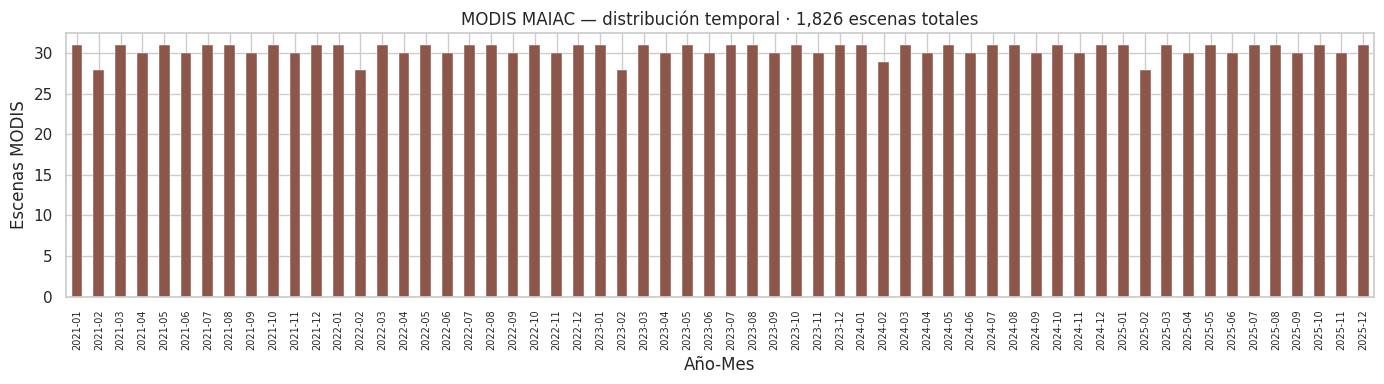


Escenas totales : 1,826
Rango           : 2021-01-01 00:00:00 → 2025-12-31 00:00:00
Promedio/mes    : 30


In [29]:
times_modis = parsear_tiempo(modis.time.values)
df_t_modis = pd.DataFrame({"time": times_modis})
df_t_modis["año_mes"] = df_t_modis["time"].dt.to_period("M").astype(str)
conteo_modis = df_t_modis.groupby("año_mes").size().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
conteo_modis.plot(kind="bar", ax=ax, color="#8c564b", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Año-Mes")
ax.set_ylabel("Escenas MODIS")
ax.set_title(f"MODIS MAIAC — distribución temporal · {len(times_modis):,} escenas totales")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
save_fig(fig, "modis_distribucion_temporal")
plt.show()

print(f"\nEscenas totales : {len(times_modis):,}")
print(f"Rango           : {times_modis.min()} → {times_modis.max()}")
print(f"Promedio/mes    : {conteo_modis.mean():.0f}")

Cargando 500 escenas...
  [fig] /kaggle/working/figuras_eda/modis_raw_vs_escalado.png


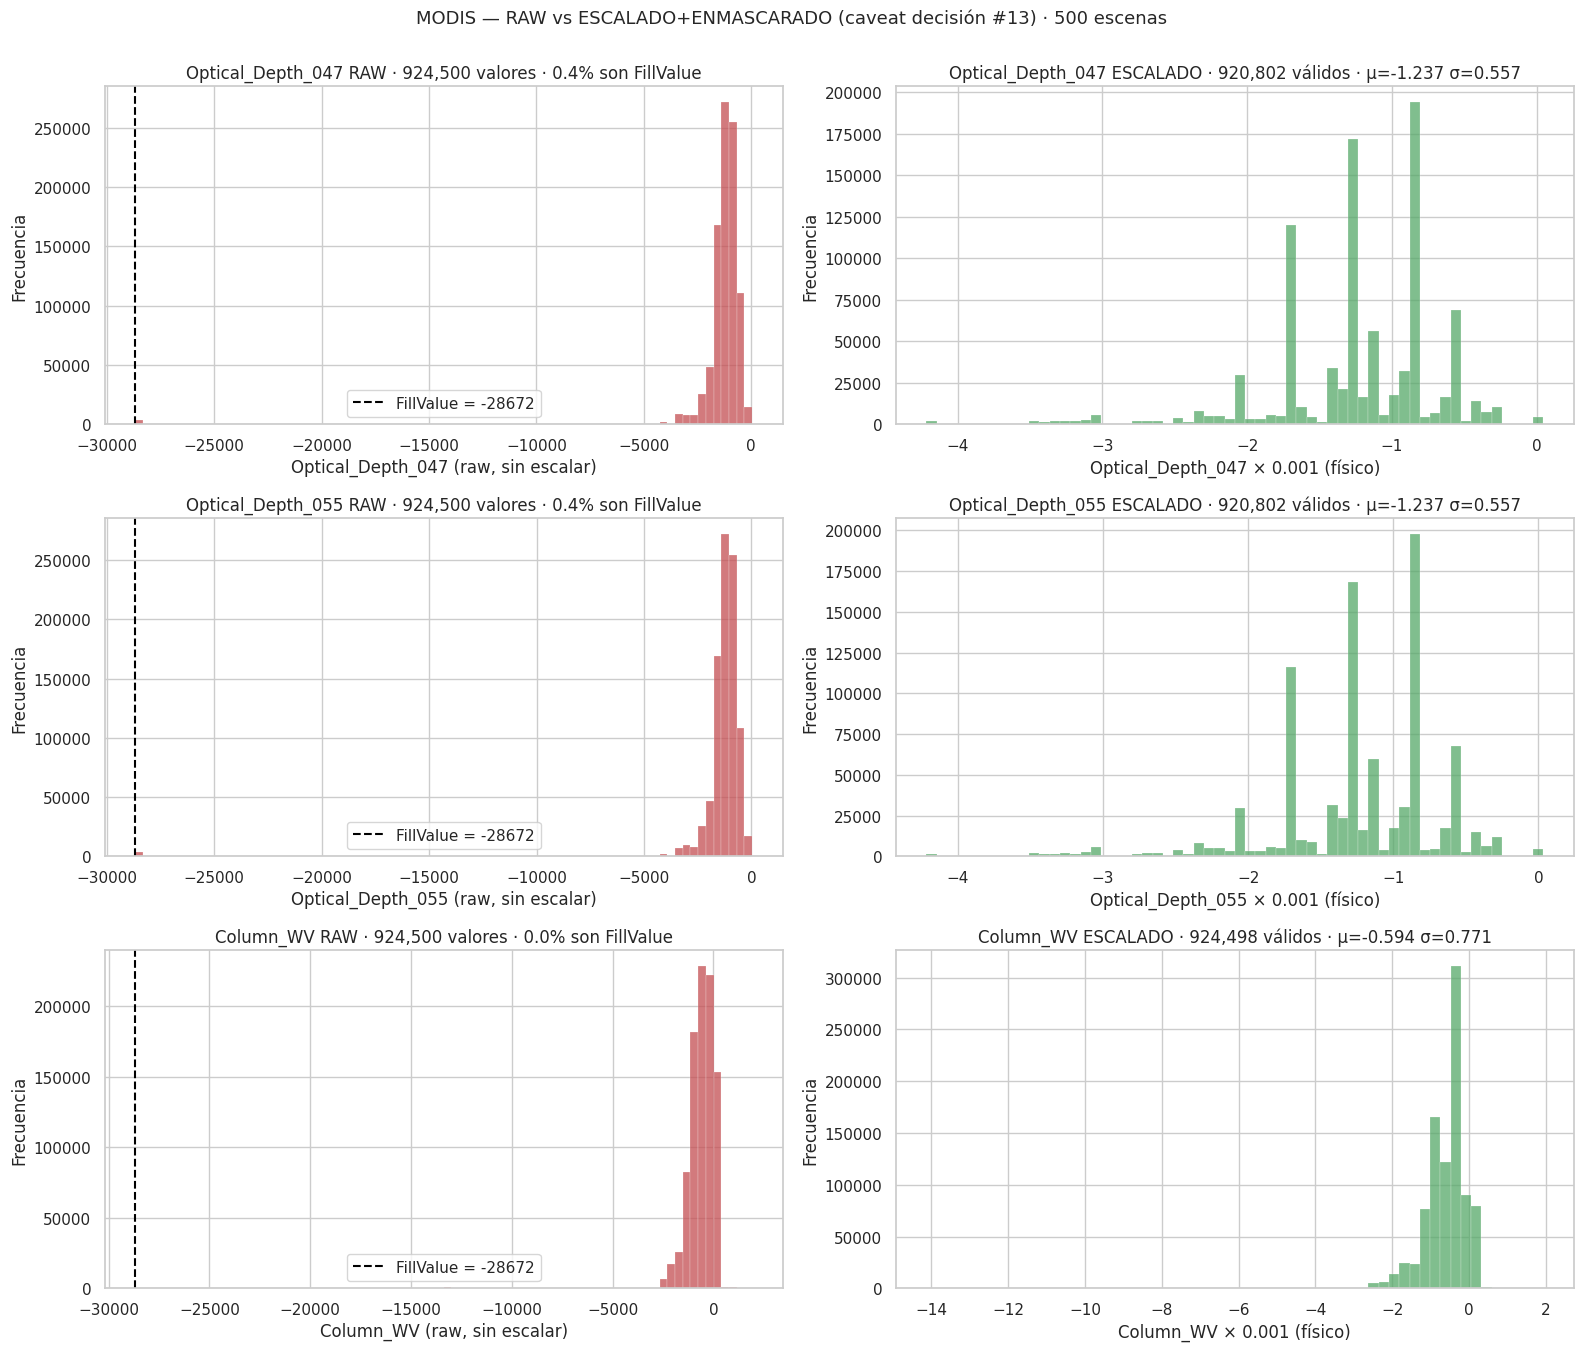


=== Resumen RAW vs ESCALADO por banda ===

Optical_Depth_047:
  Total finitos     :    924,500
  FillValue (-28672):      3,698  (0.4%)
  Válidos escalados :    920,802
  Rango escalado    : [-4.216, 0.045]
  Mediana escalada  : -1.247

Optical_Depth_055:
  Total finitos     :    924,500
  FillValue (-28672):      3,698  (0.4%)
  Válidos escalados :    920,802
  Rango escalado    : [-4.216, 0.033]
  Mediana escalada  : -1.247

Column_WV:
  Total finitos     :    924,500
  FillValue (-28672):          2  (0.0%)
  Válidos escalados :    924,498
  Rango escalado    : [-14.125, 1.924]
  Mediana escalada  : -0.414


In [30]:
N_MUESTRA_MODIS = 500
rng_modis = np.random.default_rng(SEED)
indices_modis = rng_modis.choice(modis.sizes["time"], size=min(N_MUESTRA_MODIS, modis.sizes["time"]), replace=False)
indices_modis.sort()

print(f"Cargando {len(indices_modis)} escenas...")
sub_modis = modis.isel(time=indices_modis).load()

fig, axes = plt.subplots(len(BANDAS_MODIS_FISICAS), 2, figsize=(16, 4.5 * len(BANDAS_MODIS_FISICAS)))
if len(BANDAS_MODIS_FISICAS) == 1:
    axes = axes.reshape(1, -1)

valores_modis: dict[str, dict[str, np.ndarray]] = {}

for i, banda in enumerate(BANDAS_MODIS_FISICAS):
    if USA_BANDAS_MODIS:
        arr = sub_modis.sel(band=banda)[nombre_var_modis].values.astype(np.float32)
    else:
        arr = sub_modis[banda].values.astype(np.float32)

    raw_flat = arr.flatten()
    raw_finitos = raw_flat[np.isfinite(raw_flat)]

    mask_validos = raw_finitos != MODIS_FILL
    valores_clean = raw_finitos[mask_validos] * MODIS_SCALE

    valores_modis[banda] = {
        "raw": raw_finitos,
        "clean": valores_clean,
        "n_fill": int((~mask_validos).sum()),
        "n_validos": int(mask_validos.sum()),
    }

    ax_raw = axes[i, 0]
    ax_raw.hist(raw_finitos, bins=80, color="#c44e52", alpha=0.75, edgecolor="white", linewidth=0.2)
    ax_raw.axvline(MODIS_FILL, color="black", linestyle="--", linewidth=1.5, label=f"FillValue = {MODIS_FILL}")
    ax_raw.set_xlabel(f"{banda} (raw, sin escalar)")
    ax_raw.set_ylabel("Frecuencia")
    pct_fill = 100 * (1 - mask_validos.mean())
    ax_raw.set_title(f"{banda} RAW · {len(raw_finitos):,} valores · {pct_fill:.1f}% son FillValue")
    ax_raw.legend()

    ax_clean = axes[i, 1]
    if len(valores_clean) > 0:
        ax_clean.hist(valores_clean, bins=60, color="#55a868", alpha=0.75, edgecolor="white", linewidth=0.2)
        ax_clean.set_title(
            f"{banda} ESCALADO · {len(valores_clean):,} válidos · "
            f"μ={valores_clean.mean():.3f} σ={valores_clean.std():.3f}"
        )
    else:
        ax_clean.text(0.5, 0.5, "Sin valores válidos", ha="center", va="center", transform=ax_clean.transAxes)
        ax_clean.set_title(f"{banda} ESCALADO · vacío")
    ax_clean.set_xlabel(f"{banda} × {MODIS_SCALE} (físico)")
    ax_clean.set_ylabel("Frecuencia")

plt.suptitle(
    f"MODIS — RAW vs ESCALADO+ENMASCARADO (caveat decisión #13) · {len(indices_modis)} escenas",
    y=1.00, fontsize=13
)
plt.tight_layout()
save_fig(fig, "modis_raw_vs_escalado")
plt.show()

print("\n=== Resumen RAW vs ESCALADO por banda ===")
for banda, datos in valores_modis.items():
    print(f"\n{banda}:")
    print(f"  Total finitos     : {len(datos['raw']):>10,}")
    print(f"  FillValue ({MODIS_FILL}): {datos['n_fill']:>10,}  ({100*datos['n_fill']/len(datos['raw']):.1f}%)")
    print(f"  Válidos escalados : {datos['n_validos']:>10,}")
    if len(datos["clean"]) > 0:
        print(f"  Rango escalado    : [{datos['clean'].min():.3f}, {datos['clean'].max():.3f}]")
        print(f"  Mediana escalada  : {np.median(datos['clean']):.3f}")

Banda usada para mapa: Optical_Depth_055
  [fig] /kaggle/working/figuras_eda/modis_mapa_promedio.png


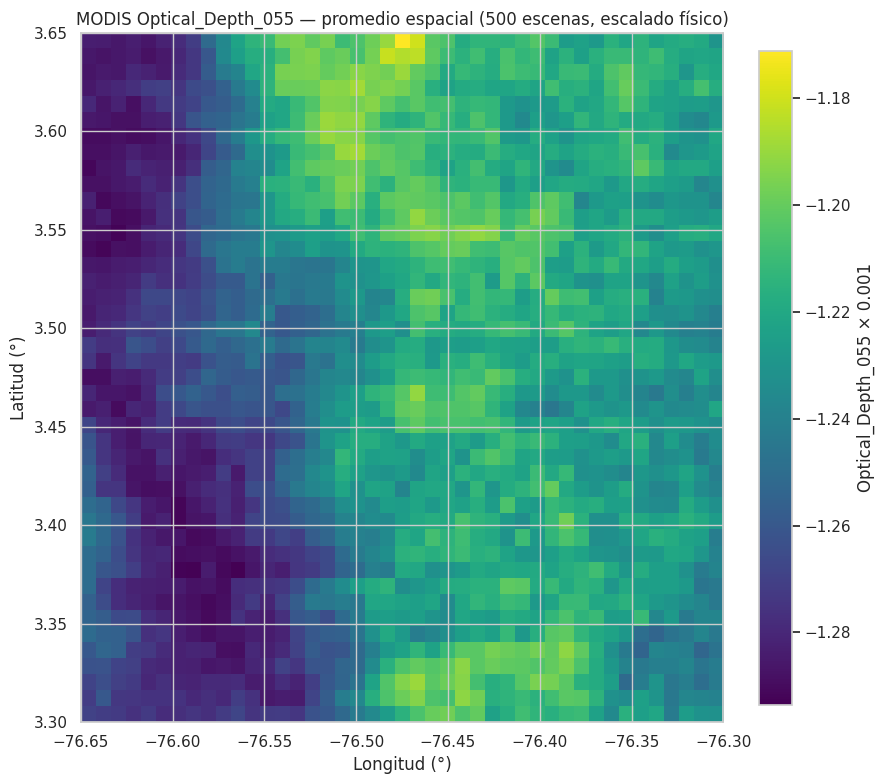

In [31]:
BANDA_MODIS_PRINCIPAL = next((b for b in BANDAS_MODIS if "055" in b.lower() or "550" in b.lower() or "aod" in b.lower()),
                              BANDAS_MODIS[0])
print(f"Banda usada para mapa: {BANDA_MODIS_PRINCIPAL}")

if USA_BANDAS_MODIS:
    arr_mapa = sub_modis.sel(band=BANDA_MODIS_PRINCIPAL)[nombre_var_modis].values.astype(np.float32)
else:
    arr_mapa = sub_modis[BANDA_MODIS_PRINCIPAL].values.astype(np.float32)

arr_mapa_clean = np.where(arr_mapa == MODIS_FILL, np.nan, arr_mapa * MODIS_SCALE)
promedio_modis = np.nanmean(arr_mapa_clean, axis=0)

fig, ax = plt.subplots(figsize=(9, 8))
extent_modis = [BBOX_CALI["lon_min"], BBOX_CALI["lon_max"],
                BBOX_CALI["lat_min"], BBOX_CALI["lat_max"]]
im = ax.imshow(promedio_modis, cmap="viridis", aspect="auto", extent=extent_modis, origin="lower")
ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(f"MODIS {BANDA_MODIS_PRINCIPAL} — promedio espacial ({len(indices_modis)} escenas, escalado físico)")
plt.colorbar(im, ax=ax, fraction=0.046, label=f"{BANDA_MODIS_PRINCIPAL} × {MODIS_SCALE}")
plt.tight_layout()
save_fig(fig, "modis_mapa_promedio")
plt.show()

  [fig] /kaggle/working/figuras_eda/modis_cobertura_efectiva.png


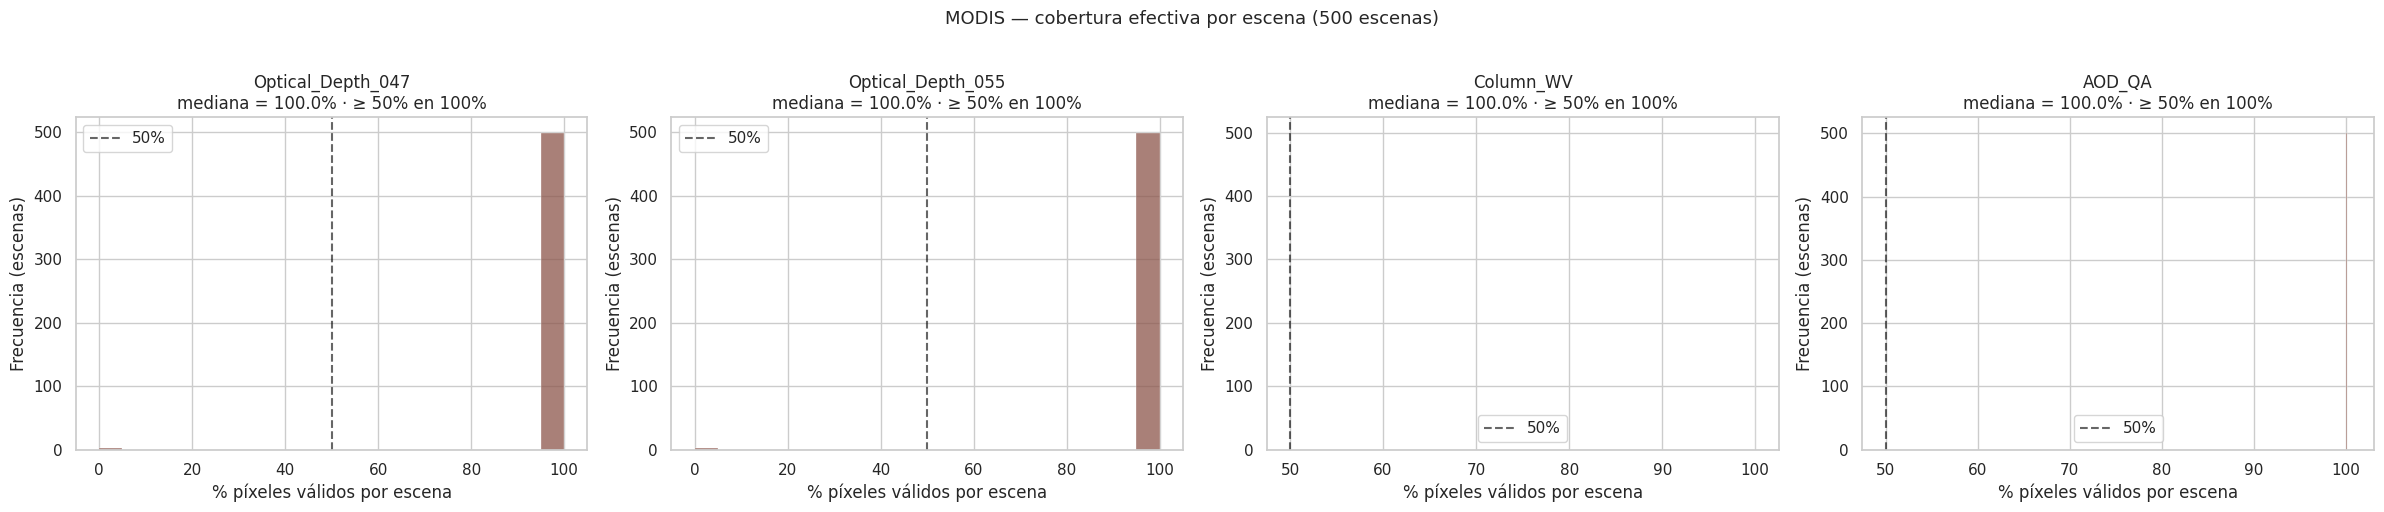


=== Cobertura efectiva por banda ===
  Optical_Depth_047: mediana 100.0% · ≥ 50% en 100% de escenas
  Optical_Depth_055: mediana 100.0% · ≥ 50% en 100% de escenas
  Column_WV: mediana 100.0% · ≥ 50% en 100% de escenas
  AOD_QA: mediana 100.0% · ≥ 50% en 100% de escenas


In [32]:
fig, axes = plt.subplots(1, len(BANDAS_MODIS), figsize=(6 * len(BANDAS_MODIS), 5))
if len(BANDAS_MODIS) == 1:
    axes = [axes]

cobertura_resumen = {}
for ax, banda in zip(axes, BANDAS_MODIS):
    if USA_BANDAS_MODIS:
        arr = sub_modis.sel(band=banda)[nombre_var_modis].values
    else:
        arr = sub_modis[banda].values

    axis_spatial_modis = tuple(range(1, arr.ndim))
    mask = (arr != MODIS_FILL) & np.isfinite(arr)
    pct_validos = mask.mean(axis=axis_spatial_modis) * 100

    ax.hist(pct_validos, bins=20, color="#8c564b", alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(50, color="black", linestyle="--", linewidth=1.5, alpha=0.6, label="50%")
    mediana = float(np.median(pct_validos))
    pct_ge50 = float((pct_validos >= 50).mean() * 100)
    cobertura_resumen[banda] = {"mediana": mediana, "pct_ge50": pct_ge50}
    ax.set_xlabel("% píxeles válidos por escena")
    ax.set_ylabel("Frecuencia (escenas)")
    ax.set_title(f"{banda}\nmediana = {mediana:.1f}% · ≥ 50% en {pct_ge50:.0f}%")
    ax.legend()

plt.suptitle(f"MODIS — cobertura efectiva por escena ({len(indices_modis)} escenas)", y=1.02, fontsize=13)
plt.tight_layout()
save_fig(fig, "modis_cobertura_efectiva")
plt.show()

print("\n=== Cobertura efectiva por banda ===")
for banda, datos in cobertura_resumen.items():
    print(f"  {banda}: mediana {datos['mediana']:.1f}% · ≥ 50% en {datos['pct_ge50']:.0f}% de escenas")

In [33]:
import json

dagma_dir = PANEL_BASE / "dagma"
dagma_horario = pd.read_parquet(dagma_dir / "dagma_cvc_horario_raw.parquet")

print(f"Shape: {dagma_horario.shape}")
print(f"Columnas: {dagma_horario.columns.tolist()}")
print(f"\nDtypes:")
print(dagma_horario.dtypes.to_string())
print(f"\nMuestra (5 filas):")
print(dagma_horario.head().to_string())

manifest_path = dagma_dir / "manifest_ground_truth.json"
if manifest_path.exists():
    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)
    print(f"\nManifest:")
    print(json.dumps(manifest, indent=2, ensure_ascii=False))

col_estacion = "nombre_est" if "nombre_est" in dagma_horario.columns else next(
    (c for c in dagma_horario.columns if any(k in c.lower() for k in ("estacion", "station", "site"))),
    None
)
col_time = next(
    (c for c in dagma_horario.columns if any(k in c.lower() for k in ("time", "fecha", "datetime", "date"))),
    None
)
col_cont = next(
    (c for c in dagma_horario.columns
     if any(k in c.lower() for k in ("contam", "param", "variable", "magnitud", "msfl", "code", "pollut"))),
    None
)

if col_cont is None:
    contaminantes_norm = {"NO2", "SO2", "O3"}
    for c in dagma_horario.columns:
        if dagma_horario[c].dtype == object:
            muestra = set(
                dagma_horario[c].dropna().astype(str).str.upper().str.strip().unique()[:30]
            )
            if muestra & contaminantes_norm:
                col_cont = c
                print(f"  [info] col_cont detectada por contenido: '{c}' (valores únicos: {muestra & contaminantes_norm})")
                break

col_valor = next(
    (c for c in dagma_horario.columns if any(k in c.lower() for k in ("valor", "value", "conc", "medic"))),
    None
)

print(f"\n=== Columnas detectadas ===")
print(f"  Estación      : {col_estacion}")
print(f"  Tiempo        : {col_time}")
print(f"  Contaminante  : {col_cont}")
print(f"  Valor         : {col_valor}")

if col_time is not None and not pd.api.types.is_datetime64_any_dtype(dagma_horario[col_time]):
    dagma_horario[col_time] = pd.to_datetime(dagma_horario[col_time], errors="coerce")

if col_estacion is not None:
    print(f"\nEstaciones únicas ({dagma_horario[col_estacion].nunique()}):")
    print(dagma_horario[col_estacion].value_counts().to_string())

if col_cont is not None:
    print(f"\nContaminantes únicos ({dagma_horario[col_cont].nunique()}):")
    print(dagma_horario[col_cont].value_counts().to_string())

Shape: (107291, 14)
Columnas: ['estacion_id', 'nombre_est', 'nombre_fgda', 'msfl_code', 'med_concentracion_estandar', 'med_fecha_inicio', 'med_fecha_final', 'nombre_unidad', 'sigla_unidad', 'latitud', 'longitud', 'altitud', 'municipio', 'departamento']

Dtypes:
estacion_id                           object
nombre_est                            object
nombre_fgda                           object
msfl_code                             object
med_concentracion_estandar           float64
med_fecha_inicio              datetime64[us]
med_fecha_final               datetime64[us]
nombre_unidad                         object
sigla_unidad                          object
latitud                              float64
longitud                             float64
altitud                                int64
municipio                             object
departamento                          object

Muestra (5 filas):
  estacion_id  nombre_est nombre_fgda msfl_code  med_concentracion_estandar    med_fecha

  [fig] /kaggle/working/figuras_eda/dagma_cobertura_temporal.png


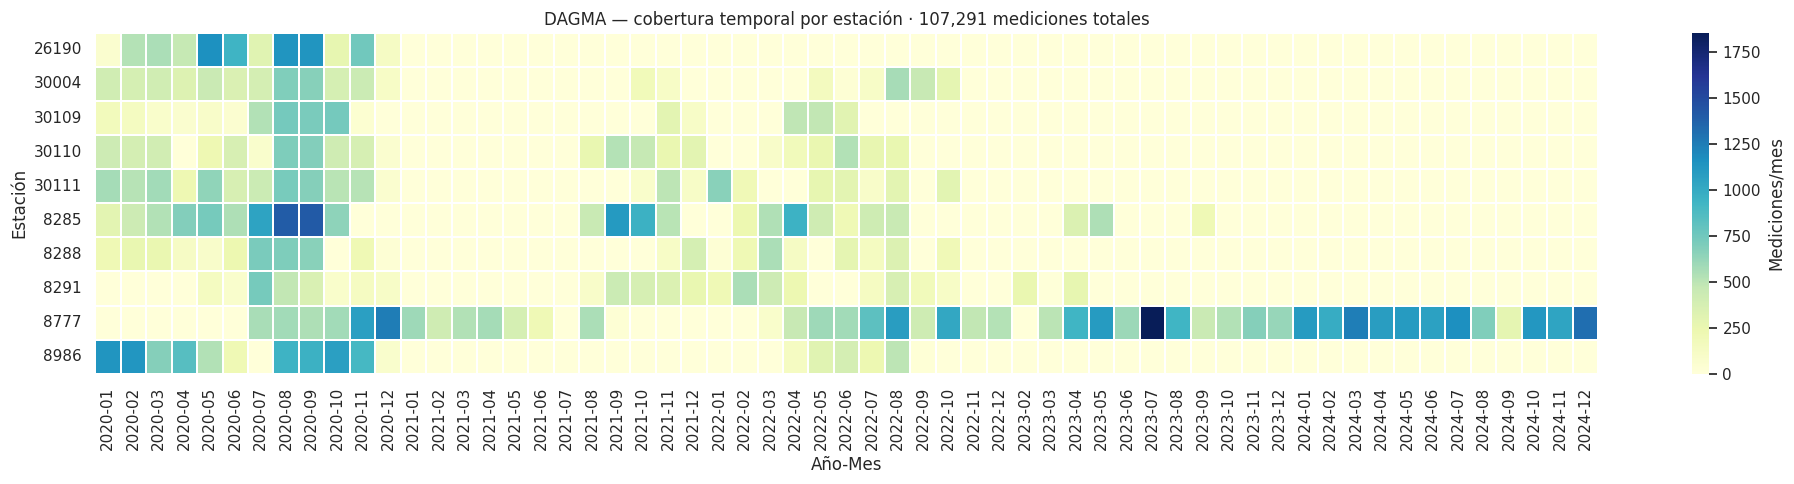


=== Cobertura por estación (% del total esperable) ===
  26190                     ·  7,435 mediciones · 12/59 meses ·  17.5%
  30004                     ·  6,939 mediciones · 20/59 meses ·  16.3%
  30109                     ·  5,053 mediciones · 16/59 meses ·  11.9%
  30110                     ·  7,507 mediciones · 24/59 meses ·  17.7%
  30111                     ·  8,627 mediciones · 22/59 meses ·  20.3%
  8285                      · 15,080 mediciones · 25/59 meses ·  35.5%
  8288                      ·  5,861 mediciones · 21/59 meses ·  13.8%
  8291                      ·  6,350 mediciones · 25/59 meses ·  14.9%
  8777                      · 34,372 mediciones · 46/59 meses ·  80.9%
  8986                      · 10,067 mediciones · 17/59 meses ·  23.7%


In [34]:
dagma_horario["año_mes"] = dagma_horario[col_time].dt.to_period("M").astype(str)
cobertura = dagma_horario.groupby([col_estacion, "año_mes"]).size().unstack(fill_value=0)

cobertura = cobertura.reindex(
    sorted(cobertura.columns, key=lambda s: pd.Period(s, freq="M")),
    axis=1
)

fig, ax = plt.subplots(figsize=(20, max(4, 0.5 * len(cobertura.index))))
sns.heatmap(
    cobertura, cmap="YlGnBu", cbar_kws={"label": "Mediciones/mes"},
    ax=ax, linewidths=0.2, linecolor="white"
)
ax.set_title(f"DAGMA — cobertura temporal por estación · {len(dagma_horario):,} mediciones totales")
ax.set_xlabel("Año-Mes")
ax.set_ylabel("Estación")
plt.tight_layout()
save_fig(fig, "dagma_cobertura_temporal")
plt.show()

n_meses = cobertura.shape[1]
horas_esperadas = 24 * 30
print(f"\n=== Cobertura por estación (% del total esperable) ===")
for estacion in cobertura.index:
    total_real = cobertura.loc[estacion].sum()
    total_esperado = n_meses * horas_esperadas
    pct = 100 * total_real / total_esperado
    meses_activos = int((cobertura.loc[estacion] > 0).sum())
    print(f"  {estacion!s:<25} · {total_real:>6,} mediciones · {meses_activos:>2}/{n_meses} meses · {pct:5.1f}%")

Contaminantes disponibles: ['O3', 'SO2', 'NO2']

Mapeo proyecto → DAGMA:
  NO2 → 'NO2'
  SO2 → 'SO2'
  O3 → 'O3'
  [fig] /kaggle/working/figuras_eda/dagma_distribuciones_por_estacion.png


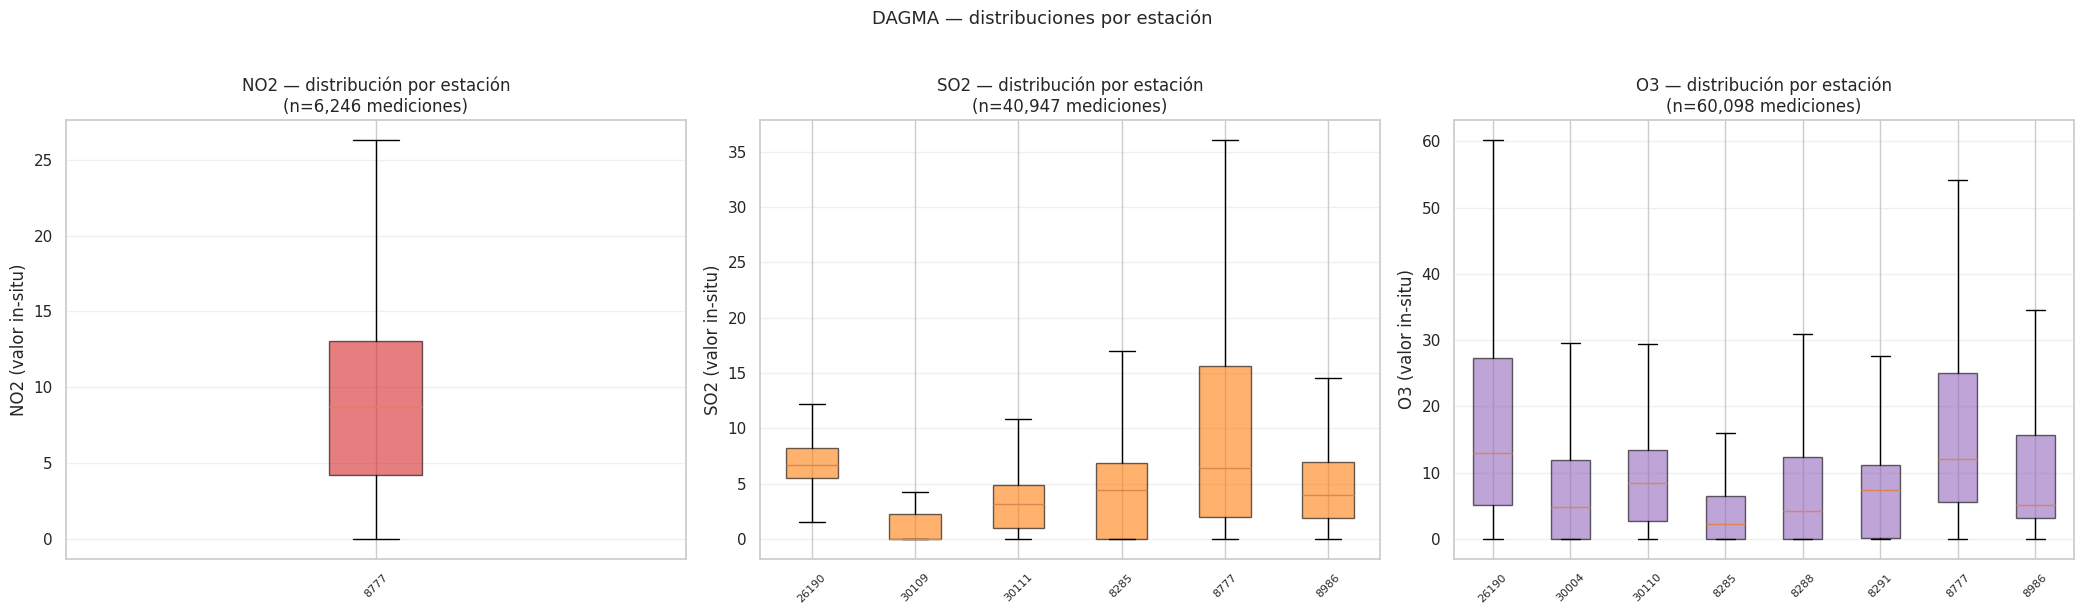


=== Resumen estadístico por estación × contaminante ===
contaminante estacion     n  mediana    p95
         NO2     8777  6246     8.70 23.500
         SO2    26190  3297     6.68 11.760
         SO2    30109  5053     0.00  3.220
         SO2    30111  8627     3.19  7.780
         SO2     8285  7770     4.45 11.730
         SO2     8777 12035     6.45 51.818
         SO2     8986  4165     3.93 12.960
          O3    26190  4138    12.96 80.203
          O3    30004  6939     4.77 33.472
          O3    30110  7507     8.51 49.678
          O3     8285  7310     2.28 29.472
          O3     8288  5861     4.22 74.840
          O3     8291  6350     7.37 29.100
          O3     8777 16091    12.00 68.750
          O3     8986  5902     5.11 57.476


In [35]:
contaminantes_unicos = dagma_horario[col_cont].dropna().unique().tolist()
print(f"Contaminantes disponibles: {contaminantes_unicos}")

mapeo_contaminantes = {}
for cont in CONTAMINANTES:
    key_norm = cont.replace("₂", "2").replace("₃", "3").lower()
    for c_real in contaminantes_unicos:
        c_norm = str(c_real).lower().replace(" ", "")
        if key_norm in c_norm or c_norm in key_norm:
            mapeo_contaminantes[cont] = c_real
            break

print(f"\nMapeo proyecto → DAGMA:")
for k, v in mapeo_contaminantes.items():
    print(f"  {k} → '{v}'")

fig, axes = plt.subplots(1, len(mapeo_contaminantes), figsize=(7 * len(mapeo_contaminantes), 6))
if len(mapeo_contaminantes) == 1:
    axes = [axes]

resumen_estadistico = []

for ax, (cont_proj, cont_real) in zip(axes, mapeo_contaminantes.items()):
    df_cont = dagma_horario[dagma_horario[col_cont] == cont_real].copy()
    df_cont = df_cont.dropna(subset=[col_valor])

    if len(df_cont) == 0:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{cont_proj} — sin datos")
        continue

    estaciones_orden = sorted(df_cont[col_estacion].unique())
    data_por_est = [df_cont[df_cont[col_estacion] == e][col_valor].values for e in estaciones_orden]

    bp = ax.boxplot(data_por_est, labels=estaciones_orden, showfliers=False, patch_artist=True)
    color = PALETA_CONTAMINANTES[cont_proj.replace("₂", "2").replace("₃", "3").upper()]
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_ylabel(f"{cont_proj} (valor in-situ)")
    ax.set_title(f"{cont_proj} — distribución por estación\n(n={len(df_cont):,} mediciones)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.3, axis="y")

    for est in estaciones_orden:
        vals = df_cont[df_cont[col_estacion] == est][col_valor]
        resumen_estadistico.append({
            "contaminante": cont_proj,
            "estacion": est,
            "n": len(vals),
            "mediana": float(vals.median()),
            "p95": float(vals.quantile(0.95)) if len(vals) else np.nan,
        })

plt.suptitle(f"DAGMA — distribuciones por estación", y=1.02, fontsize=13)
plt.tight_layout()
save_fig(fig, "dagma_distribuciones_por_estacion")
plt.show()

print("\n=== Resumen estadístico por estación × contaminante ===")
df_resumen = pd.DataFrame(resumen_estadistico)
print(df_resumen.to_string(index=False))

  [fig] /kaggle/working/figuras_eda/dagma_ciclo_diurno.png


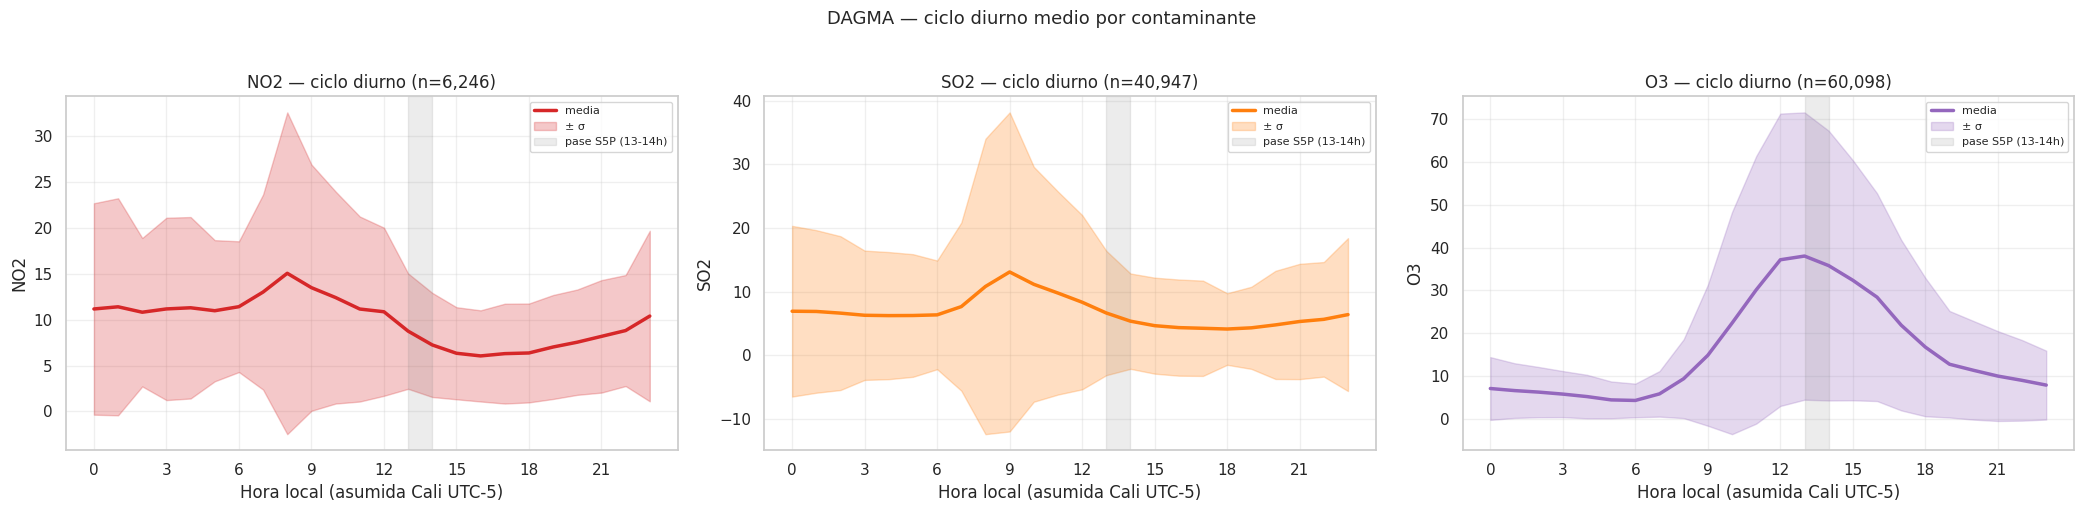


=== Ciclo diurno DAGMA — picos vs valle (hora local) ===
  NO2: pico  8h (15.07) · valle 16h (6.05) · amplitud 9.02
     valor en ventana S5P (13-14h): 8.00
  SO2: pico  9h (13.10) · valle 18h (4.13) · amplitud 8.97
     valor en ventana S5P (13-14h): 6.01
  O3: pico 13h (38.04) · valle  6h (4.28) · amplitud 33.76
     valor en ventana S5P (13-14h): 36.92


In [36]:
dagma_horario["hora_local"] = dagma_horario[col_time].dt.hour
dagma_horario["dia_semana"] = dagma_horario[col_time].dt.day_name()

fig, axes = plt.subplots(1, len(mapeo_contaminantes), figsize=(7 * len(mapeo_contaminantes), 5))
if len(mapeo_contaminantes) == 1:
    axes = [axes]

for ax, (cont_proj, cont_real) in zip(axes, mapeo_contaminantes.items()):
    df_cont = dagma_horario[dagma_horario[col_cont] == cont_real].dropna(subset=[col_valor])
    if len(df_cont) == 0:
        continue

    ciclo_d = df_cont.groupby("hora_local")[col_valor].agg(["mean", "std", "count"])

    color = PALETA_CONTAMINANTES[cont_proj.replace("₂", "2").replace("₃", "3").upper()]
    ax.plot(ciclo_d.index, ciclo_d["mean"], color=color, lw=2.5, label="media")
    ax.fill_between(ciclo_d.index,
                    ciclo_d["mean"] - ciclo_d["std"],
                    ciclo_d["mean"] + ciclo_d["std"],
                    alpha=0.25, color=color, label="± σ")
    ax.axvspan(13, 14, alpha=0.15, color="gray", label="pase S5P (13-14h)")
    ax.set_xlabel("Hora local (asumida Cali UTC-5)")
    ax.set_ylabel(f"{cont_proj}")
    ax.set_title(f"{cont_proj} — ciclo diurno (n={len(df_cont):,})")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(f"DAGMA — ciclo diurno medio por contaminante", y=1.02, fontsize=13)
plt.tight_layout()
save_fig(fig, "dagma_ciclo_diurno")
plt.show()

print("\n=== Ciclo diurno DAGMA — picos vs valle (hora local) ===")
for cont_proj, cont_real in mapeo_contaminantes.items():
    df_cont = dagma_horario[dagma_horario[col_cont] == cont_real].dropna(subset=[col_valor])
    if len(df_cont) == 0:
        continue
    ciclo_d = df_cont.groupby("hora_local")[col_valor].mean()
    hora_pico = int(ciclo_d.idxmax())
    hora_valle = int(ciclo_d.idxmin())
    print(f"  {cont_proj}: pico {hora_pico:>2}h ({ciclo_d.max():.2f}) · valle {hora_valle:>2}h ({ciclo_d.min():.2f}) · amplitud {ciclo_d.max()-ciclo_d.min():.2f}")
    valor_s5p = ciclo_d.loc[13:14].mean() if all(h in ciclo_d.index for h in [13, 14]) else np.nan
    if not np.isnan(valor_s5p):
        print(f"     valor en ventana S5P (13-14h): {valor_s5p:.2f}")

Mediciones DAGMA en 2020 : 52,192 (48.6% del total)
Rango exacto 2020        : 2020-01-01 00:00:00 → 2020-12-31 23:00:00

=== Cobertura DAGMA 2020 por estación ===
             n_mediciones  meses_activos             primera              ultima  pct_cobertura contaminantes
estacion_id                                                                                                  
26190                7435             12 2020-01-28 11:00:00 2020-12-07 08:00:00      86.053241     [O3, SO2]
30004                5022             12 2020-01-01 00:00:00 2020-12-09 08:00:00      58.125000          [O3]
30109                3375             11 2020-01-01 00:00:00 2020-11-30 02:00:00      39.062500         [SO2]
30110                4124             11 2020-01-01 00:00:00 2020-12-04 23:00:00      47.731481          [O3]
30111                5831             12 2020-01-01 00:00:00 2020-12-04 22:00:00      67.488426         [SO2]
8285                 7724             10 2020-01-07 12:00:00 2020-

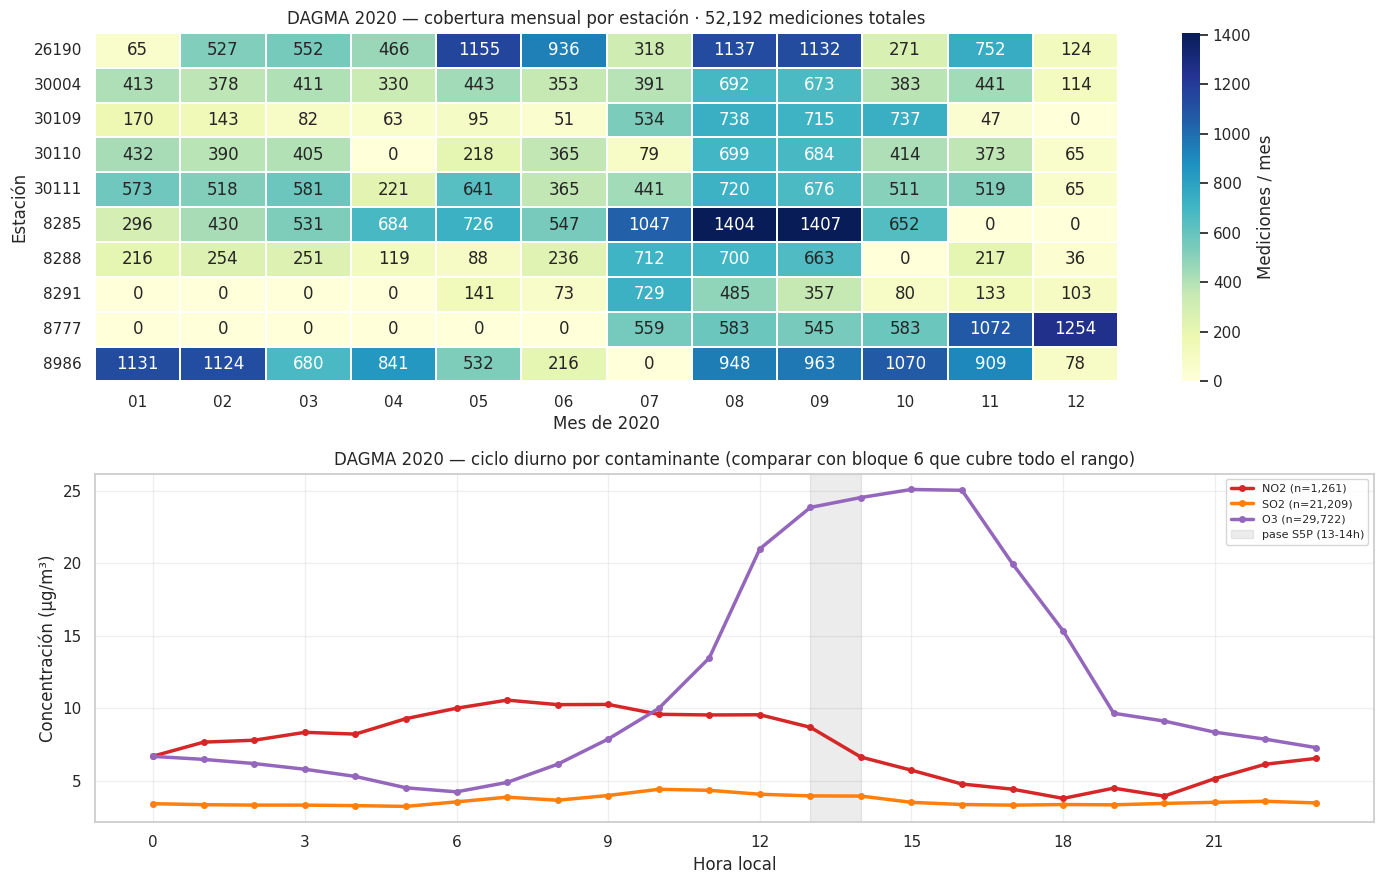


=== DAGMA 2020 — distribución de mediciones por contaminante ===
           count  median    p95
msfl_code                      
NO2         1261    6.72  17.38
O3         29722    5.03  41.34
SO2        21209    3.51  10.19

=== Comparación cobertura 2020 vs 2021-2024 (filtrada al BBox panel) ===
Mediciones por año:
  2020:  52,192 ← fuera del panel satelital (no usable Sit 3)
  2021:  11,514 ← dentro del panel
  2022:  21,569 ← dentro del panel
  2023:   9,825 ← dentro del panel
  2024:  12,191 ← dentro del panel

Conclusión: DAGMA 2020 tiene 52,192 mediciones pero el panel satelital NO existe para 2020.
  · Sit 2 (CLIP): no usable (tiles 2020 imposibles sin S2/S5P/ERA5/MODIS).
  · Sit 3 (LOO-CV): no usable (Kriging cruza panel + DAGMA, no hay panel 2020).
  · ¿Uso posible? Validación de patrones estacionales DAGMA puros (sin satelitales) como CONTEXTO.


In [48]:
dagma_2020 = dagma_horario[dagma_horario[col_time].dt.year == 2020].copy()
print(f"Mediciones DAGMA en 2020 : {len(dagma_2020):,} ({100*len(dagma_2020)/len(dagma_horario):.1f}% del total)")
print(f"Rango exacto 2020        : {dagma_2020[col_time].min()} → {dagma_2020[col_time].max()}")

cobertura_2020 = (
    dagma_2020.groupby([col_estacion, dagma_2020[col_time].dt.month])
    .size().unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)
cobertura_2020.columns = [f"{m:02d}" for m in cobertura_2020.columns]

por_estacion_2020 = dagma_2020.groupby(col_estacion).agg(
    n_mediciones=(col_valor, "count"),
    meses_activos=(col_time, lambda s: s.dt.month.nunique()),
    primera=(col_time, "min"),
    ultima=(col_time, "max"),
)
por_estacion_2020["pct_cobertura"] = 100 * por_estacion_2020["n_mediciones"] / (12 * 30 * 24)

contaminantes_2020 = dagma_2020.groupby(col_estacion)[col_cont].apply(lambda s: sorted(set(s)))
por_estacion_2020["contaminantes"] = contaminantes_2020

print("\n=== Cobertura DAGMA 2020 por estación ===")
print(por_estacion_2020.to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
sns.heatmap(cobertura_2020, cmap="YlGnBu", ax=ax,
            linewidths=0.3, linecolor="white", annot=True, fmt="d",
            cbar_kws={"label": "Mediciones / mes"})
ax.set_xlabel("Mes de 2020")
ax.set_ylabel("Estación")
ax.set_title(f"DAGMA 2020 — cobertura mensual por estación · {len(dagma_2020):,} mediciones totales")

ax = axes[1]
ciclos_2020 = {}
for cont_proj, cont_real in mapeo_contaminantes.items():
    sub = dagma_2020[dagma_2020[col_cont] == cont_real].dropna(subset=[col_valor])
    if len(sub) == 0:
        continue
    horas_sub = sub[col_time].dt.hour
    ciclo = sub.groupby(horas_sub)[col_valor].mean()
    ciclos_2020[cont_proj] = ciclo
    color = PALETA_CONTAMINANTES[cont_proj.replace("₂", "2").replace("₃", "3").upper()]
    ax.plot(ciclo.index, ciclo.values, color=color, lw=2.5, marker="o", markersize=4,
            label=f"{cont_proj} (n={len(sub):,})")

ax.axvspan(13, 14, alpha=0.15, color="gray", label="pase S5P (13-14h)")
ax.set_xlabel("Hora local")
ax.set_ylabel("Concentración (µg/m³)")
ax.set_title("DAGMA 2020 — ciclo diurno por contaminante (comparar con bloque 6 que cubre todo el rango)")
ax.set_xticks(range(0, 24, 3))
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
save_fig(fig, "dagma_2020_cobertura_y_ciclo")
plt.show()

print("\n=== DAGMA 2020 — distribución de mediciones por contaminante ===")
print(dagma_2020.groupby(col_cont)[col_valor].agg(["count", "median", lambda s: s.quantile(0.95)]).rename(columns={"<lambda_0>": "p95"}).to_string())

print(f"\n=== Comparación cobertura 2020 vs 2021-2024 (filtrada al BBox panel) ===")
total_global = dagma_horario.groupby(dagma_horario[col_time].dt.year).size()
print("Mediciones por año:")
for año, n in total_global.items():
    marca = " ← fuera del panel satelital (no usable Sit 3)" if año == 2020 else " ← dentro del panel" if 2021 <= año <= 2024 else " ← parcial"
    print(f"  {año}: {n:>7,}{marca}")

print(f"\nConclusión: DAGMA 2020 tiene {len(dagma_2020):,} mediciones pero el panel satelital NO existe para 2020.")
print(f"  · Sit 2 (CLIP): no usable (tiles 2020 imposibles sin S2/S5P/ERA5/MODIS).")
print(f"  · Sit 3 (LOO-CV): no usable (Kriging cruza panel + DAGMA, no hay panel 2020).")
print(f"  · ¿Uso posible? Validación de patrones estacionales DAGMA puros (sin satelitales) como CONTEXTO.")

In [37]:
tiles_npz_path = TILES_SIT2 / "tiles_train.npz"
tiles_meta_path = TILES_SIT2 / "tiles_meta.parquet"

with np.load(tiles_npz_path, allow_pickle=False) as npz:
    print(f"Claves del npz: {list(npz.keys())}")
    for k in npz.files:
        a = npz[k]
        print(f"  {k}: shape={a.shape} · dtype={a.dtype}")
    nombre_arr = next((k for k in npz.files if npz[k].ndim == 4), npz.files[0])
    tiles_arr = npz[nombre_arr].astype(np.float32)
    bandas_tiles = list(npz["bands"]) if "bands" in npz.files else None

print(f"\nArray principal cargado: '{nombre_arr}' · shape={tiles_arr.shape}")
if bandas_tiles is not None:
    print(f"Bandas: {[str(b) for b in bandas_tiles]}")

meta = pd.read_parquet(tiles_meta_path)
print(f"\nMeta shape: {meta.shape}")
print(f"Columnas ({len(meta.columns)}): {meta.columns.tolist()}")
print(f"\nDtypes:")
print(meta.dtypes.to_string())
print(f"\nMuestra (3 filas):")
print(meta.head(3).to_string())

col_clase = next(
    (c for c in meta.columns if any(k in c.lower() for k in ("clase", "class", "label", "categoria"))),
    None
)
col_time_tile = next(
    (c for c in meta.columns if any(k in c.lower() for k in ("time", "fecha", "date"))),
    None
)
col_lat_tile = next((c for c in meta.columns if c.lower() in ("lat", "latitud", "latitude", "y")), None)
col_lon_tile = next((c for c in meta.columns if c.lower() in ("lon", "longitud", "longitude", "x")), None)

print(f"\n=== Columnas detectadas ===")
print(f"  Clase  : {col_clase}")
print(f"  Tiempo : {col_time_tile}")
print(f"  Lat    : {col_lat_tile}")
print(f"  Lon    : {col_lon_tile}")

print(f"\n=== Balance por clase ===")
balance = meta[col_clase].value_counts()
print(balance.to_string())
print(f"\nTotal tiles: {len(meta)} · clases: {meta[col_clase].nunique()}")

Claves del npz: ['data', 'bands']
  data: shape=(5000, 13, 64, 64) · dtype=float32
  bands: shape=(13,) · dtype=<U3

Array principal cargado: 'data' · shape=(5000, 13, 64, 64)
Bandas: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL']

Meta shape: (5000, 22)
Columnas (22): ['clase', 'time_s2', 'lat', 'lon', 'ndvi', 'ndbi', 'scl_pct', 'no2', 'so2', 'o3', 'texto', 'era5_T2m', 'era5_Td2m', 'era5_u10', 'era5_v10', 'era5_BLH', 'era5_RH850', 'era5_psurf', 'era5_precip', 'modis_AOD_047', 'modis_AOD_055', 'modis_WV']

Dtypes:
clase             object
time_s2           object
lat              float64
lon              float64
ndvi             float64
ndbi             float64
scl_pct          float64
no2              float64
so2              float64
o3               float64
texto             object
era5_T2m         float64
era5_Td2m        float64
era5_u10         float64
era5_v10         float64
era5_BLH         float64
era5_RH850       float64
era5_psurf       fl

Columnas físicas detectadas: ['ndvi', 'ndbi', 'scl_pct', 'no2', 'so2', 'o3']
  [fig] /kaggle/working/figuras_eda/tiles_meta_distribuciones.png


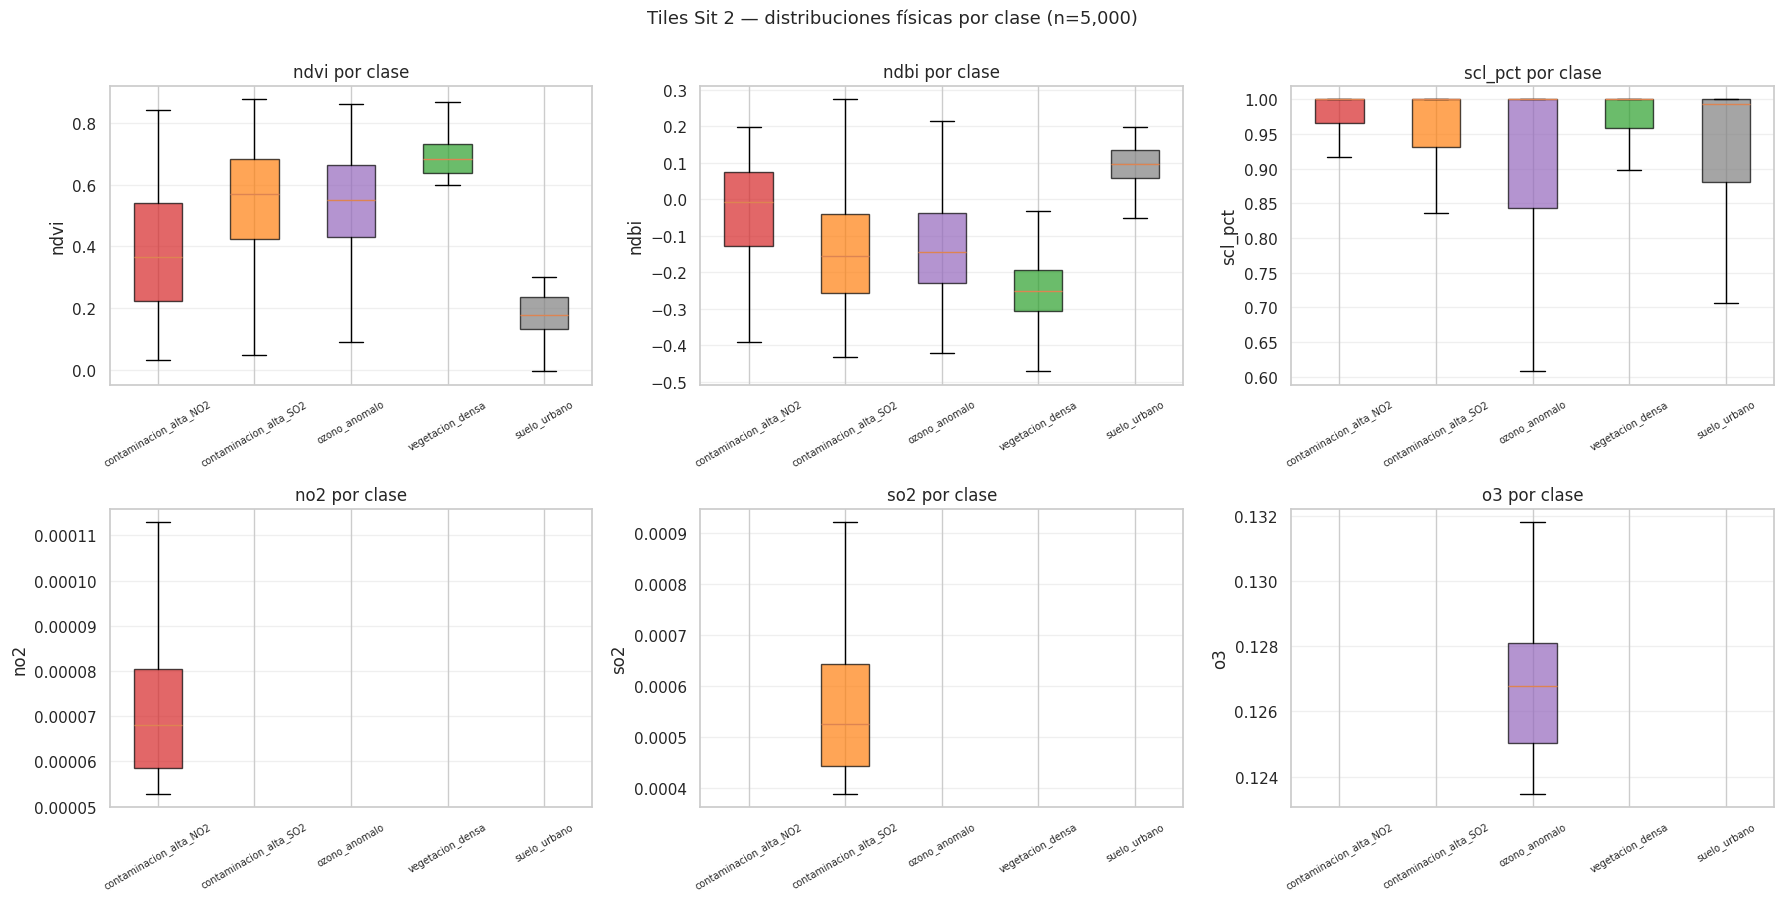


=== Mediana por clase × variable ===
                         ndvi   ndbi  scl_pct  no2    so2     o3
clase                                                           
contaminacion_alta_NO2  0.366 -0.009    1.000  0.0    NaN    NaN
contaminacion_alta_SO2  0.569 -0.157    1.000  NaN  0.001    NaN
ozono_anomalo           0.550 -0.146    1.000  NaN    NaN  0.127
suelo_urbano            0.177  0.097    0.993  NaN    NaN    NaN
vegetacion_densa        0.682 -0.253    1.000  NaN    NaN    NaN


In [38]:
COLS_FISICAS_DESEADAS = ["ndvi", "ndbi", "scl_pct", "no2", "so2", "o3"]
cols_fisicas = []
for k in COLS_FISICAS_DESEADAS:
    match = next((c for c in meta.columns if c.lower() == k or k in c.lower().split("_")), None)
    if match is not None and pd.api.types.is_numeric_dtype(meta[match]):
        cols_fisicas.append(match)

print(f"Columnas físicas detectadas: {cols_fisicas}")

n_cols = 3
n_rows = (len(cols_fisicas) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes_flat = axes.flat if n_rows > 1 else axes

clases_ordenadas = list(balance.index)
colores_clase = [PALETA_CLASES.get(c, "#999999") for c in clases_ordenadas]

for ax, col in zip(axes_flat, cols_fisicas):
    data_por_clase = [meta[meta[col_clase] == c][col].dropna().values for c in clases_ordenadas]
    bp = ax.boxplot(data_por_clase, labels=clases_ordenadas, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], colores_clase):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(col)
    ax.set_title(f"{col} por clase")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.grid(alpha=0.3, axis="y")

for j in range(len(cols_fisicas), n_rows * n_cols):
    axes_flat = list(axes_flat) if not isinstance(axes_flat, list) else axes_flat
    if j < len(axes_flat):
        axes_flat[j].axis("off")

plt.suptitle(f"Tiles Sit 2 — distribuciones físicas por clase (n={len(meta):,})", y=1.00, fontsize=13)
plt.tight_layout()
save_fig(fig, "tiles_meta_distribuciones")
plt.show()

print("\n=== Mediana por clase × variable ===")
print(meta.groupby(col_clase)[cols_fisicas].median().round(3).to_string())

  [fig] /kaggle/working/figuras_eda/tiles_ejemplos_por_clase.png


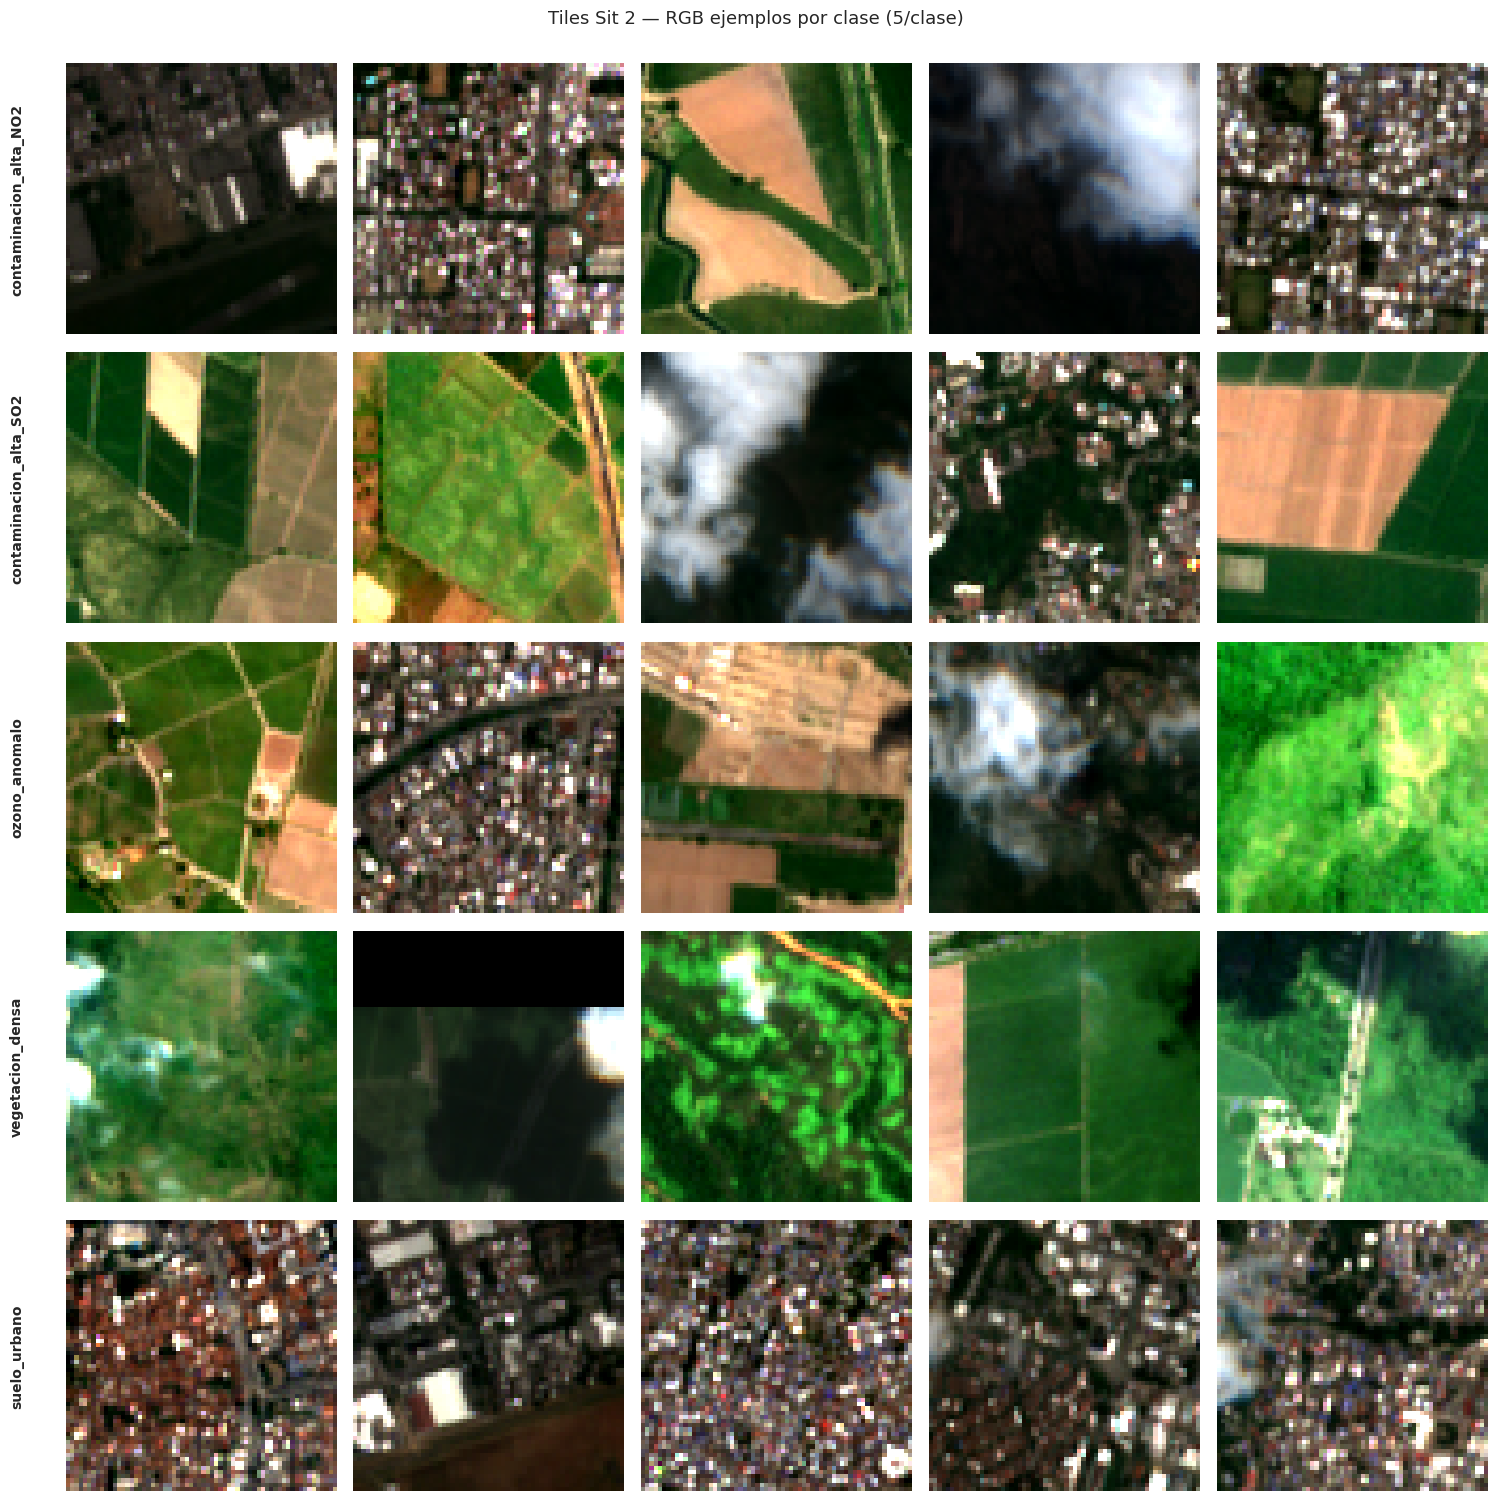

In [39]:
N_EJEMPLOS_POR_CLASE = 5

if bandas_tiles is not None:
    bandas_str = [str(b) for b in bandas_tiles]
    idx_b4 = bandas_str.index("B4") if "B4" in bandas_str else 3
    idx_b3 = bandas_str.index("B3") if "B3" in bandas_str else 2
    idx_b2 = bandas_str.index("B2") if "B2" in bandas_str else 1
else:
    idx_b4, idx_b3, idx_b2 = 3, 2, 1

rng_ejemplos = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(clases_ordenadas), N_EJEMPLOS_POR_CLASE,
                          figsize=(N_EJEMPLOS_POR_CLASE * 3, len(clases_ordenadas) * 3))

for fila, clase in enumerate(clases_ordenadas):
    indices_clase = meta.index[meta[col_clase] == clase].to_numpy()
    elegidos = rng_ejemplos.choice(indices_clase, size=min(N_EJEMPLOS_POR_CLASE, len(indices_clase)), replace=False)

    for col, idx in enumerate(elegidos):
        ax = axes[fila, col] if len(clases_ordenadas) > 1 else axes[col]
        rgb = tiles_arr[int(idx), [idx_b4, idx_b3, idx_b2], :, :].transpose(1, 2, 0)
        valid = np.isfinite(rgb)
        if valid.any():
            p2, p98 = np.percentile(rgb[valid], [2, 98])
            rgb_norm = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
        else:
            rgb_norm = np.zeros_like(rgb)
        ax.imshow(rgb_norm)
        ax.axis("off")
        if col == 0:
            ax.text(-0.18, 0.5, clase, transform=ax.transAxes, rotation=90,
                    va="center", ha="center", fontsize=10, fontweight="bold")

plt.suptitle(f"Tiles Sit 2 — RGB ejemplos por clase ({N_EJEMPLOS_POR_CLASE}/clase)", y=1.00, fontsize=13)
plt.tight_layout()
save_fig(fig, "tiles_ejemplos_por_clase")
plt.show()

  [info] 'time_s2' parseado con parsear_tiempo (S5P) → 5,000 fechas válidas de 5,000
=== Diversidad temporal por clase ===
  contaminacion_alta_NO2       · 1000 tiles ·  62 fechas únicas · máx 69 tiles/fecha · top-5 fechas = 24%
  contaminacion_alta_SO2       · 1000 tiles ·  62 fechas únicas · máx 83 tiles/fecha · top-5 fechas = 29%
  ozono_anomalo                · 1000 tiles ·  31 fechas únicas · máx 78 tiles/fecha · top-5 fechas = 35%
  vegetacion_densa             · 1000 tiles ·  66 fechas únicas · máx 40 tiles/fecha · top-5 fechas = 14%
  suelo_urbano                 · 1000 tiles ·  66 fechas únicas · máx 29 tiles/fecha · top-5 fechas = 12%
  [fig] /kaggle/working/figuras_eda/tiles_diversidad_temporal.png


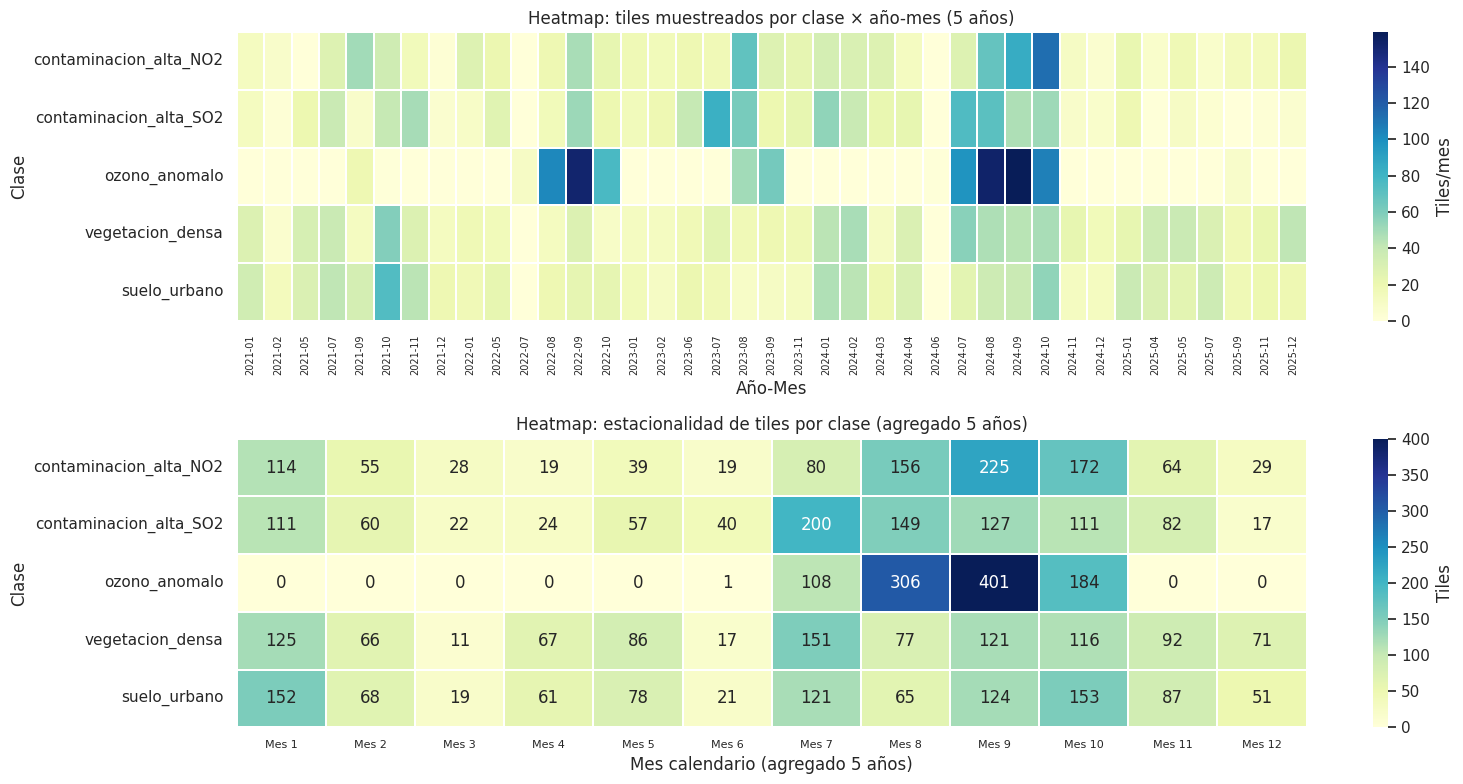

In [50]:
if col_time_tile is not None:
    if pd.api.types.is_datetime64_any_dtype(meta[col_time_tile]):
        col_fecha_tile = col_time_tile
    else:
        meta["_fecha_tile"] = parsear_tiempo(meta[col_time_tile].values)
        col_fecha_tile = "_fecha_tile"
        n_validas = meta[col_fecha_tile].notna().sum()
        print(f"  [info] '{col_time_tile}' parseado con parsear_tiempo (S5P) → {n_validas:,} fechas válidas de {len(meta):,}")

    print("=== Diversidad temporal por clase ===")
    resumen_temporal = []
    for clase in clases_ordenadas:
        sub = meta[meta[col_clase] == clase]
        fechas = sub[col_fecha_tile].dt.date.dropna()
        n_fechas = int(fechas.nunique())
        if len(fechas) > 0:
            vc = fechas.value_counts()
            max_tiles_fecha = int(vc.max())
            top5_pct = float(vc.head(5).sum() / len(sub) * 100)
        else:
            max_tiles_fecha = 0
            top5_pct = 0.0
        resumen_temporal.append({
            "clase": clase,
            "n_tiles": len(sub),
            "fechas_unicas": n_fechas,
            "max_tiles_por_fecha": max_tiles_fecha,
            "top5_fechas_pct": top5_pct,
        })
        print(f"  {clase:<28} · {len(sub):>4} tiles · {n_fechas:>3} fechas únicas · "
              f"máx {max_tiles_fecha} tiles/fecha · top-5 fechas = {top5_pct:.0f}%")

    meta["_año_mes_tile"] = meta[col_fecha_tile].dt.to_period("M").astype(str)
    pivot_tiles = (
        meta.groupby([col_clase, "_año_mes_tile"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=clases_ordenadas)
    )
    pivot_tiles = pivot_tiles.reindex(
        sorted(pivot_tiles.columns, key=lambda s: pd.Period(s, freq="M")),
        axis=1
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    ax = axes[0]
    sns.heatmap(pivot_tiles, cmap="YlGnBu", ax=ax, linewidths=0.2, linecolor="white",
                cbar_kws={"label": "Tiles/mes"}, annot=False)
    ax.set_xlabel("Año-Mes")
    ax.set_ylabel("Clase")
    ax.set_title("Heatmap: tiles muestreados por clase × año-mes (5 años)")
    ax.tick_params(axis="x", rotation=90, labelsize=7)

    ax = axes[1]
    pivot_cal = (
        meta.groupby([col_clase, meta[col_fecha_tile].dt.month])
        .size().unstack(fill_value=0).reindex(index=clases_ordenadas)
    )
    pivot_cal.columns = [f"Mes {m}" for m in pivot_cal.columns]
    sns.heatmap(pivot_cal, cmap="YlGnBu", ax=ax, annot=True, fmt="d",
                linewidths=0.3, linecolor="white", cbar_kws={"label": "Tiles"})
    ax.set_xlabel("Mes calendario (agregado 5 años)")
    ax.set_ylabel("Clase")
    ax.set_title("Heatmap: estacionalidad de tiles por clase (agregado 5 años)")
    ax.tick_params(axis="x", rotation=0, labelsize=8)

    plt.tight_layout()
    save_fig(fig, "tiles_diversidad_temporal")
    plt.show()

Fechas únicas usadas en ozono_anomalo: 31

Tiles ozono_anomalo por mes calendario:
_fecha_tile
6       1
7     108
8     306
9     401
10    184
  [fig] /kaggle/working/figuras_eda/tiles_estacionalidad_ozono.png


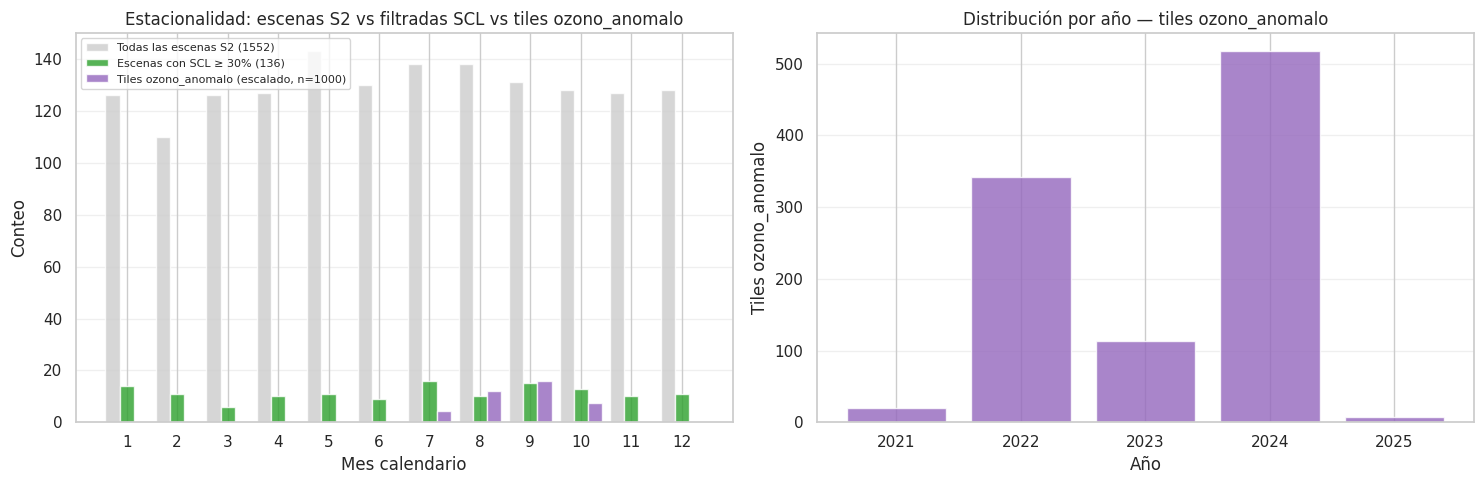


=== Verificación cruzada con MUESTREO_SIT2.md ===
Esperado en MUESTREO_SIT2 para O₃: 31 fechas únicas, top-5 = 35%
Observado en EDA              : 31 fechas únicas, top-5 = 35%


In [41]:
scl_cache = pd.read_csv(TILES_SIT2 / "scl_por_escena.csv")
scl_cache["fecha_dt"] = pd.to_datetime(
    scl_cache["time_s2"].astype(str).str.split("_").str[0],
    format="%Y%m%dT%H%M%S"
)
scl_cache["mes_cal"] = scl_cache["fecha_dt"].dt.month
scl_cache["año"] = scl_cache["fecha_dt"].dt.year

filtradas_pre = scl_cache[scl_cache["scl_pct"] >= 0.30]
ozono_meta = meta[meta[col_clase].str.contains("ozono", case=False, na=False)]

if len(ozono_meta) > 0:
    ozono_fechas = pd.to_datetime(ozono_meta["_fecha_tile"]).dt.date.unique()
    print(f"Fechas únicas usadas en ozono_anomalo: {len(ozono_fechas)}")
    ozono_meses = pd.to_datetime(ozono_meta["_fecha_tile"]).dt.month.value_counts().sort_index()
    print(f"\nTiles ozono_anomalo por mes calendario:")
    print(ozono_meses.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    todas_meses = scl_cache["mes_cal"].value_counts().sort_index()
    filtradas_meses = filtradas_pre["mes_cal"].value_counts().sort_index().reindex(range(1, 13), fill_value=0)
    ozono_meses_full = ozono_meses.reindex(range(1, 13), fill_value=0)

    width = 0.28
    x = np.arange(1, 13)
    ax.bar(x - width, todas_meses.reindex(range(1, 13), fill_value=0).values, width,
           label="Todas las escenas S2 (1552)", color="#cccccc", alpha=0.8)
    ax.bar(x, filtradas_meses.values, width,
           label="Escenas con SCL ≥ 30% (136)", color="#2ca02c", alpha=0.8)
    ax.bar(x + width, ozono_meses_full.values * (filtradas_meses.max() / max(ozono_meses_full.max(), 1)), width,
           label=f"Tiles ozono_anomalo (escalado, n={len(ozono_meta)})", color="#9467bd", alpha=0.8)
    ax.set_xlabel("Mes calendario")
    ax.set_ylabel("Conteo")
    ax.set_xticks(range(1, 13))
    ax.set_title("Estacionalidad: escenas S2 vs filtradas SCL vs tiles ozono_anomalo")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

    ax = axes[1]
    ozono_años = pd.to_datetime(ozono_meta["_fecha_tile"]).dt.year.value_counts().sort_index()
    ax.bar(ozono_años.index.astype(str), ozono_años.values, color="#9467bd", alpha=0.8, edgecolor="white")
    ax.set_xlabel("Año")
    ax.set_ylabel("Tiles ozono_anomalo")
    ax.set_title("Distribución por año — tiles ozono_anomalo")
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    save_fig(fig, "tiles_estacionalidad_ozono")
    plt.show()

print("\n=== Verificación cruzada con MUESTREO_SIT2.md ===")
print(f"Esperado en MUESTREO_SIT2 para O₃: 31 fechas únicas, top-5 = 35%")
if len(ozono_meta) > 0:
    fechas_o3 = pd.to_datetime(ozono_meta["_fecha_tile"]).dt.date
    print(f"Observado en EDA              : {fechas_o3.nunique()} fechas únicas, top-5 = {fechas_o3.value_counts().head(5).sum()/len(ozono_meta)*100:.0f}%")

Columnas numéricas para correlación cruzada (17):
  ndvi: 5,000 no-NaN
  ndbi: 5,000 no-NaN
  scl_pct: 5,000 no-NaN
  no2: 1,000 no-NaN
  so2: 1,000 no-NaN
  o3: 1,000 no-NaN
  era5_T2m: 5,000 no-NaN
  era5_Td2m: 5,000 no-NaN
  era5_u10: 5,000 no-NaN
  era5_v10: 5,000 no-NaN
  era5_BLH: 5,000 no-NaN
  era5_RH850: 5,000 no-NaN
  era5_psurf: 5,000 no-NaN
  era5_precip: 5,000 no-NaN
  modis_AOD_047: 5,000 no-NaN
  modis_AOD_055: 5,000 no-NaN
  modis_WV: 5,000 no-NaN
  [fig] /kaggle/working/figuras_eda/cruzado_correlacion_global.png


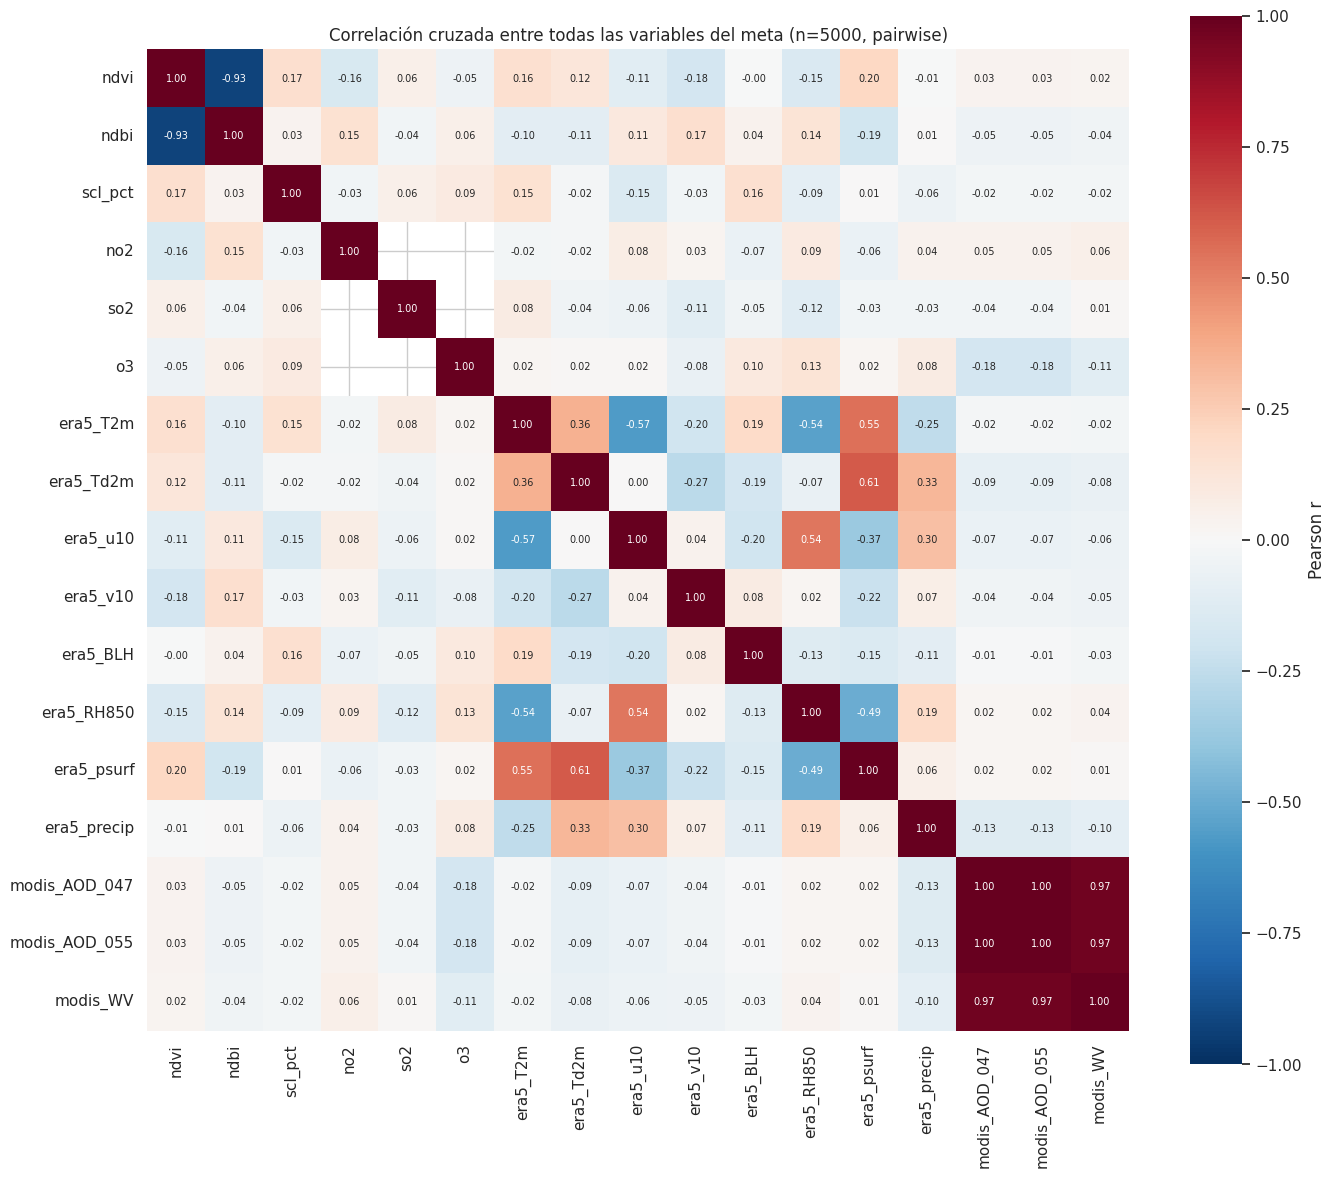


=== Pares cross-source con |r| > 0.3 (excluyendo intra-ERA5 ya vistos) ===
  ndvi               ↔ ndbi               r = -0.928


In [42]:
cols_numericas_meta = [
    c for c in meta.columns
    if pd.api.types.is_numeric_dtype(meta[c]) and c not in ("lat", "lon")
]

print(f"Columnas numéricas para correlación cruzada ({len(cols_numericas_meta)}):")
for c in cols_numericas_meta:
    n_validos = int(meta[c].notna().sum())
    print(f"  {c}: {n_validos:>5,} no-NaN")

corr_cruzada = meta[cols_numericas_meta].corr(method="pearson", min_periods=50)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_cruzada, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, ax=ax,
    annot_kws={"fontsize": 7}, cbar_kws={"label": "Pearson r"}
)
ax.set_title(f"Correlación cruzada entre todas las variables del meta (n=5000, pairwise)")
plt.tight_layout()
save_fig(fig, "cruzado_correlacion_global")
plt.show()

print("\n=== Pares cross-source con |r| > 0.3 (excluyendo intra-ERA5 ya vistos) ===")
prefijos_intra = ["era5_", "modis_"]
pares_cross = []
for i, a in enumerate(corr_cruzada.columns):
    for j in range(i + 1, len(corr_cruzada.columns)):
        b = corr_cruzada.columns[j]
        r = float(corr_cruzada.iloc[i, j])
        if pd.isna(r) or abs(r) < 0.3:
            continue
        misma_fuente = any(a.startswith(p) and b.startswith(p) for p in prefijos_intra)
        if not misma_fuente:
            pares_cross.append((a, b, r))

pares_cross.sort(key=lambda t: -abs(t[2]))
for a, b, r in pares_cross[:30]:
    print(f"  {a:<18} ↔ {b:<18} r = {r:+.3f}")

  [fig] /kaggle/working/figuras_eda/cruzado_scatter_claves.png


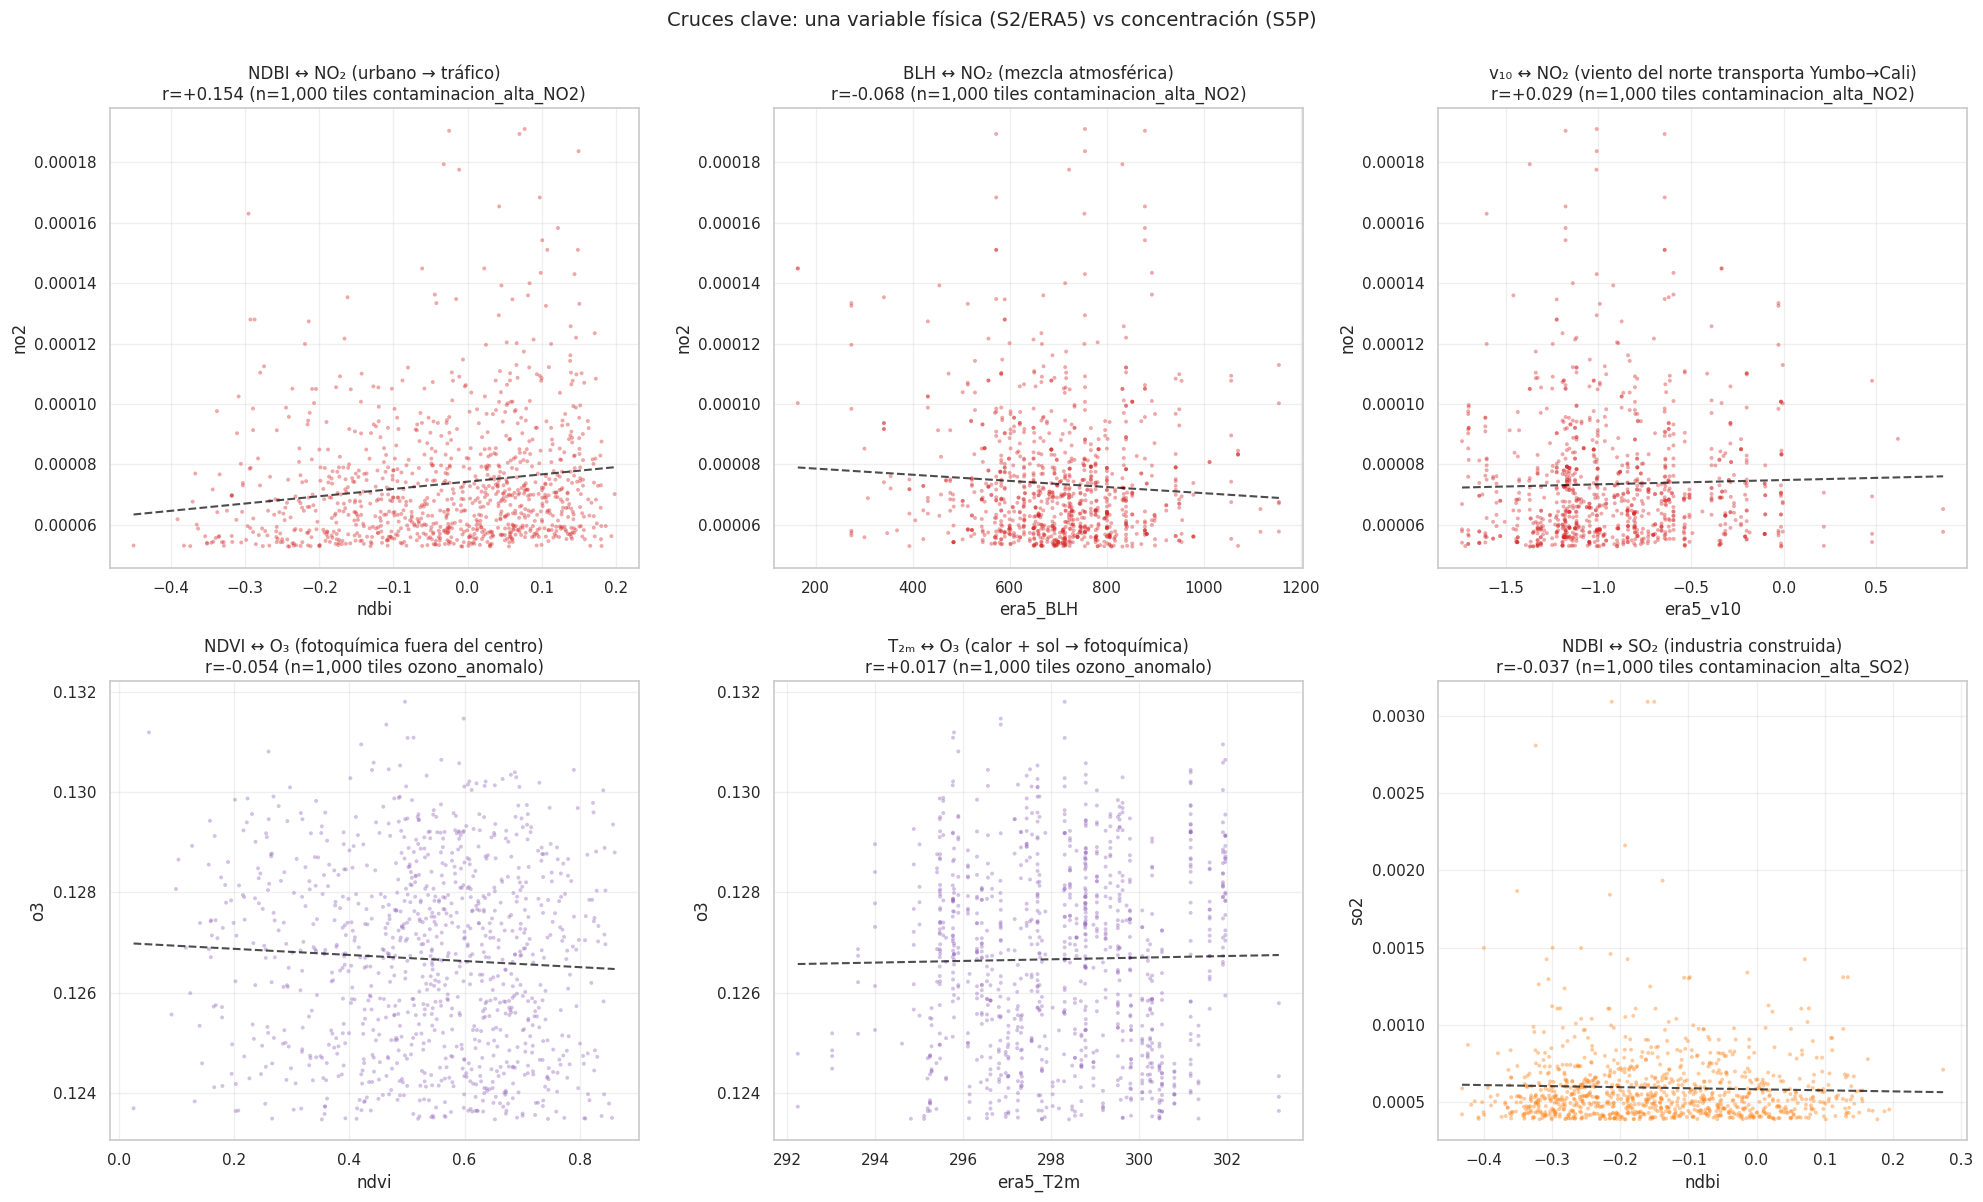

In [43]:
PARES_CRUZADOS_CLAVE = [
    ("ndbi", "no2", "NDBI ↔ NO₂ (urbano → tráfico)", "contaminacion_alta_NO2"),
    ("era5_BLH", "no2", "BLH ↔ NO₂ (mezcla atmosférica)", "contaminacion_alta_NO2"),
    ("era5_v10", "no2", "v₁₀ ↔ NO₂ (viento del norte transporta Yumbo→Cali)", "contaminacion_alta_NO2"),
    ("ndvi", "o3", "NDVI ↔ O₃ (fotoquímica fuera del centro)", "ozono_anomalo"),
    ("era5_T2m", "o3", "T₂ₘ ↔ O₃ (calor + sol → fotoquímica)", "ozono_anomalo"),
    ("ndbi", "so2", "NDBI ↔ SO₂ (industria construida)", "contaminacion_alta_SO2"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, (x_col, y_col, titulo, clase_filtro) in zip(axes.flat, PARES_CRUZADOS_CLAVE):
    sub = meta[meta[col_clase] == clase_filtro][[x_col, y_col]].dropna()
    if len(sub) < 10:
        ax.text(0.5, 0.5, f"Pocos datos: {len(sub)}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(titulo)
        continue
    color = PALETA_CLASES.get(clase_filtro, "#999999")
    ax.scatter(sub[x_col], sub[y_col], s=8, alpha=0.4, color=color, edgecolor="none")
    r = float(sub[x_col].corr(sub[y_col]))
    z = np.polyfit(sub[x_col], sub[y_col], 1)
    xx = np.linspace(sub[x_col].min(), sub[x_col].max(), 50)
    ax.plot(xx, np.poly1d(z)(xx), color="black", lw=1.5, linestyle="--", alpha=0.7)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{titulo}\nr={r:+.3f} (n={len(sub):,} tiles {clase_filtro})")
    ax.grid(alpha=0.3)

plt.suptitle("Cruces clave: una variable física (S2/ERA5) vs concentración (S5P)", y=1.00, fontsize=14)
plt.tight_layout()
save_fig(fig, "cruzado_scatter_claves")
plt.show()

Matriz para PCA: shape=(5000, 14) (sobre 14 features)
  [fig] /kaggle/working/figuras_eda/cruzado_pca_scree_cargas.png


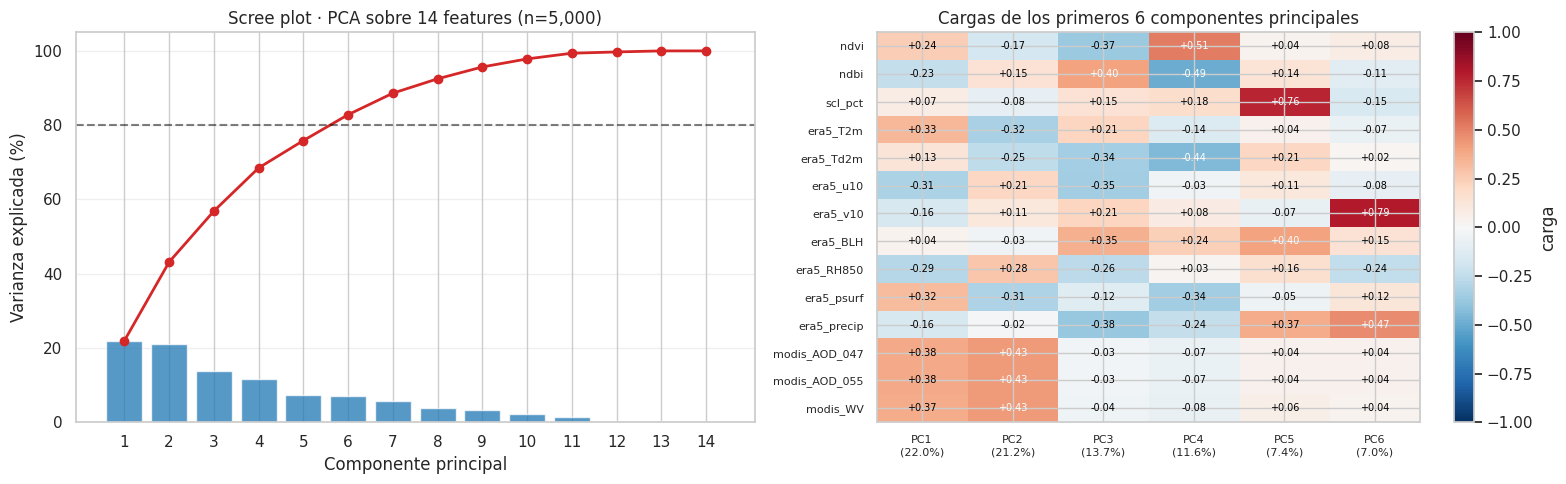


Factores para 80% varianza explicada: 6
Factores para 90% varianza explicada: 8
Criterio AFE PDF (≥80%): ✅ cumple


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_pca = [
    "ndvi", "ndbi", "scl_pct",
    "era5_T2m", "era5_Td2m", "era5_u10", "era5_v10",
    "era5_BLH", "era5_RH850", "era5_psurf", "era5_precip",
    "modis_AOD_047", "modis_AOD_055", "modis_WV",
]
features_pca = [c for c in features_pca if c in meta.columns]

X = meta[features_pca].dropna().to_numpy()
print(f"Matriz para PCA: shape={X.shape} (sobre {len(features_pca)} features)")
idx_validos = meta[features_pca].dropna().index
clases_validas = meta.loc[idx_validos, col_clase].to_numpy()

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(X_std)
varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

n_factores_80 = int(np.argmax(varianza_acum >= 0.80) + 1)
n_factores_90 = int(np.argmax(varianza_acum >= 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(range(1, len(varianza) + 1), varianza * 100, color="#1f77b4", alpha=0.75, edgecolor="white")
ax.plot(range(1, len(varianza) + 1), varianza_acum * 100, color="#d62728", marker="o", lw=2)
ax.axhline(80, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title(f"Scree plot · PCA sobre {len(features_pca)} features (n={X.shape[0]:,})")
ax.set_xticks(range(1, len(varianza) + 1))
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
n_show = min(6, len(features_pca))
cargas = pca.components_[:n_show].T
im = ax.imshow(cargas, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_yticks(range(len(features_pca)))
ax.set_yticklabels(features_pca, fontsize=8)
ax.set_xticks(range(n_show))
ax.set_xticklabels([f"PC{i+1}\n({varianza[i]*100:.1f}%)" for i in range(n_show)], fontsize=8)
ax.set_title("Cargas de los primeros 6 componentes principales")
plt.colorbar(im, ax=ax, label="carga")

for i in range(len(features_pca)):
    for j in range(n_show):
        ax.text(j, i, f"{cargas[i, j]:+.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(cargas[i, j]) > 0.4 else "black")

plt.tight_layout()
save_fig(fig, "cruzado_pca_scree_cargas")
plt.show()

print(f"\nFactores para 80% varianza explicada: {n_factores_80}")
print(f"Factores para 90% varianza explicada: {n_factores_90}")
print(f"Criterio AFE PDF (≥80%): {'✅ cumple' if n_factores_80 <= 8 else '⚠ requiere muchos factores'}")

  [fig] /kaggle/working/figuras_eda/cruzado_pca_biplot.png


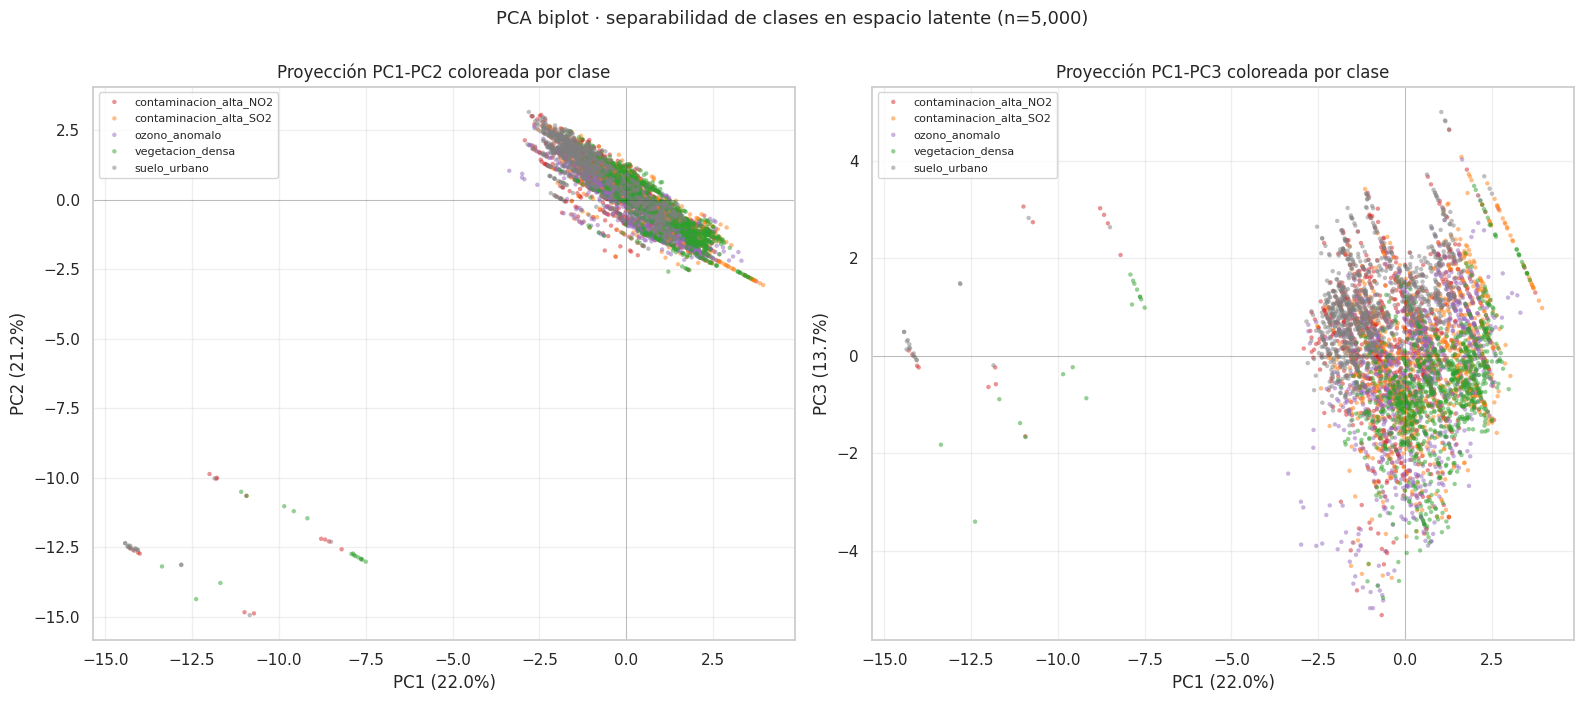


=== Centroide de cada clase en PC1-PC2-PC3 ===
  contaminacion_alta_NO2       PC1=-0.442 PC2=+0.294 PC3=+0.148
  contaminacion_alta_SO2       PC1=+0.601 PC2=-0.256 PC3=-0.082
  ozono_anomalo                PC1=+0.299 PC2=-0.313 PC3=-0.391
  vegetacion_densa             PC1=+0.626 PC2=-0.490 PC3=-0.704
  suelo_urbano                 PC1=-1.083 PC2=+0.766 PC3=+1.029


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for clase in clases_ordenadas:
    mask = clases_validas == clase
    ax.scatter(scores[mask, 0], scores[mask, 1], s=10, alpha=0.5,
               color=PALETA_CLASES.get(clase, "#999999"), label=clase, edgecolor="none")
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}%)")
ax.set_title("Proyección PC1-PC2 coloreada por clase")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)
ax.axhline(0, color="black", lw=0.5, alpha=0.3)
ax.axvline(0, color="black", lw=0.5, alpha=0.3)

ax = axes[1]
for clase in clases_ordenadas:
    mask = clases_validas == clase
    ax.scatter(scores[mask, 0], scores[mask, 2], s=10, alpha=0.5,
               color=PALETA_CLASES.get(clase, "#999999"), label=clase, edgecolor="none")
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}%)")
ax.set_ylabel(f"PC3 ({varianza[2]*100:.1f}%)")
ax.set_title("Proyección PC1-PC3 coloreada por clase")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)
ax.axhline(0, color="black", lw=0.5, alpha=0.3)
ax.axvline(0, color="black", lw=0.5, alpha=0.3)

plt.suptitle(f"PCA biplot · separabilidad de clases en espacio latente (n={X.shape[0]:,})", y=1.00, fontsize=13)
plt.tight_layout()
save_fig(fig, "cruzado_pca_biplot")
plt.show()

print(f"\n=== Centroide de cada clase en PC1-PC2-PC3 ===")
for clase in clases_ordenadas:
    mask = clases_validas == clase
    centro = scores[mask, :3].mean(axis=0)
    print(f"  {clase:<28} PC1={centro[0]:+.3f} PC2={centro[1]:+.3f} PC3={centro[2]:+.3f}")

In [46]:
print("=" * 70)
print("RESUMEN FINAL DEL EDA — GeoVision-CLIP Cali")
print("=" * 70)
print(f"\nFuentes analizadas: 6 zarrs + 1 parquet DAGMA + 1 npz tiles")
print(f"Tiles muestreados : 5,000 balanceados (1,000/clase × 5 clases)")
print(f"Período           : 2021-2025 (panel) · 2020-2024 (DAGMA)")
print(f"Overlap útil      : 4 años (2021-2024)")
print(f"\nDecisiones del proyecto confirmadas empíricamente:")
print(f"  #1  BBox ampliado a Yumbo (hot-spot NO₂/SO₂ visible en mapas S5P)")
print(f"  #4  ERA5 horario (BLH varía ×9 día/noche · S5P pierde 46-53% picos AM)")
print(f"  #6  13 bandas S2 (todas presentes)")
print(f"  #7  Overlap 4 años (manifest DAGMA confirma)")
print(f"  #8  10 estaciones (Yumbo CVC única con NO₂)")
print(f"  #9  5,000 tiles balanceados (1,000/clase exactos)")
print(f"  #10 Pre-filtrado SCL (94% píxeles inválidos sin filtro)")
print(f"  #11 p95 sobre p99 O₃ (bimodal + concentración jul-sep)")
print(f"  #13 MODIS bug (confirmado: mediana -1.237, valid_range [-0.1, 5.0])")
print(f"\nHallazgos críticos pendientes de mitigación:")
print(f"  · MODIS sin scale_factor → REPROCESAR PANEL")
print(f"  · NO₂ solo en 1 estación DAGMA → validación alternativa Sit 3")
print(f"  · Sesgo 86% O₃ en 2022+2024 → split estratificado por año")
print(f"\nDocumentos generados:")
print(f"  · docs/EDA_HALLAZGOS.md (secciones 1-6 completas)")
print(f"  · docs/VEREDICTO_DATOS.md (mitigaciones recomendadas)")

RESUMEN FINAL DEL EDA — GeoVision-CLIP Cali

Fuentes analizadas: 6 zarrs + 1 parquet DAGMA + 1 npz tiles
Tiles muestreados : 5,000 balanceados (1,000/clase × 5 clases)
Período           : 2021-2025 (panel) · 2020-2024 (DAGMA)
Overlap útil      : 4 años (2021-2024)

Decisiones del proyecto confirmadas empíricamente:
  #1  BBox ampliado a Yumbo (hot-spot NO₂/SO₂ visible en mapas S5P)
  #4  ERA5 horario (BLH varía ×9 día/noche · S5P pierde 46-53% picos AM)
  #6  13 bandas S2 (todas presentes)
  #7  Overlap 4 años (manifest DAGMA confirma)
  #8  10 estaciones (Yumbo CVC única con NO₂)
  #9  5,000 tiles balanceados (1,000/clase exactos)
  #10 Pre-filtrado SCL (94% píxeles inválidos sin filtro)
  #11 p95 sobre p99 O₃ (bimodal + concentración jul-sep)
  #13 MODIS bug (confirmado: mediana -1.237, valid_range [-0.1, 5.0])

Hallazgos críticos pendientes de mitigación:
  · MODIS sin scale_factor → REPROCESAR PANEL
  · NO₂ solo en 1 estación DAGMA → validación alternativa Sit 3
  · Sesgo 86% O₃ en